In [1]:
import math
import glob, os    #, h5py
import torch as tc
import qutip as qt
from qutip import *
from qutip_qip.operations import ry, rz, rx
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import pylab as plab
from scipy.optimize import minimize
from scipy.stats import unitary_group
from torchmin import minimize_constr
import torch
import torch.optim as optim
import sympy as sym
import itertools
%matplotlib inline

In [79]:
# --- Global settings 

# file_directory = r'/home/roytanay/Sideband'

default_dtype = torch.float64
complex_dtype = torch.complex64
numpy_tolerance = 1e-6
MIXED_PRECISION = True

# ---

torch.set_default_dtype(default_dtype)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

print('--- Notes ---')
print('You must use a CUDA-enabled GPU to run this notebook.')
print('--- Device ---')
print('Device (GPU) count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('CUDA available. Current device:', torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print('No CUDA device available; skipping device name query.')

print('Using device:', device)

print('Mixed precision via autocast available for CUDA:', torch.amp.autocast_mode.is_autocast_available('cuda'))

print('--- Datatype ---')
print(f"Default dtype: {torch.get_default_dtype()}")
print('Default complex dtype:', complex_dtype)
print('Using mixed precision (bfloat16):', MIXED_PRECISION)
print(torch.__version__)

--- Notes ---
You must use a CUDA-enabled GPU to run this notebook.
--- Device ---
Device (GPU) count: 1
CUDA available. Current device: NVIDIA A100 80GB PCIe MIG 2g.20gb
Using device: cuda:0
Mixed precision via autocast available for CUDA: True
--- Datatype ---
Default dtype: torch.float64
Default complex dtype: torch.complex64
Using mixed precision (bfloat16): True
2.10.0+cu128


In [3]:
GHz = 1
MHz = 1e-3
kHz = 1e-6
Hz = 1e-9

Nc = 1500
a = qt.tensor(qt.destroy(Nc), qt.qeye(2))
sigz = qt.tensor(qt.qeye(Nc), qt.sigmaz())
sigp = qt.tensor(qt.qeye(Nc), qt.sigmam())
sigm = qt.tensor(qt.qeye(Nc), qt.sigmap())
sigx = sigp + sigm
sigy = -1j*(sigm - sigp)

## Free Hamiltonian

$$ H = -\frac{\chi}{2}\hat{a}^\dagger \hat{a}\hat{\sigma}_z - \frac{\chi'}{2}\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}\hat{\sigma}_z - K_s\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a} $$

Note that $\hat{n}^2 = \hat{n} + \hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}$ (i.e.,   $\hat{n}^2 \equiv\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}$),  since the $\hat{n}$ term will be combined with the other Hamiltonian terms. Hence the Hamiltonian above describes 
$$ H \equiv \frac{\chi}{2}\hat{n}\hat{\sigma}_z - \frac{\chi'}{2}\hat{n}^2\hat{\sigma}_z- K_s\hat{n}^2$$ 
where $\chi$ is the first-order Dispersive shift, $\chi'$ is the second-order correction to the dispersive shift and $K_s$ is the Kerr self nonlinearity.


## Drive Hamiltonian
$$ H_d = C_I(t)[\hat{a}+ \hat{a}^\dagger] - i C_Q(t)[\hat{a}+ \hat{a}^\dagger] + q_I(t)\hat{\sigma}_x + q_Q(t)\hat{\sigma}_y$$

where $C_{I,Q}$ are the cavity drives in the $I-Q$ quadrature while $q_{I,Q}$ are the qubit drives in the $I-Q$ quadrature.

## Arbitrary unitary decomposition

Define the Echoed Conditional Displacement (ECD) gate as 

$$\text{ECD}(\beta) = D(\beta/2)|e\rangle |g\rangle + D(-\beta/2)|g\rangle |e\rangle = \sigma_xD(\beta\sigma_z/2)$$

where $\beta\in \mathbb{C}$ and $D(\alpha) = e^{\alpha \hat{a}^\dagger- \alpha^*\hat{a}}$.

Define arbitrary rotation as 
$$ 
R_\varphi(\theta) = \exp{\left[-i\frac{\theta}{2}(\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi))\right]} = \cos(\theta/2)I - i[\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi)]\sin(\theta/2).$$
 
where the right hand side is by the Euler identity since $[\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi)]^2=1$. i.e  Rotation by $\theta$ about the axis $(\cos\varphi, \sin\varphi, 0)$ in the $XY-$plane.

The ECD and Rotation gate form a universal gateset as seen in https://journals.aps.org/rmp/pdf/10.1103/RevModPhys.77.513




From above reference, the an ECD($\beta$) is decomposed into (hardware) gates (of 4 Displacements and one $\pi$ gate on the Transmon) such that 
$$\text{ECD}(\beta) \approx \text{ECD}(2i\alpha\sin(\chi T/2))$$
where $\chi$ is the dispersive coupling, $T$ is the total gate duration. Hence, the displacement in the cavity has a radius $\chi T \alpha$. Hence, from dimension analysis,  $\beta\sim \mu Hz $ since $\chi\sim KHz$, and $T \sim ns$. 

Recall that $\langle \beta |\hat{N}|\beta\rangle = \beta^2$, where $\hat{N} = \hat{a}^\dagger\hat{a}$. Hence, for the state $|\beta\rangle$ in the cavity the average number of photons is $|\beta|^2$ .i.e. If the number of photons feasible on a hardware is $\sim 30$, then the expected displacement distance is $\sim 5.477$.


The cost/fidelity function for gate ECD is defined as 

$$ \mathcal{F}= 1-\left|\frac{1}{\text{Tr}(P)}\text{Tr}(PU^\dagger_{\text{target}}U_{\text{ECD}})\right|^2$$
where $P$ is the projection unto the Hilbert space. $U_{ECD}$ is defined as follows

$$ U_{\text{ECD}} = D(\beta_{L+1})R_{\varphi_{L+1}}(\theta_{L+1})\cdot\text{ECD}(\beta_L)R_{\varphi_L}(\theta_L)\cdots \text{ECD}(\beta_1)R_{\varphi_1}(\theta_1).$$


Note the $P$ is the identity operator in this case since we want to consider the space of dimension $N_{\text{trunc}}$. 

To define the gradient for the cost function $\mathcal{F}$, apply the Parameter-shift Rule (as in https://pennylane.ai/qml/glossary/parameter_shift):
$$ \nabla_{\gamma_i} \mathcal{F}(\vec{\gamma}) = \frac{\mathcal{F}(\gamma_i + \varepsilon) - \mathcal{F}(\gamma_i - \varepsilon)}{2\sinh(\varepsilon)}$$

where $\vec{\gamma} = (\vec{\beta}, \vec{\varphi}, \vec{\theta})$ for arbitrary  $\gamma_i$ and any $\varepsilon>0$.

Theoretically, the expected number of blocks to reach 'good' fidelity = $((2N_{trunc})^2-1)/4 = N_{trunc}^2- 1/4 \sim \mathcal{O}(N_{trunc}^2)$.

In [4]:
def ECD_Compile(N_blocks, Unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp = False):
    
    def tc_fock(N_trunc, n):
        return tc.kron(tc.tensor(qutip.fock(2,0).full(), dtype= complex_dtype),tc.tensor(qutip.fock(N_trunc,n).full(),dtype= complex_dtype))
    
    def tc_sigmax():
        return tc.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=complex_dtype)

    def tc_sigmay():
        return tc.tensor([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex_dtype)
        
    
    def tc_sigmap():
        ''' torch sigmap'''
        X = tc.tensor([[0,1], [0,0]], dtype=complex_dtype)
        return X
        
    def tc_sigmam():
        ''' torch sigmam'''
        X = tc.tensor([[0,0], [1,0]], dtype=complex_dtype)
        return X
    
    def tc_displace(N, alpha):
        """
        Defines the displacement operator D(alpha) using only numpy and scipy.
        N: Hilbert space dimension
        alpha: Complex displacement amplitude
        """
        # 1. Create annihilation operator (a)
        # Lowering operator has sqrt(n) on the first upper diagonal
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(1, N):
            a[n-1, n] = tc.sqrt(tc.tensor(n))
            
        # 2. Create creation operator (a^\dagger)
        adag = a.H                # This performs conjugate Transpose operation
        
        # 3. Form the operator: alpha*a^\dagger - alpha*conj(a)
        operator_exponent = alpha * adag - tc.conj(alpha) * a
        
        # 4. Compute matrix exponential
        displacement_operator = tc.linalg.matrix_exp(operator_exponent)
        
        return displacement_operator

    
    def tc_idty(N):
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(N):
            a[n, n] = 1
        return a
        
    def ECD(beta_real, beta_imag, T_dim):    
        return tc.kron(tc_sigmap(), tc_displace(T_dim, (beta_real+ 1j*beta_imag)/2)) + tc.kron(tc_sigmam(), tc_displace(T_dim, -(beta_real+ 1j*beta_imag)/2))
    
    # def Rot(phi, theta, N_trunc):
    #     return tensor(rz(phi) * rx(theta) * rz(-phi), qeye(N_trunc))
    
    def Rot(phi, theta, T_dim):
        sx = tc.kron(tc_sigmax(), tc_idty(T_dim))
        sy = tc.kron(tc_sigmay(), tc_idty(T_dim))
        idty = tc.kron(tc_idty(2), tc_idty(T_dim))
        if theta == 0:
            return idty
        else:          
            return ((torch.cos(theta/2.0))*idty - 1j * ((torch.cos(phi) * sx) + (torch.sin(phi) * sy)) * torch.sin(theta/2.0))

    def P_Ntrunc(N_trunc, bumper):
        ''' Projection unto computational space '''
        T_dim = N_trunc + bumper
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for i in range(N_trunc):
            mat[i,i]=1 
        return mat
        
    def Q_Ntrunc(N_trunc, bumper):
        ''' Projection unto bumper space '''
        T_dim = N_trunc + bumper
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for j in range(0,N_trunc):
            for i in range(N_trunc, T_dim):
                mat[j,i] = 1 
        return mat

    def Full_Unitary(Unitary, bumper, N_trunc):
        T_dim = bumper +N_trunc
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for i in range(N_trunc):
            for j in range(N_trunc):
                mat[i,j] = Unitary[i,j]
        for k in range(N_trunc, T_dim):
            mat[k,k] = 1                
        return mat
            

    
    # One ECD Block
    def U_block_ECD(beta_real, beta_imag, phi, theta, T_dim):
        return ECD(beta_real, beta_imag,  T_dim) @ Rot(phi, theta, T_dim) 

    # def U_block_ECD2(beta_real, beta_imag, phi, theta, N_trunc):
    #     return ECD(beta_real, beta_imag,  N_trunc) * Rot(phi, theta, N_trunc)* ECD(beta_real, beta_imag,  N_trunc).dag()
    
    # Sequence of ECD blocks
    def U_circuit_ECD(betas_real, betas_imag, phis, thetas, bumper, N_trunc):

        T_dim = bumper + N_trunc
        b_state_pop ={}                                            # bumper state population
        for index in range(N_trunc, T_dim):
            b_state_pop[f'{index}'] = [] 

        
        U = tc.kron(tc_idty(2), tc_idty(T_dim))
        block_list = []
        for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): 
            block_list.append(U_block_ECD(beta_real, beta_imag, phi, theta, T_dim))


        state = tc_fock(T_dim,0)
        for num in range(len(block_list)):
            U = block_list[num]@ U
            
            state = block_list[num]@state        # final cavity state (starting with cavity = |0>, Transmon = |g>) after each ECD+Rot block 
            for k in range(T_dim-pen, T_dim):
                # prob = tc.tensor(math.exp(k+1)/math.exp(T_dim)) *(tc.abs(tc_fock(T_dim,k).H @state))**2
                # prob = tc.tensor(((k+1)*(num+1))/(len(block_list)*T_dim)) *(tc.abs(tc_fock(T_dim,k).H @state))**2
                prob = tc.tensor((np.exp(k+1))/np.exp(T_dim))*(tc.abs(tc_fock(T_dim,k).H @state))**2
                b_state_pop[f'{k}'].append(prob)        #.detach().numpy()[0][0])
        
        if Add_block == False:
            return U,  b_state_pop  
            
        else:
            U = tc.kron(tc_idty(2), tc_displace(T_dim, (betas_real[-1]+ 1j*betas_imag[-1])/2)) @ Rot(phis[-1], thetas[-1], T_dim) @ U
            block_list.append(U)            
            state = U@state 
            
            for k in range(N_trunc, T_dim):
                prob = tc.tensor(k/T_dim) *(tc.abs(tc_fock(T_dim,k).H @state))**2
                b_state_pop[f'{k}'].append(prob)        #.detach().numpy()[0][0])
        
            return U,  b_state_pop 


    def state_cost(state_dict,N_trunc, bumper):   
        T_dim = N_trunc+bumper
        sums = 0
        for index in range(N_trunc, T_dim):
            l = len(state_dict[f'{index}'])
            sums += sum(state_dict[f'{index}'])
        return sums
   
    def Unitary_cost(Oper1, Oper2, N_trunc):
        ''' oper1 should always be the target unitary'''

        upper = Oper1[0:N_trunc, 0:N_trunc] - Oper2[0:N_trunc, 0:N_trunc]
        d = tc.tensor(upper.shape[0])
        Uval = tc.sqrt(tc.abs(tc.trace(upper.H @ upper)))/d
        return Uval

    def Unitary_cost2(Oper1, Oper2, N_trunc):
        T_dim = N_trunc
        mat = Oper1[0:T_dim, 0:T_dim] - Oper2[0:T_dim, 0:T_dim]
        # mat1  = tc.kron(tc_idty(2), P_Ntrunc(N_trunc, bumper))@ mat @ tc.kron(tc_idty(2), P_Ntrunc(N_trunc, bumper))
        # mat2 =  tc.kron(tc_idty(2), Q_Ntrunc(N_trunc, bumper))@ mat @ tc.kron(tc_idty(2), P_Ntrunc(N_trunc, bumper))

        val1  = tc.sqrt(tc.abs(tc.trace(mat.H @ mat)))/tc.tensor(mat.shape[0])
        # val2 = tc.sqrt(tc.abs(tc.trace(mat2)))/tc.tensor(mat1.shape[0])
        # val = 1-tc.sqrt(tc.abs(tc.trace(Oper1.H @ Oper2)))/tc.tensor(Oper2.shape[0])
        # print(val1)
        return val1
        

    
    opt_process = {}  
    def my_callback(result):
        """
        A callback function to monitor optimization progress.
        """
        val = Error_func(result, Unitary, N_trunc)
        opt_process[val]= result
    
    
    b_state_pop ={}      # bumper state population
    for index in range(N_trunc, bumper+N_trunc):
        b_state_pop[f'{index}'] = [] 
        
    def Error_func(params, Unitary, bumper, N_trunc):
        '''params=[betas, varphis, thetas] - hence 4l sized list '''
        ''''  args = (Unitary)'''   
        r = int(len(params)/4)
        U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], bumper, N_trunc)
        U_0 = U[0]       # Final matrix after ECD+ Rot blocks
        U_1 = U[1]       # dictionary of states  after each block of  ECD+Rot block 
        
        Target_Uni = Full_Unitary(Unitary, bumper, N_trunc)
        cost_1 = Unitary_cost(Unitary, U_0, N_trunc)
        cost_2 = state_cost(U_1, N_trunc, bumper)

        cost_3 = Unitary_cost2(tc.kron(tc_idty(2), Full_Unitary(Unitary, bumper, N_trunc)), U_0, N_trunc)
          
        return  tc.tensor(0.5)*cost_3 + tc.tensor(0.5)*cost_2

    def grad(ini_params, Unitary, N_trunc):
        deriv = []  
        epsilon = tc.tensor(5e-4, dtype= default_dtype)
        for i in range(len(ini_params)):
            new_params_plus = tc.tensor([ele for ele in ini_params])
            new_params_minus = tc.tensor([ele for ele in ini_params]) 
            new_params_plus[i] = ini_params[i] + epsilon
            new_params_minus[i] = ini_params[i] - epsilon
            partial_deriv_i = (Error_func(new_params_plus, Unitary, N_trunc) 
                               - Error_func(new_params_minus, Unitary, N_trunc))/(2*tc.sinh(epsilon))
            deriv.append(partial_deriv_i) 
        grad = tc.tensor(deriv, dtype = default_dtype) 
        return grad

    def grad2(ini_params, Unitary, N_trunc):

        deriv = []
        h = tc.tensor(5e-4, dtype=default_dtype)
        for i in range(len(ini_params)):            
            params_plus = tc.tensor([ele for ele in ini_params])
            params_plus[i] = params_plus[i] + h
            partial_deriv_i = (Error_func(params_plus, Unitary, N_trunc) 
                               - Error_func(ini_params, Unitary, N_trunc))/h
            deriv.append(partial_deriv_i)  
        return tc.tensor(deriv, dtype = default_dtype)

    if Unitary.isunitary == False:
        raise ValueError("Provided operator is non-unitary.")

    
    if Add_block == True:
        Extra_block = 1
    else:
        Extra_block = 0
            
        
    print('\n' + '*' * 10 + f' Optimizing Parameters for {N_blocks} blocks and {bumper} bumper state(s) ' + '*'* 10)
    
   
#  Pytorch LBGFS Approach
    # It must be a PyTorch tensor and require gradients
        
    
    
   
    # np.random.seed(1)
    # short_params = np.random.randn(N_blocks*4)
    # params = np.zeros(4*N_blocks)

   
    # for k in range(N_blocks):
    #     m = k*N_blocks
    #     params[m:m+N_trunc**2] = short_params[m:m+N_trunc**2]
        
    # params_tc = tc.tensor(params, dtype=default_dtype, requires_grad= True)
    
    tc.manual_seed(1000) 
    Unitary = tc.tensor(Unitary.full(), dtype = complex_dtype)
    N_params = tc.tensor(N_blocks*4)
    params_tc = tc.randn(N_params, dtype=default_dtype, requires_grad= True)
    optimizer = torch.optim.LBFGS([params_tc], max_iter =3000, line_search_fn = 'strong_wolfe', lr=0.95, tolerance_change=tol)

    loss_history = []
    def closure():
        optimizer.zero_grad()                                            # Clear gradient
        loss = Error_func(params_tc, Unitary, bumper, N_trunc)                   # Compute loss 
        loss.backward() 
        # params_tc.grad = grad(params_tc, Unitary, N_trunc)              # Assign the calculated gradient    
        loss_history.append(loss.item())
        return loss

    optimizer.step(closure)

    opt_arg = params_tc.detach()
    opt_val = loss_history[-1]

    # Unitary = tc.tensor(Unitary.full(), dtype = complex_dtype)
    # N_params = tc.tensor(N_blocks*4)
    # epoch_dict = {}
    # n=0
    # opt_val = 1
    # N_max = 30
    # # tc.manual_seed(1000) 
    # while (opt_val > thres):# and (n < N_max): 
    #     # define optimizer
    #     n=n+1
    #     params_tc = tc.randn(N_params, dtype=default_dtype, requires_grad= True)
    #     optimizer = torch.optim.LBFGS([params_tc], max_iter =3000, line_search_fn = 'strong_wolfe', lr=0.65, tolerance_change=tol)
    
    #     loss_history = []
    #     def closure():
    #         optimizer.zero_grad()                                            # Clear gradient
    #         loss = Error_func(params_tc, Unitary, bumper, N_trunc)                   # Compute loss 
    #         loss.backward() 
    #         # params_tc.grad = grad(params_tc, Unitary, N_trunc)              # Assign the calculated gradient    
    #         loss_history.append(loss.item())
    #         return loss
    
    #     optimizer.step(closure)
    
    #     opt_arg = params_tc.detach()
    #     opt_val = loss_history[-1]
    #     epoch_dict[opt_val]= opt_arg
    #     # print('count: ', n, '   ', 'opt_val: ', opt_val)
        
        

    # opt_val = min(list(epoch_dict.keys()))
    # opt_arg = epoch_dict[opt_val]
 
    k = int(len(params_tc.detach())/4)
    out_dict = {'Infidelity': opt_val , 'Betas_real': opt_arg[0:k], 'Betas_imag':opt_arg[k:2*k], 
            'Phis': opt_arg[2*k:3*k], 'Thetas': opt_arg[3*k:4*k]}

    
    # Plot Infidelity 
    if Disp == True:
        fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15,6))
        # plt.subplots_adjust(wspace= 1)
        ax[0].plot(loss_history, color='blue', marker='o', markersize= 4)
        ax[0].axhline(y = opt_val, color = 'r', linestyle='--', label= f'y = {opt_val:.3g}')
        ax[0].set_yscale('log')
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("Loss")
        ax[0].set_title(f'Optimization History for {N_blocks} blocks with {bumper} bumper state(s).')
        ax[0].grid(True, which="both", ls="-", alpha=0.5)
        ax[0].legend()
        # plt.show()


        betas_real = out_dict['Betas_real']
        betas_imag = out_dict['Betas_imag']
        phis = out_dict['Phis']
        thetas = out_dict['Thetas']
        # print(betas_real, betas_imag)
        
        def check(betas_real, betas_imag, phis, thetas, bumper, N_trunc):
            full_dim = bumper+ N_trunc
            b_state_pop ={}                                            # bumper state population
            for index in range(N_trunc, bumper+N_trunc):
                b_state_pop[f'{index}'] = [] 
        
            U = tc.kron(tc_idty(2), tc_idty(full_dim))
            for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): # [:-1] removes the last element in the list since they are  Disp. and rotation parameter
                U = U_block_ECD(beta_real, beta_imag, phi, theta, full_dim) @ U
        
                for k in range(N_trunc, full_dim):
                    fin_state = U@tc_fock(full_dim,0)
                    prob = (tc.abs(tc_fock(full_dim,k).H @fin_state))**2
                    b_state_pop[f'{k}'].append(prob.detach().numpy()[0][0])
        
            
        
            for i in range(bumper):
                s = i+N_trunc
                ax[1].plot(range(1, len(betas_real)+1, 1), list(b_state_pop.values())[i], 'o:',label=f'state |{s}>')
            ax[1].set_title('Optimization higher state history')
            ax[1].set_ylabel('Probability')
            ax[1].set_yscale('log')
            ax[1].set_xlabel('Block')
            ax[1].set_xticks(range(1, len(betas_real)+1, 1))
            ax[1].grid(True, which="both", axis = 'both', ls="-",)
            ax[1].legend()
            plt.show()
           

        check(betas_real, betas_imag, phis, thetas, bumper, N_trunc)


        Mat = U_circuit_ECD(opt_arg[0:k],opt_arg[k:2*k], opt_arg[2*k:3*k], opt_arg[3*k:4*k], bumper, N_trunc)[0]
        Mat2 = Qobj(Mat, dims = [Mat.shape[0], Mat.shape[1]])
        # Mat.dtype
        
        
        # plt.imshow(Mat, cmap='viridis', interpolation='nearest')
        # plt.colorbar()
        # ax[2].set_title('Approximate Unitary')
        # ax[2].set_ylabel('Fock levels')
        # ax[2].set_xlabel('Fock levels')
        # plt.xticks(range(Mat.shape[0]))
        # plt.yticks(range(Mat.shape[0]))
        # plt.show()

        return out_dict, Mat2

    else:
        return out_dict 

    # optimizer = torch.optim.Adam([params_tc], lr=0.5)


    # # print("Initial value of x:", params_tc.item())
    
    # # Optimization loop
    # for i in range(3000):
    #     # Calculate the loss: our function to minimize
    #     loss = Error_func(params_tc, Unitary, bumper, N_trunc)

    #     # Zero the gradients before running the backward pass
    #     optimizer.zero_grad()

    #     # Perform the backward pass to compute gradients
    #     loss.backward()

    #     # Adjust the parameters based on the gradients
    #     optimizer.step()
        
    #     if i % 100 == 0:
    #         print(f"Minimized value at {i}:", loss.item())




        


In [5]:
# Define cavity unitary
N_trunc =3
# mat = np.zeros((N_trunc, N_trunc), dtype = np.complex64)
# mat[0,1] = 1
# mat[1,0] = 1
# mat[0,2]= 1
# mat[1,0] = 1
# mat[2,1] = 1
# # for k in range(N_trunc):
# #     mat[k,k] = np.exp(1j*np.pi*(k+1)/2)
# cav_unitary = Qobj(mat, dims = [N_trunc, N_trunc])

# generate random cavity unitary
# cav_unitary = Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc]) 

mat= np.([[-0.65181065+0.06629414j,  0.17621422+0.23678904j,
         0.07617626+0.69124861j],
       [-0.47581239+0.06952501j, -0.19467545+0.57768605j,
         0.12597901-0.61747747j],
       [-0.38818691+0.43454312j, -0.50851792-0.53166655j,
        -0.34030313-0.05845669j]])



def closest_unitary(A):
    # Compute the SVD: A = U * S * Vh
    U, S, Vh = np.linalg.svd(A)
    # Reconstruct with singular values set to 1
    return U @ Vh

mat = closest_unitary(mat)
cav_unitary = Qobj(mat, dims = [N_trunc, N_trunc]) 

In [6]:
# Parameters
N_blocks = 9
tol = 1e-12
bumper =0   # dimensions including Bumper states-9
pen =0 # penalizes no bumper state
thres = 1e-5


********** Optimizing Parameters for 9 blocks and 0 bumper state(s) **********


/tmp/ipykernel_63114/2415360658.py:366: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


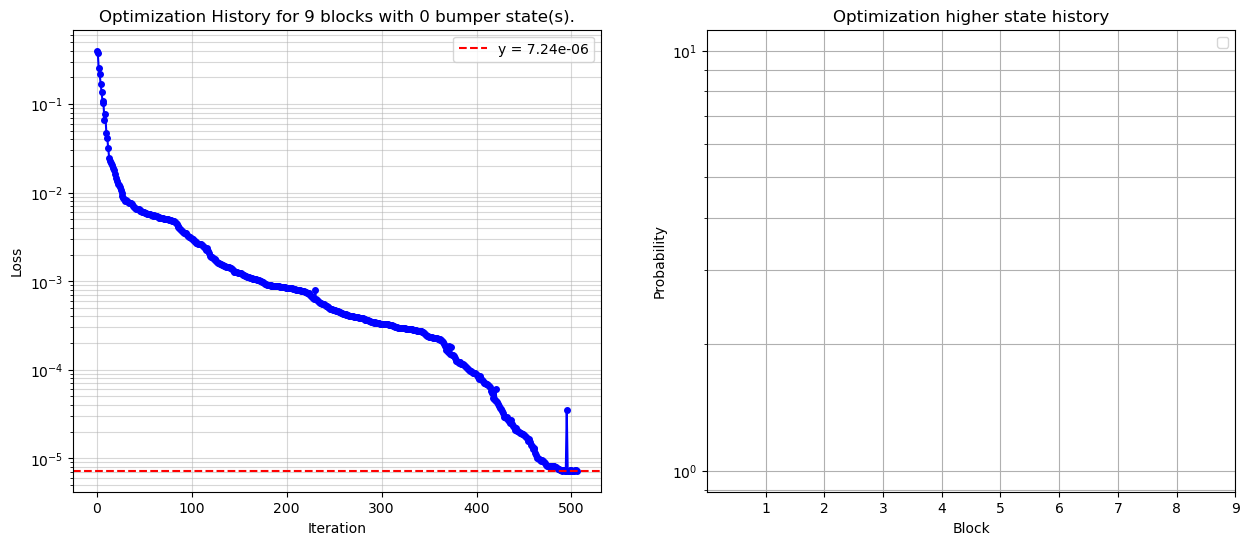

CPU times: user 3min 23s, sys: 669 ms, total: 3min 24s
Wall time: 3min 24s


Quantum object: dims=[[6], [6]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-6.51802361e-01+6.62873834e-02j  1.76216394e-01+2.36781612e-01j
   7.61783868e-02+6.91234350e-01j -2.42844969e-03+1.65756047e-03j
   3.41687351e-03+3.85700911e-03j -6.06687739e-04-1.01368874e-04j]
 [-4.75796163e-01+6.95207715e-02j -1.94663808e-01+5.77667832e-01j
   1.25980884e-01-6.17462575e-01j  2.42091902e-03-5.93024120e-03j
   2.40553543e-03+2.12047435e-03j -3.02216318e-03+1.22085214e-03j]
 [-3.88171643e-01+4.34543639e-01j -5.08503616e-01-5.31660914e-01j
  -3.40295315e-01-5.84556572e-02j -7.16932118e-04-2.54431367e-03j
   1.52796507e-04+2.39346595e-03j -7.88345933e-05-5.15414029e-03j]
 [-2.74942070e-03-1.91224366e-03j -6.74203038e-03+3.40208411e-04j
   1.79084390e-03-2.11438164e-04j -4.23839033e-01+5.28404117e-03j
   1.91763595e-01-4.70375180e-01j  6.37960076e-01+3.94023210e-01j]
 [ 4.84979898e-03+1.04126334e-03j  5.50867990e-04+1.50480121e-03j
   5.50150871e-05-2.82224268e-04j  1.883

In [7]:
# Run optimization
%time dictn = ECD_Compile(N_blocks, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=True)
dictn[1]

In [25]:
cav_unitary


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.65181065+0.06629414j  0.17621422+0.23678904j  0.07617626+0.69124861j]
 [-0.47581239+0.06952501j -0.19467545+0.57768605j  0.12597901-0.61747747j]
 [-0.38818691+0.43454312j -0.50851792-0.53166655j -0.34030313-0.05845669j]]

## Qutrit Loss plots

In [10]:
bumper = 0
N_trunc = 3
pen = 0
thres = 1e-5
Qutrit_seq_loss = []
for seq_len in range(9,25):
    Qutrit_seq_loss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


********** Optimizing Parameters for 9 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 10 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 11 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 12 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 13 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 14 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 15 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 16 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 17 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 18 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 19 blocks and 0 bumper state(s) **********

********** Optimizing Parameters for 20 blocks and 0 bumper state(s) **********

********** Optimizing Parame

In [13]:
bumper = 3
N_trunc = 3
pen = 0
thres = 1e-5
Qutrit_seq_bloss = []
for seq_len in range(9,25):
    Qutrit_seq_bloss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


********** Optimizing Parameters for 9 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 10 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 11 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 12 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 13 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 14 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 15 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 16 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 17 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 18 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 19 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 20 blocks and 3 bumper state(s) **********

********** Optimizing Parame

In [14]:
bumper = 3
N_trunc = 3
pen = 1  # penalizes highest fock level
thres = 1e-5
Qutrit_seq_p1bloss = []
for seq_len in range(9,25):
    Qutrit_seq_p1bloss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


********** Optimizing Parameters for 9 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 10 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 11 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 12 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 13 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 14 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 15 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 16 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 17 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 18 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 19 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 20 blocks and 3 bumper state(s) **********

********** Optimizing Parame

In [15]:
bumper = 3
N_trunc = 3
pen = 2  # penalizes 2 highest fock level
thres = 1e-5
Qutrit_seq_p2bloss = []
for seq_len in range(9,25):
    Qutrit_seq_p2bloss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


********** Optimizing Parameters for 9 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 10 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 11 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 12 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 13 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 14 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 15 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 16 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 17 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 18 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 19 blocks and 3 bumper state(s) **********

********** Optimizing Parameters for 20 blocks and 3 bumper state(s) **********

********** Optimizing Parame

In [39]:
Qutrit_seq_loss= [7.399383775918977e-06, 1.7354855117446277e-06, 6.628170012845658e-06, 9.226213478541467e-06, 9.570219845045358e-06,
                6.20445689492044e-06, 9.127673365583178e-06, 9.054730071511585e-06, 8.549003723601345e-06, 9.709468940855004e-06,
                6.325791673589265e-06, 8.486239494231995e-06, 3.0965184123488143e-06, 9.729957128001843e-06, 6.89973285261658e-06, 7.319340056710644e-06]
Qutrit_seq_bloss= [0.014925281517207623, 0.00788617879152298, 0.004764329642057419, 0.0037556395400315523, 0.0013558893697336316, 0.0017220373265445232,
                 0.0008389040012843907, 0.00019679068645928055, 0.0005191335221752524, 0.00017945939907804132, 0.00019819510634988546,
                 0.0001883382210507989, 0.0001419886975781992, 0.0001257496332982555, 0.00015925306070130318, 0.0002280382759636268]
Qutrit_seq_p1bloss = [0.06670095771551132, 0.042723625898361206, 0.01631723903119564, 0.028418738394975662, 0.010748052969574928, 0.013480368070304394,
                     0.004488032776862383, 0.0060235727578401566, 0.007485975045710802, 0.005727538838982582, 0.0034526651725172997, 0.0015995251014828682,
                     0.0021064551547169685, 0.0014198229182511568, 0.0019150248263031244, 0.0012503053294494748]
Qutrit_seq_p2bloss = [0.048685334622859955, 0.04841761663556099, 0.019301705062389374, 0.021892916411161423, 0.030351199209690094, 0.02691704034805298,
                     0.028839724138379097, 0.017552420496940613, 0.01016155444085598, 0.012387200258672237, 0.007475798483937979,  0.0046650986187160015,
                     0.005954943597316742, 0.004351732321083546, 0.0030346051789820194, 0.004009997006505728]

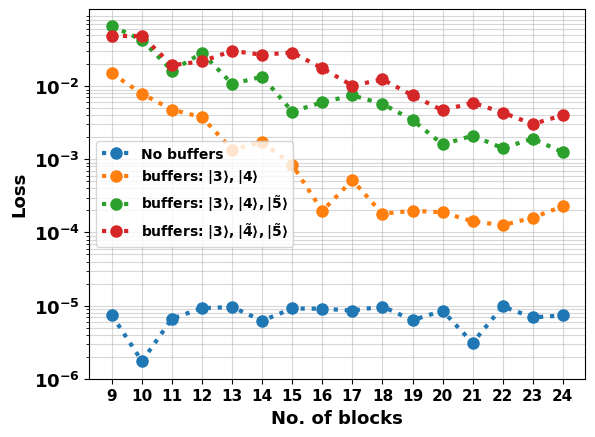

In [40]:
plt.rcParams['font.weight'] = 'bold'
plt.plot(range(9,25), Qutrit_seq_loss, 'o:',label='No buffers', lw=3, markersize= 8)
plt.plot(range(9,25), Qutrit_seq_bloss,'o:',label=r'buffers: $|3\rangle,|4\rangle$', lw=3, markersize= 8)
plt.plot(range(9,25), Qutrit_seq_p1bloss, 'o:',label=r'buffers: $|3\rangle,|4\rangle, |\tilde{5}\rangle$', lw=3, markersize= 8)
plt.plot(range(9,25), Qutrit_seq_p2bloss, 'o:',label=r'buffers: $|3\rangle,|\tilde{4}\rangle, |\tilde{5}\rangle$', lw=3, markersize= 8)
plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.title(f'Loss function for Random dense Qutrit  gate')
plt.yscale('log')
plt.ylabel('Loss', fontsize=13, fontweight='bold')
plt.xlabel('No. of blocks', fontsize=13, fontweight='bold')
plt.xticks(range(9,25),fontsize=11)
plt.yticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2], fontsize=13)
plt.legend()
plt.savefig('RandomQutritGate.pdf', format= 'pdf')
plt.show()

# Check for Stability of ECD parameters

In [9]:
def check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper, N_trunc, pen):
    def tc_fock(N_trunc, n):
            return tc.kron(tc.tensor(qutip.fock(2,0).full(), dtype= complex_dtype),tc.tensor(qutip.fock(N_trunc,n).full(),dtype= complex_dtype))
        
    def tc_sigmax():
        return tc.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=complex_dtype)
    
    def tc_sigmay():
        return tc.tensor([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex_dtype)
        
    
    def tc_sigmap():
        ''' torch sigmap'''
        X = tc.tensor([[0,1], [0,0]], dtype=complex_dtype)
        return X
        
    def tc_sigmam():
        ''' torch sigmam'''
        X = tc.tensor([[0,0], [1,0]], dtype=complex_dtype)
        return X
    
    def tc_displace(N, alpha):
        """
        Defines the displacement operator D(alpha) using only numpy and scipy.
        N: Hilbert space dimension
        alpha: Complex displacement amplitude
        """
        # 1. Create annihilation operator (a)
        # Lowering operator has sqrt(n) on the first upper diagonal
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(1, N):
            a[n-1, n] = tc.sqrt(tc.tensor(n))
            
        # 2. Create creation operator (a^\dagger)
        adag = a.H                # This performs conjugate Transpose operation
        
        # 3. Form the operator: alpha*a^\dagger - alpha*conj(a)
        operator_exponent = alpha * adag - tc.conj(alpha) * a
        
        # 4. Compute matrix exponential
        displacement_operator = tc.linalg.matrix_exp(operator_exponent)
        
        return displacement_operator
    
    
    def tc_idty(N):
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(N):
            a[n, n] = 1
        return a
        
    def ECD(beta_real, beta_imag, N_trunc):    
        return tc.kron(tc_sigmap(), tc_displace(N_trunc, (beta_real+ 1j*beta_imag)/2)) + tc.kron(tc_sigmam(), tc_displace(N_trunc, -(beta_real+ 1j*beta_imag)/2))
    
    # def Rot(phi, theta, N_trunc):
    #     return tensor(rz(phi) * rx(theta) * rz(-phi), qeye(N_trunc))
    
    def Rot(phi, theta, N_trunc):
        sx = tc.kron(tc_sigmax(), tc_idty(N_trunc))
        sy = tc.kron(tc_sigmay(), tc_idty(N_trunc))
        idty = tc.kron(tc_idty(2), tc_idty(N_trunc))
        if theta == 0:
            return idty
        else:          
            return ((torch.cos(theta/2.0))*idty - 1j * ((torch.cos(phi) * sx) + (torch.sin(phi) * sy)) * torch.sin(theta/2.0))
    
    
    # One ECD Block
    def U_block_ECD(beta_real, beta_imag, phi, theta, N_trunc):
        return ECD(beta_real, beta_imag,  N_trunc) @ Rot(phi, theta, N_trunc) 
    
    
    def Unitary_cost(Oper1, Oper2, N_trunc):
        T_dim = N_trunc
        mat = Oper1[0:T_dim, 0:T_dim] - Oper2[0:T_dim, 0:T_dim]
        # mat1  = tc.kron(tc_idty(2), P_Ntrunc(N_trunc, bumper))@ mat @ tc.kron(tc_idty(2), P_Ntrunc(N_trunc, bumper))
        # mat2 =  tc.kron(tc_idty(2), Q_Ntrunc(N_trunc, bumper))@ mat @ tc.kron(tc_idty(2), P_Ntrunc(N_trunc, bumper))
    
        val1  = tc.sqrt(tc.abs(tc.trace(mat.H @ mat)))/tc.tensor(mat.shape[0])
        # val2 = tc.sqrt(tc.abs(tc.trace(mat2)))/tc.tensor(mat1.shape[0])
        # val = 1-tc.sqrt(tc.abs(tc.trace(Oper1.H @ Oper2)))/tc.tensor(Oper2.shape[0])
        # print(val1)
        return val1    
    
    def Full_Unitary(Unitary, bumper, N_trunc):
        T_dim = bumper + N_trunc
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for i in range(N_trunc):
            for j in range(N_trunc):
                mat[i,j] = Unitary[i,j]
        for k in range(N_trunc, T_dim):
            mat[k,k] = 1  
        return mat

    full_dim = bumper+ N_trunc
    b_state_pop ={}   
    b_state_pop1 ={}                                           # bumper state population
    b_state_pop2 ={}  
    for index in range(N_trunc, bumper+N_trunc):
        b_state_pop[f'{index}'] = [] 
        b_state_pop1[f'{index}'] = [] 
        b_state_pop2[f'{index}'] = [] 

    U = tc.kron(tc_idty(2), tc_idty(full_dim))
    for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): 
        U = U_block_ECD(beta_real, beta_imag, phi, theta, full_dim) @ U

        for k in range(N_trunc, full_dim):
            fin_state = U@tc_fock(full_dim,0)
            fin_state1 = U@tc_fock(full_dim,1)
            fin_state2 = U@tc_fock(full_dim,2)
            prob = (tc.abs(tc_fock(full_dim,k).H @fin_state))**2
            prob1 = (tc.abs(tc_fock(full_dim,k).H @fin_state1))**2
            prob2 = (tc.abs(tc_fock(full_dim,k).H @fin_state2))**2
            b_state_pop[f'{k}'].append(prob.detach().numpy()[0][0])
            b_state_pop1[f'{k}'].append(prob1.detach().numpy()[0][0])
            b_state_pop2[f'{k}'].append(prob2.detach().numpy()[0][0])

    
    width = 1
    matr = np.ones([bumper,len(betas_real)])
    matr1 = np.ones([bumper,len(betas_real)])
    matr2 = np.ones([bumper,len(betas_real)])
    
    y = [f'{k}' for k in range(N_trunc, N_trunc+bumper) ]

    # fig,ax = plt.subplots(1,2, figsize= (18,6))
    x = np.arange(1, len(betas_real)+1, 1, dtype='int')
    pop_list = []                 # contains list of population of each bumper state after every block in the sequence
    pop_list1 = []
    pop_list2 = []
    for i in range(bumper):
        s = i+N_trunc
        matr[i,:] = list(b_state_pop.values())[i]
        matr1[i,:] = list(b_state_pop1.values())[i]
        matr2[i,:] = list(b_state_pop2.values())[i]
        pop_list.append(list(b_state_pop.values())[i])
        pop_list1.append(list(b_state_pop1.values())[i])
        pop_list2.append(list(b_state_pop2.values())[i])
    #     ax[0].plot(x, list(b_state_pop.values())[i], 'o:',label=f'state |{s}>', markersize= 6)
    
    # # plt.figure(figsize =[15,8])
    # # plt.imshow(matr,  interpolation='nearest')
    # ax[0].set_title(f'Fock Level population {len(betas_real)} blocks')
    # # plt.colorbar()
    # ax[0].set_ylabel('Probability')
    # ax[0].set_yscale('log')
    # ax[0].set_xlabel('Blocks')
    # ax[0].set_xticks(x)
    # # plt.xticks(range(len(betas_real)-1), labels = range(1,len(betas_real)))
    # # plt.yticks(range(bumper), labels = y)
    # ax[0].grid(True, which="both", axis = 'both', ls="-",)
    # ax[0].legend()
    # # plt.savefig('check2b.pdf', format = 'pdf')
    



    

    infid_list = []
    for k in range(1, bumper+1):
        T_dim = k+ N_trunc
        U = tc.kron(tc_idty(2), tc_idty(T_dim))
        for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): 
            U = U_block_ECD(beta_real, beta_imag, phi, theta, T_dim) @ U

        Oper1 = tc.kron(tc_idty(2), Full_Unitary(cav_unitary, k, N_trunc))
        Oper2 = U
        infid_list.append(Unitary_cost(Oper1, Oper2, N_trunc).numpy())
        

    
    # plt.colorbar() 
    # x2 = np.arange(N_trunc, bumper+N_trunc, dtype=int)
    # ax[1].plot(x2, infid_list, 'o:')
    # ax[1].set_title(f'{len(betas_real)} blocks ')
    # ax[1].set_ylabel('Infidelity')
    # ax[1].set_yscale('log')
    # ax[1].set_xticks(x2, [rf"$|{i}\rangle$" for i in x2])
    # # ax[1].set_yticks([min(infid_list), infid_list[-1], max(infid_list)])
    # ax[1].set_xlabel('Fock State')
    # ax[1].grid(True, which="both", axis = 'both', ls="-",)
    # # plt.savefig('check1b.pdf', format = 'pdf')
    # plt.show()


    data = np.ones([bumper,len(betas_real)])
    data1  = np.ones([bumper,len(betas_real)])
    data2  = np.ones([bumper,len(betas_real)])
    for i in range(bumper):
        p = bumper-(i+1)
        data[p,:] = matr[i,:]
        data1[p,:] = matr1[i,:]
        data2[p,:] = matr2[i,:]




        
    # plt.figure(figsize=(10,6))
    # x3 = range(1, len(betas_real)+1)
    # x4 = range(bumper)
    # plt.imshow(data, cmap='viridis_r', norm='log')  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
    # plt.colorbar(shrink=0.8)
    # plt.xticks(range(len(betas_real)), x3)
    # plt.yticks(x4, [rf"$|{i+2}\rangle$" for i in np.flip(x4)])
    # plt.xlabel('Blocks')
    # plt.ylabel('Fock State')
    # plt.show()

    return {'Block_Pop': pop_list, 'Bump_Infid': infid_list, 'data': data, 'data1': data1, 'data2': data2}


## Qutrit (N_trunc = 3), penalize No Fock state (pen=0), sweep over 1-10 bumper states

In [63]:
dictlist19_0 = [] 
N_trunc = 3
seq_len = 36
thres = 1e-5
pen = 0
for bumper in range(1,11):
    %time dictlist19_0.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False))


********** Optimizing Parameters for 36 blocks and 1 bumper state(s) **********
CPU times: user 7.26 s, sys: 128 ms, total: 7.39 s
Wall time: 7.26 s

********** Optimizing Parameters for 36 blocks and 2 bumper state(s) **********
CPU times: user 9.99 s, sys: 47.4 ms, total: 10 s
Wall time: 9.99 s

********** Optimizing Parameters for 36 blocks and 3 bumper state(s) **********
CPU times: user 8.95 s, sys: 120 ms, total: 9.07 s
Wall time: 8.95 s

********** Optimizing Parameters for 36 blocks and 4 bumper state(s) **********
CPU times: user 13.8 s, sys: 169 ms, total: 14 s
Wall time: 13.8 s

********** Optimizing Parameters for 36 blocks and 5 bumper state(s) **********
CPU times: user 17.5 s, sys: 177 ms, total: 17.6 s
Wall time: 17.5 s

********** Optimizing Parameters for 36 blocks and 6 bumper state(s) **********
CPU times: user 4h 23min 58s, sys: 9.09 s, total: 4h 24min 7s
Wall time: 8min 15s

********** Optimizing Parameters for 36 blocks and 7 bumper state(s) **********
CPU times

In [18]:
dictlist19_0_out = []         # List of dictionaries of tge form  {'Block_Pop': pop_list, 'Bump_Infid': infid_list }
pen = 0
for k in range(len(dictlist19_0)):
    betas_real = dictlist19_0[k]['Betas_real']
    betas_imag = dictlist19_0[k]['Betas_imag']
    phis = dictlist19_0[k]['Phis']
    thetas = dictlist19_0[k]['Thetas']
    bumper_check = 13
    dictlist19_0_out .append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

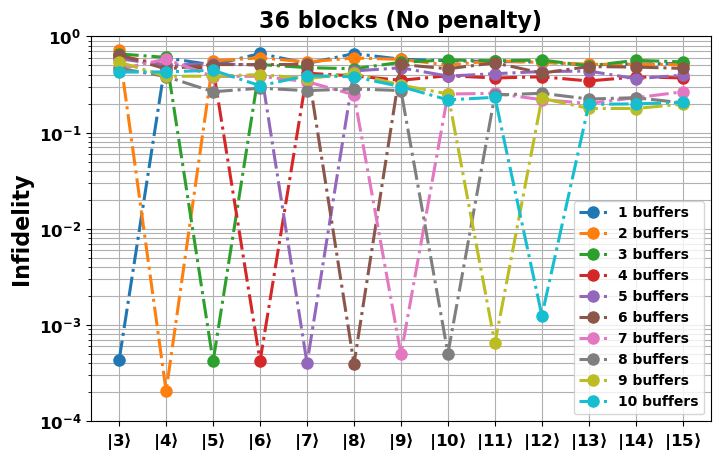

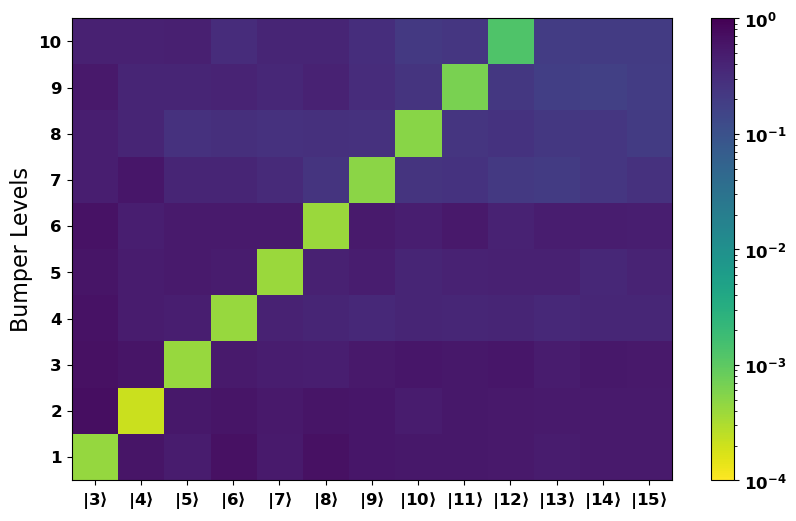

In [22]:
bumper_check = 13
vmin0 = 1e-4
vmax0 =1
plt.rcParams["font.weight"] = "bold"
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12 

seq_len = 36
plt.figure(figsize =[8,5])
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_0_out)):
    plt.plot(x2, dictlist19_0_out[k]['Bump_Infid'],  'o-.', markersize=8, lw = 2.2, label=f'{k+1} buffers')
plt.title(f'{seq_len} blocks (No penalty)', fontsize =16, fontweight='bold')
plt.ylabel('Infidelity', fontsize =16, fontweight='bold')
plt.ylim(vmin0,vmax0)
plt.yscale('log')
plt.xticks(x2)
plt.legend()
plt.xticks(x2, [rf"$|{i}\rangle$" for i in x2])
# plt.xlabel('Fock State', fontsize =16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QutritGate_loss0.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

    

L = len(dictlist19_0_out)
data = np.zeros((len(dictlist19_0_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_0_out[i]['Bump_Infid']

vmin0 = 1e-4
vmax0 = 1
plt.figure(figsize=(10,6))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log', vmin = vmin0, vmax=vmax0)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()      # ticks=[0.000001,0.00001, 0.001, 0.01, 0.1, 0.8]
plt.xticks(x3, [rf"$|{i}\rangle$" for i in x2])
plt.yticks(x4, [L-i for i in range(L)])
# plt.xlabel('Fock States',fontsize=16)
plt.ylabel('Bumper Levels',fontsize=16)
plt.savefig('New_Gate_loss0.pdf', format = 'pdf')
plt.show()

## Qutrit (N_trunc = 3), penalize largest Fock state (pen =1), sweep over 1-10 bumper states

In [133]:
dictlist19_0b = [] 
N_trunc = 3
seq_len = 36
thres = 1e-5
pen = 1
for bumper in range(1,11):
    %time dictlist19_0b.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False))


********** Optimizing Parameters for 36 blocks and 1 bumper state(s) **********
CPU times: user 1min 25s, sys: 1.01 s, total: 1min 26s
Wall time: 1min 25s

********** Optimizing Parameters for 36 blocks and 2 bumper state(s) **********
CPU times: user 1min 44s, sys: 1.19 s, total: 1min 45s
Wall time: 1min 44s

********** Optimizing Parameters for 36 blocks and 3 bumper state(s) **********
CPU times: user 1min 1s, sys: 597 ms, total: 1min 2s
Wall time: 1min 1s

********** Optimizing Parameters for 36 blocks and 4 bumper state(s) **********
CPU times: user 1min, sys: 614 ms, total: 1min
Wall time: 1min

********** Optimizing Parameters for 36 blocks and 5 bumper state(s) **********
CPU times: user 1min 15s, sys: 911 ms, total: 1min 15s
Wall time: 1min 15s

********** Optimizing Parameters for 36 blocks and 6 bumper state(s) **********
CPU times: user 17d 21h 24min 53s, sys: 53min 8s, total: 17d 22h 18min 1s
Wall time: 14h 19min 35s

********** Optimizing Parameters for 36 blocks and 7 b

In [145]:
# dictlist19_0b = [{'Infidelity': 0.0002888058661483228,
#   'Betas_real': tc.tensor([-0.2936, -0.0143, -0.2164, -0.6814,  0.6502, -0.0692, -0.4801, -0.1590,
#           -0.2639, -0.9299,  0.7318,  0.0052,  1.6152,  1.5468, -1.1371, -0.1547,
#           -0.0661, -0.1692,  0.4976,  0.6009,  0.8128, -0.4092, -0.7565,  0.1991,
#           -0.2914, -0.2264,  1.4095,  1.0149,  1.1337, -0.9329, -1.2088, -1.1490,
#           -0.5568,  0.7090,  0.5058,  0.0188]),
#   'Betas_imag': tc.tensor([-0.0897, -0.1824, -0.3617,  0.0962, -0.5812,  0.8550, -0.1342,  0.5531,
#           -0.9656, -0.4545, -0.9186, -1.7734, -0.1790, -0.9385, -0.2751,  0.6566,
#            0.7620,  1.0354,  0.0727, -0.0335, -0.0281,  0.2855,  1.3108,  1.7977,
#           -0.2803, -0.2679,  1.7306,  0.1061,  1.1285,  0.5985, -0.4694, -0.4896,
#            0.0041,  2.0165, -0.1023,  0.0764]),
#   'Phis': tc.tensor([ 1.2433,  0.0039, -0.2640, -0.9211, -0.6243,  1.2870,  1.7091, -1.2469,
#           -0.2877,  0.5017, -0.7034, -1.4035,  0.7915, -1.7197, -1.9719,  2.3387,
#            2.1659,  0.3793,  2.1889, -1.2768, -1.2801,  1.1794,  0.1106, -0.0544,
#           -1.2061,  0.2333,  0.6402,  0.5046, -0.3051, -0.2177,  0.6401, -2.1344,
#           -0.0637, -0.1263,  2.2743,  1.1083]),
#   'Thetas': tc.tensor([-1.0395, -1.0423, -0.2058,  0.3644,  3.0820, -1.6064,  1.2191, -2.1023,
#            2.3471, -0.6880,  0.4957,  0.2941,  1.1116, -0.5443,  0.3797,  0.2203,
#           -0.6445,  1.4338, -0.6580,  0.2419, -0.4304, -0.3933, -1.9120, -0.3295,
#           -0.0537, -0.8905,  1.5746,  2.2549,  1.2742, -0.6466, -1.2196,  0.1743,
#           -0.1386,  0.2717, -1.5507, -1.8685])},
#  {'Infidelity': 0.0003065702330786735,
#   'Betas_real': tc.tensor([-0.6745, -0.0959, -0.3540, -1.0740,  1.0549, -0.5064, -0.1015, -1.0274,
#            0.0554, -1.7822,  0.6134, -0.7013,  1.7404,  2.0720, -1.6765,  0.5192,
#            0.9658, -0.3661,  1.5672,  2.4378,  0.3505, -0.7099, -0.4065,  0.5147,
#           -0.3265, -0.1685,  2.0396,  0.3578,  0.0184, -0.6691, -0.1009, -0.9515,
#            0.5299,  1.8098, -0.2865, -0.1109]),
#   'Betas_imag': tc.tensor([-0.1495, -0.3727, -1.2229, -0.3897, -1.5727,  0.1130, -0.2241, -0.2812,
#           -0.5159,  0.1496, -0.0238, -2.3174, -1.3352, -0.3949, -0.5613,  0.8328,
#            1.3885,  0.8889,  0.2921, -0.1340,  0.4103, -0.5054,  0.3066,  1.1445,
#            0.1154,  0.3456,  0.4109,  0.2082,  0.3444,  0.4504,  0.4400,  1.3360,
#            1.0496,  0.8111, -1.6126, -0.3064]),
#   'Phis': tc.tensor([ 0.3338,  0.6353, -0.2950, -1.3114, -1.0889,  1.4812,  1.6424, -0.8032,
#           -0.6184,  0.4711, -1.4122, -0.3958,  0.8177, -2.1961, -1.8698,  1.5967,
#            2.1619, -0.8148,  1.8115, -1.2483, -0.7094,  0.6089, -0.2644, -0.0678,
#           -1.5124, -1.3459,  0.8455,  1.1264,  0.1730, -0.6011,  0.6694, -0.5446,
#            0.9426,  0.4237,  2.9336,  0.9244]),
#   'Thetas': tc.tensor([-5.1175e-01, -1.4178e+00, -4.1798e-01,  1.5946e-01,  2.9729e+00,
#           -1.3420e+00,  7.3220e-01, -1.8509e+00,  3.3733e+00, -5.3295e-01,
#           -1.2059e+00,  2.9448e-01,  3.2397e-01,  4.0313e-01, -3.9109e-02,
#           -1.2607e+00,  3.8581e-01,  2.0051e+00, -4.3164e-01,  4.2338e-01,
#            5.9858e-01, -4.3482e-01,  2.1780e-03, -4.4559e-01, -2.2637e-01,
#           -1.4717e+00,  1.3305e+00,  8.4832e-01,  1.6584e+00,  1.8219e+00,
#           -1.5571e+00, -4.5705e-01,  9.6058e-02, -1.5184e-01,  1.8786e+00,
#           -1.4057e+00])},
#  {'Infidelity': 0.0005406829295679927,
#   'Betas_real': tc.tensor([-0.9592,  0.4293, -0.1209, -1.6053,  1.2215, -0.2174, -0.4511, -0.7227,
#            0.0538, -0.8203,  0.1599, -0.4311,  1.1386,  1.8965, -0.5767, -0.1468,
#            0.6285, -0.1077,  0.7765,  0.8942,  0.6897, -0.2168, -0.0934, -0.1986,
#           -0.4009,  0.1986,  1.2670,  0.4143, -0.3551, -0.7409, -0.6060, -0.1014,
#            0.6490,  0.3632, -0.2072,  0.4896]),
#   'Betas_imag': tc.tensor([-0.3027, -0.6151, -0.7568, -0.2139, -0.7858,  0.6936,  0.0612,  0.4120,
#           -0.6605,  0.2878,  0.5574, -0.7388, -0.3993, -0.9286, -0.4874,  0.8234,
#            0.3556,  0.4047, -0.3850, -0.0270, -0.6281, -0.4277,  0.7536,  0.6350,
#            1.3179, -0.3541, -0.0880, -0.3644, -0.4751,  1.2345,  0.2631,  0.4355,
#            0.4199,  0.5119, -0.1180,  0.0524]),
#   'Phis': tc.tensor([ 1.2413,  0.8593, -0.2826, -0.8442, -0.1910,  0.5995,  1.5840, -1.9756,
#           -0.1041,  0.9720, -0.8113, -0.6879,  1.1439, -1.7904, -1.3369,  2.3591,
#            1.8264,  0.5035,  1.5400, -0.9027, -0.5393,  1.2033,  0.4208,  0.5835,
#           -1.5704, -0.9084,  0.1131,  0.3942, -0.2167, -0.8386,  0.5005, -0.6242,
#            0.2563,  0.4435,  3.3520,  0.9578]),
#   'Thetas': tc.tensor([-0.8642, -1.4805, -0.5212,  0.1574,  3.0823, -2.4432,  0.9491, -1.9236,
#            1.7483, -0.7750,  0.5317,  1.2878,  0.5039, -0.0966, -0.6282, -1.4538,
#            0.9030,  2.1192, -0.6740,  0.2010, -1.0910, -0.3773, -0.7194, -0.8394,
#           -0.5991, -1.4287,  1.7918,  0.9263,  1.0645,  0.1059, -1.2024,  0.6734,
#            1.0349,  0.0046,  1.0807, -1.5479])},
#  {'Infidelity': 0.0005259676836431026,
#   'Betas_real': tc.tensor([-0.2603,  0.7185, -0.3063, -0.7631,  0.3323,  0.3324,  0.4099, -1.4204,
#           -0.0159, -0.6242,  0.4180, -0.6825,  1.7678,  1.7993, -0.7373,  0.0270,
#            0.1023, -0.2554,  0.8955,  1.4738,  0.2774, -0.8213, -0.4085,  0.2799,
#           -0.4874,  0.2395,  1.8540,  0.9238,  0.9623, -0.9646, -1.3397, -1.4582,
#           -0.4841,  1.0588,  0.1244, -0.3046]),
#   'Betas_imag': tc.tensor([-0.5358, -1.0944, -0.6655, -0.2833, -1.4288,  1.4828,  0.4348,  0.1037,
#           -1.3644,  0.3530,  0.6878, -1.1603, -0.0768, -0.2984, -0.2485,  0.7827,
#            1.2752,  0.2304, -0.4220,  0.3998,  0.4843,  0.0762,  1.3807,  0.7260,
#           -0.4815,  0.0874,  0.4590, -0.0344,  0.3375,  0.4725,  0.7806,  0.4049,
#            0.7612,  1.5243, -0.3491, -0.1912]),
#   'Phis': tc.tensor([ 1.0664,  0.8929, -1.2922, -1.4836, -0.6467,  1.3197,  1.9231, -1.6945,
#            0.8562,  1.3556, -0.9278, -1.5060,  0.2054, -1.7647, -1.5944,  2.0575,
#            2.3333, -0.1216,  1.4500, -0.7963, -0.8135,  1.3688, -0.0058, -0.2173,
#           -1.4781, -0.3654,  0.1148,  0.7604,  0.6882, -0.6061,  0.6670, -0.6745,
#           -0.3194, -0.3810,  3.2230,  0.6837]),
#   'Thetas': tc.tensor([-0.7420, -0.5767, -1.2716,  0.4459,  2.4390, -1.7087,  1.1230, -2.2511,
#            2.5979, -0.3946, -0.8739, -0.0189,  0.7384, -0.0479, -0.4446, -1.3952,
#            1.0995,  1.9541, -0.7194, -1.3242,  0.3235,  0.1827, -0.9877, -0.6708,
#           -0.0315, -1.3232,  1.3036,  0.7256,  0.2473,  0.2036,  0.1556,  0.9851,
#            0.3747,  0.9143, -1.2712, -1.4676])},
#  {'Infidelity': 0.0013455507578328252,
#   'Betas_real': tc.tensor([-1.0185,  0.5641,  0.1999, -1.0498,  1.1459, -0.2695, -0.3829, -1.0623,
#            0.8109, -1.1115, -0.0808, -0.6358,  1.1543,  1.9000, -1.5511, -0.4241,
#           -0.3998,  0.4992,  1.2031,  0.7843,  1.1586,  0.1017, -0.5606,  0.0514,
#           -0.0256, -0.3374,  2.5942,  1.3298,  0.4345, -0.5610, -1.3615, -0.9906,
#            0.3040,  0.7490,  0.2595,  0.1277]),
#   'Betas_imag': tc.tensor([-1.2778, -1.3130, -1.5030, -0.8563, -0.9326,  0.7104,  0.0826,  0.4775,
#           -1.5756, -0.6449,  0.1916, -2.0008, -0.4148,  0.1299, -0.5275,  1.1068,
#            1.2568,  0.3005, -0.6455,  0.4215,  0.2798, -0.2022,  1.2257,  1.0307,
#            0.5809,  0.2878,  0.3404, -0.3339,  0.7211,  0.9447,  0.5123,  0.2305,
#           -0.0330,  0.4328, -1.2791, -0.1828]),
#   'Phis': tc.tensor([ 0.7484,  0.4326, -0.2837, -0.9939, -1.0714,  1.1742,  0.8262, -1.0350,
#           -0.5573,  0.8823, -0.8374, -0.8555,  1.0947, -1.8399, -1.0989,  1.6935,
#            1.4040, -0.0655,  1.8090, -1.3789,  0.1565,  1.0582,  0.4426,  0.3764,
#           -1.6179,  0.1163, -0.7570, -0.9230,  1.0076, -0.5052,  1.6158,  0.2096,
#            0.6560, -0.2538,  2.2094,  1.0322]),
#   'Thetas': tc.tensor([-0.2949, -0.4643, -0.1752,  0.5882,  1.8457, -1.5243,  0.5541, -1.8427,
#            2.9134, -0.5257, -0.1157,  0.3780,  0.1494, -0.0446, -0.4643, -0.5767,
#           -0.5665,  2.0104, -0.3639,  0.3747, -0.9865, -0.8343, -0.6101, -0.7732,
#           -1.5627, -1.8723,  2.0858,  0.6848,  0.5004,  0.6896, -1.0123,  0.6868,
#            1.5218, -0.6785,  0.2017, -1.3935])},
#  {'Infidelity': 0.000810532714240253,
#   'Betas_real': tc.tensor([-1.2618,  0.8741,  0.8171, -0.6489,  1.3821,  0.2260, -0.2043, -1.0754,
#           -0.3355, -0.3737,  0.9267, -0.4551,  0.8705,  1.3172, -0.6987, -0.1630,
#            0.2790, -0.2626,  1.0481,  0.9408,  0.5868,  0.0697, -0.8991,  0.3813,
#            0.4512, -0.4495,  1.5828,  0.5983,  0.5917, -1.3869, -1.4219, -1.1367,
#           -0.4369,  0.1868,  0.2729,  0.8020]),
#   'Betas_imag': tc.tensor([-0.0580, -0.8486, -0.4982,  0.6859, -0.5381,  0.9755,  0.4224, -0.2131,
#           -0.9571,  0.4826, -0.0326, -2.8111, -0.4361, -0.2636, -0.9427,  0.1729,
#            0.7121,  0.1308,  0.2859,  0.6375, -0.5249,  0.1132,  0.9735,  0.6259,
#           -0.1692, -0.3468,  0.5943,  0.7118,  0.7986,  0.7564,  1.7969,  0.5190,
#            0.3106,  1.7553, -1.1493, -1.1040]),
#   'Phis': tc.tensor([ 1.7946,  0.5136, -0.4734,  0.1647, -0.0486,  0.6054,  1.6800, -1.5522,
#           -0.2102,  1.1439, -1.0803, -2.1390,  0.4703, -1.4126, -1.5876,  2.8880,
#            1.8150, -0.0213,  0.9352, -2.0267, -0.9648,  1.8038,  0.4459, -0.2238,
#           -0.4461, -0.2393,  0.2200,  0.5096, -0.0858, -0.9993,  1.1094, -0.4894,
#            0.0265,  0.2139,  2.2730,  0.5118]),
#   'Thetas': tc.tensor([-1.0275, -1.3662, -0.2107,  0.6468,  1.9377, -0.7648,  0.6244, -1.6765,
#            2.2710, -0.7681, -0.7868,  0.8945,  0.3670,  0.2983, -0.2418, -1.9650,
#            0.8085,  1.9455, -1.0409, -0.4408,  0.7611, -1.6456, -0.5966, -1.2344,
#           -0.3902, -0.9038,  1.1427,  0.6536,  0.0656,  0.6671, -0.2072,  0.6352,
#            0.4431,  0.9042,  1.0158, -0.3435])},
#  {'Infidelity': 0.0015273552853614092,
#   'Betas_real': tc.tensor([-0.3576,  1.0539,  0.2178, -1.2183,  1.4291, -0.7182,  0.1160, -1.0219,
#            0.6800, -0.4206,  0.4400, -1.1053,  1.4663,  2.3161, -0.5784,  0.1818,
#            0.3115, -0.3476,  2.2293,  1.7731,  0.5857,  0.0776, -1.0604, -0.3969,
#            0.0942, -0.1615,  2.3618,  1.2934,  0.3506, -0.3885, -1.0280, -1.2151,
#           -0.4023,  0.3009, -0.0231,  0.2001]),
#   'Betas_imag': tc.tensor([-0.2936, -0.2114, -1.0137, -0.5910, -0.6973,  0.6998,  0.0677, -0.7602,
#           -0.0937,  0.2659,  0.3499, -1.4236, -0.0837, -0.2648, -1.0469,  0.3343,
#            1.1772,  0.4474, -0.9887,  0.4748, -0.3050, -1.1861,  0.5670,  0.9398,
#            0.1495,  0.1250,  0.4649,  0.7494,  0.8952, -0.5639,  0.4525,  0.5964,
#            0.1924,  0.9422, -0.6807, -0.2287]),
#   'Phis': tc.tensor([ 1.2037,  1.0586, -0.6578, -1.0642, -0.4690,  0.4745,  2.1205, -1.2647,
#           -0.2904,  1.2031, -0.9975, -1.9062,  1.4768, -1.1663, -1.8463,  1.9871,
#            1.4849, -0.5729,  1.9524, -1.6005, -0.8546,  1.8369, -0.4266, -0.4854,
#           -1.0949, -0.6003, -0.1178,  0.9381,  0.4163, -0.5830,  0.9051, -0.1084,
#           -0.1768,  0.1014,  2.7983,  0.5565]),
#   'Thetas': tc.tensor([-1.2766, -2.1422, -0.6179,  0.5876,  2.9900, -1.6867,  0.9930, -1.6283,
#            3.0570, -0.8223, -0.7597,  0.7862,  0.4036,  0.0920, -0.8869, -1.1430,
#            0.0078,  0.9129,  0.0629, -0.6098, -0.6126, -0.6593, -0.7246, -0.2843,
#           -0.7986, -0.7091,  1.4464,  0.3815,  0.4566, -0.9020, -0.2220,  0.5470,
#            0.4803,  0.7883, -0.1866, -1.4898])},
#  {'Infidelity': 0.000706931110471487,
#   'Betas_real': tc.tensor([-0.4227,  1.4239,  0.2577, -2.0340,  1.4916, -0.1110, -0.4180, -2.0369,
#            0.7997, -0.9755,  0.7647, -0.8664,  1.2087,  1.3247, -0.7860,  0.0380,
#            0.3429, -0.3518,  1.5844,  1.7893,  0.4935, -0.3066, -0.7820,  0.3770,
#            0.0880,  0.1059,  1.7282,  1.0643,  1.6641, -1.1792, -1.7721, -1.1690,
#           -0.3289,  0.1769, -0.9873,  0.0026]),
#   'Betas_imag': tc.tensor([-0.3738, -0.6032, -0.9905,  0.0084, -1.0502,  1.4871,  0.4752,  0.0661,
#           -1.2800,  0.2021, -0.0266, -2.2424, -0.5580, -0.0475,  0.2146,  0.7744,
#            0.8200,  0.4507, -0.7318,  0.2516, -0.3660, -0.5718,  1.5004,  1.1724,
#            0.0537, -0.1738, -0.2506,  0.3593,  0.8535, -0.4541,  0.5171,  0.8184,
#            0.3040,  1.4016,  0.1297,  0.0186]),
#   'Phis': tc.tensor([ 0.8845,  1.0262, -0.8163, -0.8376, -0.8204,  1.1293,  1.5207, -2.0662,
#            0.2611,  1.1789, -0.8160, -1.8386,  0.6636, -1.4017, -1.3560,  2.5621,
#            1.0729,  1.3723,  0.9160, -1.8485, -1.0206,  1.0769,  0.0276,  0.0345,
#           -1.2017, -1.0324,  0.0354,  0.8442,  0.0907, -2.3963,  0.6461, -0.1171,
#            0.5075,  0.2327,  3.4650, -0.4806]),
#   'Thetas': tc.tensor([-1.5236, -1.6876,  0.3524,  0.3399,  3.0112, -1.2984,  0.7687, -1.9444,
#            3.1461, -0.0636, -0.2286,  0.3039,  0.9804,  0.1848,  0.9404, -2.0367,
#            1.1055,  0.7721, -0.9536, -0.1975, -0.6468, -0.5296, -0.4852, -0.0216,
#           -0.7208, -1.7087,  1.5030,  1.3073,  0.7045,  0.8913,  0.1599,  0.2311,
#            0.0358,  0.6676,  0.5687, -1.7845])},
#  {'Infidelity': 0.0008064921130426228,
#   'Betas_real': tc.tensor([-0.4501,  1.4167,  0.5436, -0.9187,  0.9083,  0.3213,  0.0645, -0.8843,
#           -0.0552, -1.0030,  0.5662,  0.0193,  0.9973,  1.5425, -0.5145, -0.1809,
#            0.0896,  0.4720,  0.8071,  0.7928,  0.7152, -0.3715, -0.7558,  0.0949,
#            0.6534, -0.1131,  1.9041,  1.2206,  0.3390, -0.6273, -1.1211, -0.8472,
#            0.0087,  0.8778, -0.1490, -0.5216]),
#   'Betas_imag': tc.tensor([-0.2331, -1.7000, -1.5447, -1.5174, -0.1197,  0.9620,  0.1348, -0.1371,
#           -0.8101,  0.3822,  0.1496, -0.6491, -0.2362, -0.2237, -0.9895,  0.8918,
#            1.1230,  1.0747,  0.5172,  0.3340,  0.5598, -0.1243,  1.1333,  1.2203,
#           -0.5916,  0.9360,  0.0881,  0.0698,  0.9373,  0.0447,  0.2436,  0.1400,
#            0.2834,  1.0900, -0.7176, -0.1073]),
#   'Phis': tc.tensor([ 0.6696,  1.0878, -0.1336, -1.6054, -2.1056,  0.5482,  2.0968, -1.1875,
#           -0.5731,  1.1466, -1.1499, -1.0330,  1.9878, -1.4036, -1.9571,  1.0551,
#            1.6995,  0.0929,  2.2535, -0.7341, -0.5829,  1.6782,  0.4329,  0.0884,
#           -1.1971,  0.3585,  0.2630, -0.9809, -0.1625, -1.7205,  0.5832, -0.0850,
#            0.2413, -0.0490,  2.3035,  0.7905]),
#   'Thetas': tc.tensor([-1.4318e+00, -1.8013e+00,  2.1185e-02,  9.3458e-01,  2.8035e+00,
#           -1.3564e+00,  1.7591e+00, -1.6360e+00,  2.6326e+00, -5.8562e-01,
#           -3.3091e-02,  9.4215e-01,  8.9468e-01,  2.1655e-01,  4.7922e-01,
#           -9.9133e-01,  5.9554e-01,  1.9798e+00, -5.2888e-01,  3.1125e-01,
#           -4.9624e-01, -4.1722e-04, -1.4188e-01, -2.1922e-01, -1.2846e+00,
#           -2.4636e+00,  8.9359e-01,  2.6986e-01, -8.4783e-02,  5.6580e-01,
#            7.0703e-01,  4.4464e-01, -9.0180e-01,  6.6582e-01, -8.7865e-01,
#           -1.9600e+00])},
#  {'Infidelity': 0.0011977331014350057,
#   'Betas_real': tc.tensor([-0.6951,  0.8673, -0.2492, -1.0878,  1.0551,  1.2414,  0.1700, -0.5000,
#           -0.3841, -0.8176,  0.0396, -0.6367,  1.5361,  1.6166, -0.8815, -0.0910,
#            0.3664, -0.4169,  1.5876,  2.0601,  0.7875, -0.2490, -0.7070,  0.4613,
#            0.5673, -0.2482,  2.0018,  0.3653,  0.0321, -0.4714, -1.2785, -0.5889,
#            0.2980,  0.9101,  0.4134, -0.0599]),
#   'Betas_imag': tc.tensor([-0.3390, -1.3356, -1.1624, -0.6919, -0.8937,  0.5006, -0.0034,  0.1622,
#           -0.6167,  1.0665,  0.0826, -1.5215,  0.2487,  0.0857, -0.0084,  0.8121,
#            1.3453,  0.2313, -0.4672,  0.3902, -0.2977, -1.4283,  0.5183,  0.5414,
#           -0.0698, -0.1703,  0.6598,  0.2746,  1.2300,  0.2220, -0.3121,  0.1723,
#            0.7009,  1.7218, -0.5540, -0.2188]),
#   'Phis': tc.tensor([ 1.2218,  1.0390,  0.2760, -0.9286, -1.6843,  1.2265,  1.7745, -1.0581,
#           -0.2244,  0.7718, -0.7462, -0.7770, -0.0445, -1.6386, -1.5163,  2.1848,
#            1.9858, -0.0213,  1.9262, -1.5844, -0.9341,  1.3109, -0.0366, -0.5447,
#           -1.1193, -0.8837,  0.2878, -0.8317, -0.9980, -0.3920,  0.6543, -0.4557,
#            0.6816, -0.4176,  2.4306,  0.3132]),
#   'Thetas': tc.tensor([-1.6105, -1.9989, -0.9800,  0.5268,  1.6321, -0.2760,  0.8097, -1.9741,
#            2.2343, -1.1634, -0.1008,  1.0821, -0.4520, -0.0323,  0.0754, -1.1570,
#            1.0365,  1.8969, -0.4561, -0.5071, -0.2204, -0.4085, -1.1387, -0.6787,
#           -0.5860, -1.4138,  0.9681,  0.4319,  0.2025,  0.6785,  0.2577,  0.8682,
#            0.9934, -0.6291,  0.7141, -1.1915])}]

In [19]:
dictlist19_0b_out = []         # List of dictionaries of tge form  {'Block_Pop': pop_list, 'Bump_Infid': infid_list }
pen = 1
for k in range(len(dictlist19_0b)):
    betas_real = dictlist19_0b[k]['Betas_real']
    betas_imag = dictlist19_0b[k]['Betas_imag']
    phis = dictlist19_0b[k]['Phis']
    thetas = dictlist19_0b[k]['Thetas']
    bumper_check = 13
    dictlist19_0b_out .append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

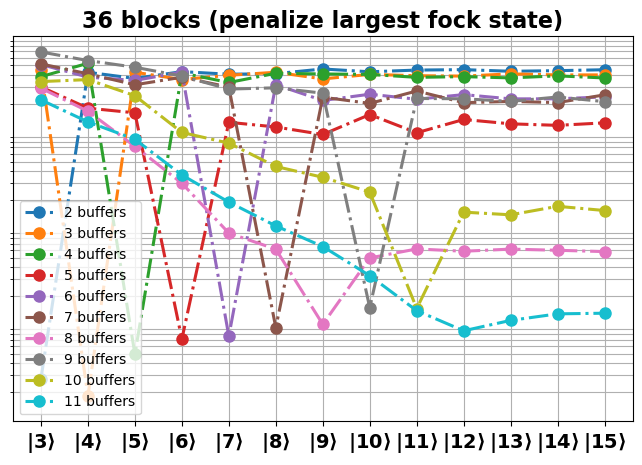

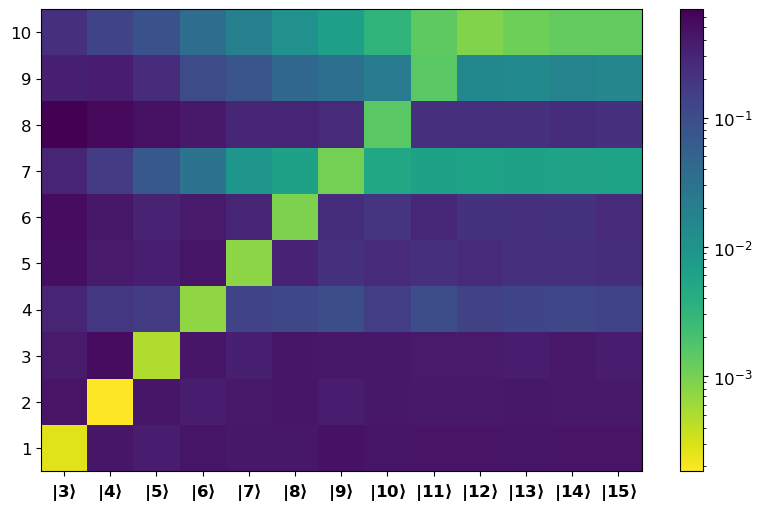

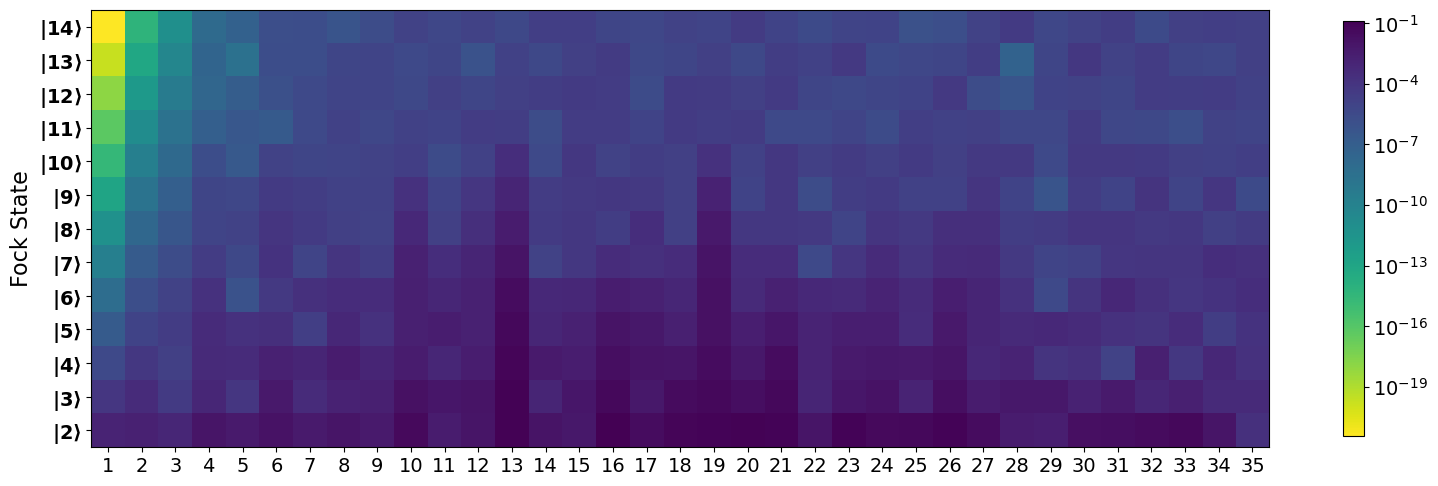

In [33]:
plt.figure(figsize =[8,5])
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_0b_out)):
    plt.plot(x2, dictlist19_0b_out[k]['Bump_Infid'],  'o-.', markersize=8, lw=2.2, label=f'{k+2} buffers')
plt.title('36 blocks (penalize largest fock state)', fontsize =16, fontweight='bold')
# plt.ylabel('Infidelity', fontsize =16, fontweight='bold')
plt.ylim(vmin0,vmax0)
plt.yscale('log')
plt.yticks([])
plt.legend()
plt.xticks(x2, [rf"$|{i}\rangle$" for i in x2])
# plt.xlabel('Fock State',fontsize =16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QutritGate_loss1.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


L = len(dictlist19_0b_out)
data = np.zeros((len(dictlist19_0b_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_0b_out[i]['Bump_Infid']

plt.figure(figsize=(10,6))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log')  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(x3, [rf"$|{i}\rangle$" for i in x2])
plt.yticks(x4, [L-i for i in range(L)])
# plt.xlabel('Fock States', fontsize=16)
# plt.ylabel('Bumper Levels', fontsize=16)
# plt.savefig('New_Gate_loss0b.pdf', format = 'pdf')
plt.show()


bumper = 13  
lev = 10
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 36)
x6 = range(bumper)
plt.imshow(dictlist19_0b_out[-1]['data'], cmap='viridis_r', norm='log')  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.9)
plt.xticks(range(35), x5)
plt.yticks(x6, [rf"$|{i+2}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16)
# plt.savefig(f'{lev}pen1.pdf', format = 'pdf', bbox_inches='tight')
plt.show()




## Qutrit (N_trunc = 3), penalize two largest Fock states (pen=2) , sweep over 2-10 bumper states

In [57]:
dictlist19_1 = [] 
N_trunc = 3
seq_len = 36
thres = 1e-5
pen = 2
for bumper in range(2,11):
    %time dictlist19_1.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False))


********** Optimizing Parameters for 36 blocks and 2 bumper state(s) **********
CPU times: user 3min 1s, sys: 1.26 s, total: 3min 3s
Wall time: 3min 1s

********** Optimizing Parameters for 36 blocks and 3 bumper state(s) **********
CPU times: user 1min 25s, sys: 487 ms, total: 1min 25s
Wall time: 1min 25s

********** Optimizing Parameters for 36 blocks and 4 bumper state(s) **********
CPU times: user 2min 4s, sys: 687 ms, total: 2min 5s
Wall time: 2min 4s

********** Optimizing Parameters for 36 blocks and 5 bumper state(s) **********
CPU times: user 1min 39s, sys: 505 ms, total: 1min 39s
Wall time: 1min 39s

********** Optimizing Parameters for 36 blocks and 6 bumper state(s) **********
CPU times: user 1d 3h 33min 36s, sys: 42.1 s, total: 1d 3h 34min 18s
Wall time: 51min 42s

********** Optimizing Parameters for 36 blocks and 7 bumper state(s) **********
CPU times: user 11h 52min 48s, sys: 23.9 s, total: 11h 53min 12s
Wall time: 22min 17s
Parser   : 126 ms

********** Optimizing Par

In [31]:
dictlist19_1_out = []
pen = 2
for k in range(len(dictlist19_1)):
    betas_real = dictlist19_1[k]['Betas_real']
    betas_imag = dictlist19_1[k]['Betas_imag']
    phis = dictlist19_1[k]['Phis']
    thetas = dictlist19_1[k]['Thetas']
    bumper_check = 13
    dictlist19_1_out .append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

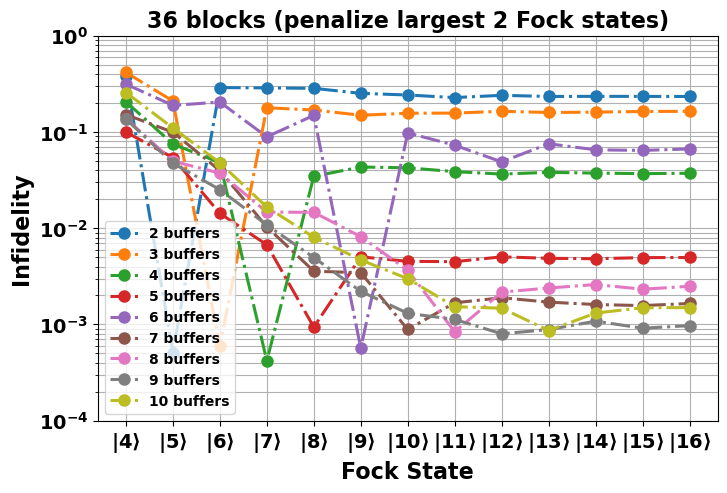

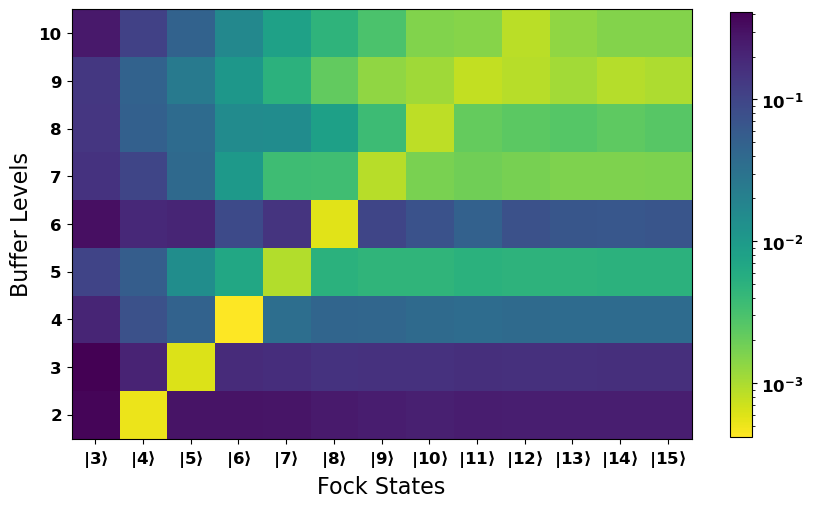

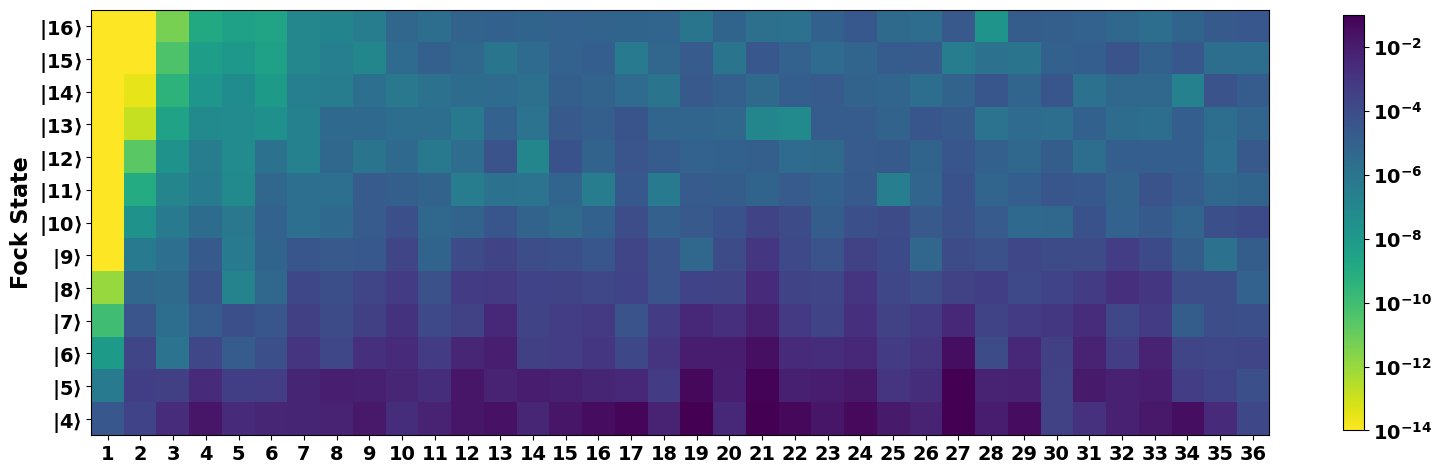

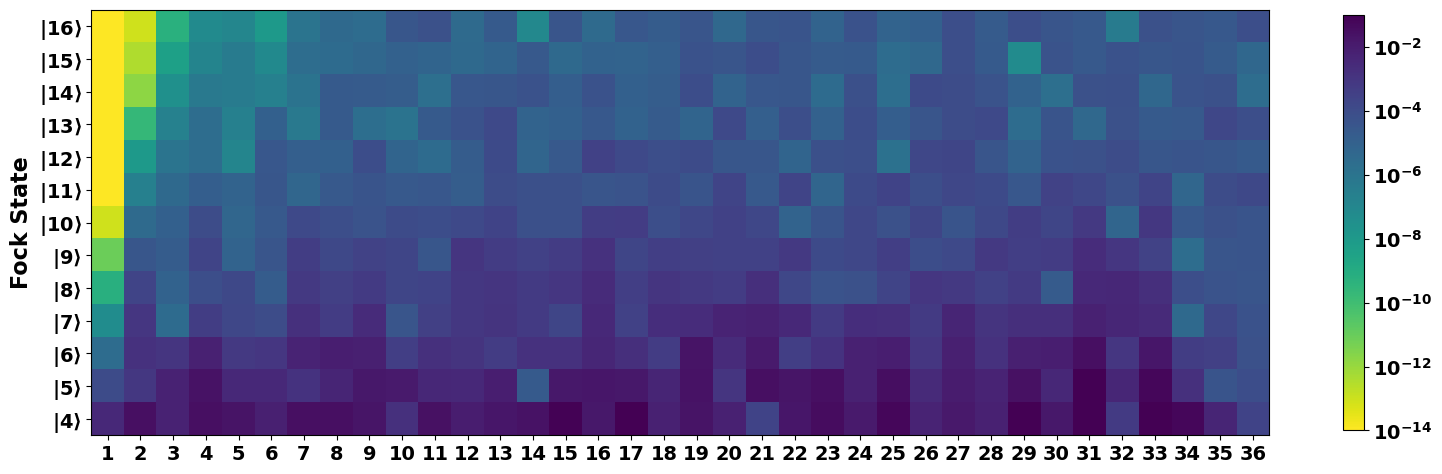

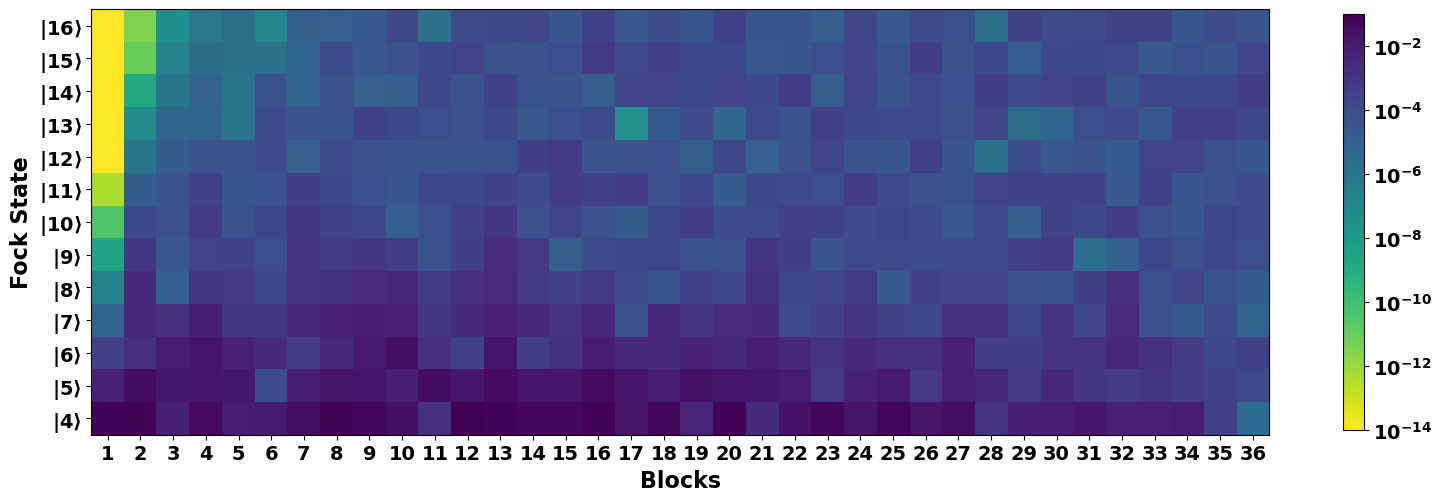

In [58]:
plt.figure(figsize =[8,5])
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_1_out)):
    plt.plot(x2, dictlist19_1_out[k]['Bump_Infid'],  'o-.', markersize=8, lw=2.2, label=f'{k+2} buffers')
plt.title('36 blocks (penalize largest 2 Fock states)', fontsize =16, fontweight='bold')
plt.ylabel('Infidelity', fontsize =16, fontweight='bold')
plt.xlabel('Fock State', fontsize =16, fontweight='bold')
plt.yscale('log')
plt.ylim(vmin0,vmax0)
# plt.xticks(x2)
plt.legend()
plt.xticks(x2, [rf"$\bf|{i+1}\rangle$" for i in x2])
# plt.xlabel('Fock State', fontsize =16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QutritGate_loss2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

L = len(dictlist19_1_out)
data = np.zeros((len(dictlist19_1_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_1_out[i]['Bump_Infid']

plt.figure(figsize=(10,6))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log')  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink = 0.92)
plt.xticks(x3, [rf"$|{i}\rangle$" for i in x2])
plt.yticks(x4, [L-i+1 for i in range(L)])
plt.xlabel('Fock States', fontsize=16)
plt.ylabel('Buffer Levels',fontsize=16)
# plt.savefig('New_Gate_loss2.pdf', format = 'pdf')
plt.show()


lev = 9
bumper = 13 
plt.rcParams['font.weight'] = 'bold'
#  populaiton of state 0
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.weight'] = 'bold'
x5 = range(1, 37)
x6 = range(bumper)
plt.imshow(dictlist19_1_out[lev-2]['data'], cmap='viridis_r', norm='log', vmin= 1e-14, vmax=1e-1)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.9)
plt.xticks(range(36), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'{lev}pen2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


#  population of state 1
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.weight'] = 'bold'
x5 = range(1, 37)
x6 = range(bumper)
plt.imshow(dictlist19_1_out[lev-2]['data1'], cmap='viridis_r', norm='log', vmin= 1e-14, vmax=1e-1)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.9)
plt.xticks(range(36), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks', fontsize=16, fontweight='bold')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1_{lev}pen2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


#  population state 2
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.weight'] = 'bold'
x5 = range(1, 37)
x6 = range(bumper)
plt.imshow(dictlist19_1_out[lev-2]['data2'], cmap='viridis_r', norm='log', vmin= 1e-14, vmax=1e-1)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.9)
plt.xticks(range(36), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
plt.xlabel('Blocks', fontsize=16, fontweight='bold')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'2_{lev}pen2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

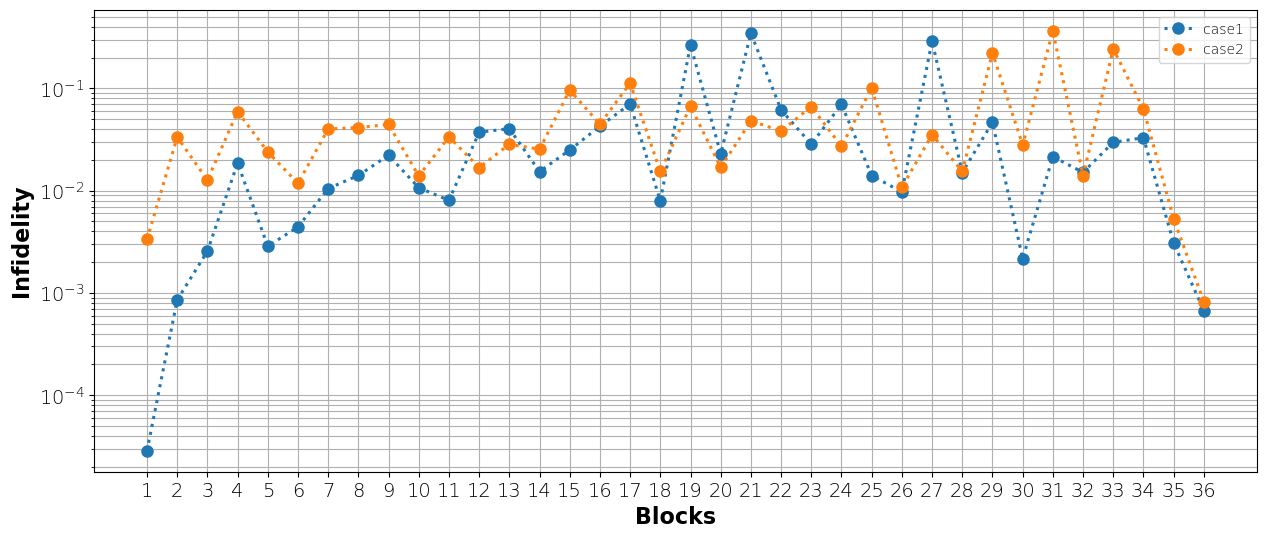

In [199]:
#  Summary plot for sum of infid from fock 4 -14 across 20 blocks 
case = [[],[]]
for b_num in range(36):    
    case[0].append(sum(dictlist19_1_out[7]['data'][2:13,b_num]))      #  9pen1   
    case[1].append(sum(dictlist19_1_out[7]['data1'][2:13,b_num]))       #  9pen1 1 state 


plt.figure(figsize=(15,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.weight'] ='light'
x5 = range(1, 37)
# x6 = range(bumper)
for i in range(len(case)):
    plt.plot(x5, case[i], 'o:' ,lw=2.2, markersize=8, label = f'case{i+1}')
plt.yscale('log')
plt.xticks(x5)
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.xlabel('Blocks', fontsize=16, fontweight='bold')
plt.legend()
plt.ylabel('Infidelity', fontsize=16, fontweight='bold')
# plt.savefig(f'1Qubit{lev}pen1.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

## Qutrit (N_trunc = 3), penalize three largest Fock states (pen =3), sweep over 3-10 bumper states

In [19]:
dictlist19_2 = [] 
N_trunc = 3
seq_len = 36
thres = 1e-5
pen = 3
for bumper in range(3,11):
    %time dictlist19_2.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False))


********** Optimizing Parameters for 36 blocks and 3 bumper state(s) **********
CPU times: user 2min 43s, sys: 8.51 ms, total: 2min 43s
Wall time: 2min 43s

********** Optimizing Parameters for 36 blocks and 4 bumper state(s) **********
CPU times: user 3min 2s, sys: 10.6 ms, total: 3min 2s
Wall time: 3min 2s

********** Optimizing Parameters for 36 blocks and 5 bumper state(s) **********
CPU times: user 1min 21s, sys: 6.23 ms, total: 1min 21s
Wall time: 1min 21s

********** Optimizing Parameters for 36 blocks and 6 bumper state(s) **********
CPU times: user 16h 57min 52s, sys: 17.3 s, total: 16h 58min 9s
Wall time: 31min 49s

********** Optimizing Parameters for 36 blocks and 7 bumper state(s) **********
CPU times: user 22h 2min 3s, sys: 20.4 s, total: 22h 2min 23s
Wall time: 41min 20s
Compiler : 126 ms

********** Optimizing Parameters for 36 blocks and 8 bumper state(s) **********
CPU times: user 13h 57min 31s, sys: 13.9 s, total: 13h 57min 45s
Wall time: 26min 11s

********** Optim

In [20]:
dictlist19_2_out = []
pen = 3
for k in range(len(dictlist19_2)):
    betas_real = dictlist19_2[k]['Betas_real']
    betas_imag = dictlist19_2[k]['Betas_imag']
    phis = dictlist19_2[k]['Phis']
    thetas = dictlist19_2[k]['Thetas']
    bumper_check = 13
    dictlist19_2_out.append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

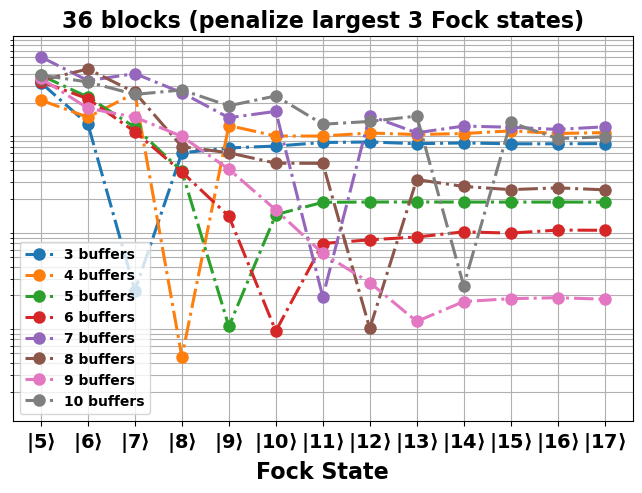

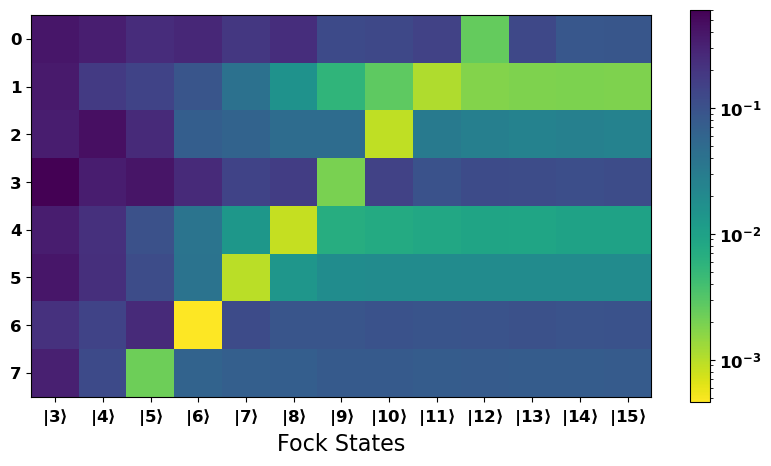

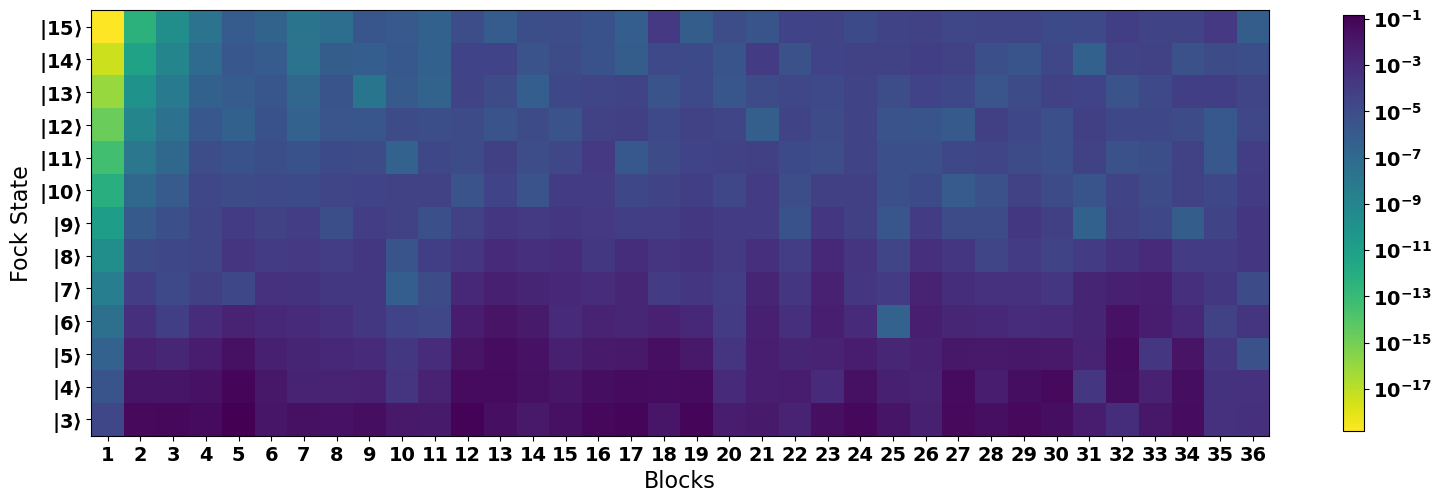

In [27]:
plt.figure(figsize =[8,5])
plt.rcParams['font.weight'] = 'bold'
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_2_out)):
    plt.plot(x2, dictlist19_2_out[k]['Bump_Infid'],  'o-.', markersize=8, lw=2.2, label=f'{k+3} buffers')
plt.title('36 blocks (penalize largest 3 Fock states)', fontsize =16, fontweight='bold')
# plt.ylabel('Infidelity', fontsize =16, fontweight='bold')
plt.ylim(vmin0,vmax0)
plt.yscale('log')
plt.yticks([])
# plt.xticks(x2)
plt.legend()
plt.xticks(x2, [rf"$\bf|{i+2}\rangle$" for i in x2])
plt.xlabel('Fock State', fontsize =16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QutritGate_loss3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

L = len(dictlist19_2_out)
data = np.zeros((len(dictlist19_2_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_2_out[i]['Bump_Infid']

plt.figure(figsize=(10,6))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log')  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.85)
plt.xticks(x3, [rf"$|{i}\rangle$" for i in x2])
# plt.yticks(x4, [L-i+2 for i in range(L)])
plt.xlabel('Fock States', fontsize=16)
# plt.ylabel('Buffer Levels', fontsize=16)
plt.savefig('New_Gate_loss3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

lev = 9
bumper = 13    
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 37)
x6 = range(bumper)
plt.imshow(dictlist19_2_out[lev-3]['data'], cmap='viridis_r', norm='log')  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.9)
plt.xticks(range(36), x5)
plt.yticks(x6, [rf"$|{i+3}\rangle$" for i in np.flip(x6)])
plt.xlabel('Blocks', fontsize= 16)
plt.ylabel('Fock State', fontsize=16)
plt.savefig(f'{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

##   Plot  Data 

In [77]:
#  Plot 2b data
No_buffer= [7.399383775918977e-06, 1.7354855117446277e-06, 6.628170012845658e-06, 9.226213478541467e-06, 9.570219845045358e-06,
                6.20445689492044e-06, 9.127673365583178e-06, 9.054730071511585e-06, 8.549003723601345e-06, 9.709468940855004e-06,
                6.325791673589265e-06, 8.486239494231995e-06, 3.0965184123488143e-06, 9.729957128001843e-06, 6.89973285261658e-06, 7.319340056710644e-06]
Tw0buffer_no_pen= [0.014925281517207623, 0.00788617879152298, 0.004764329642057419, 0.0037556395400315523, 0.0013558893697336316, 0.0017220373265445232,
                 0.0008389040012843907, 0.00019679068645928055, 0.0005191335221752524, 0.00017945939907804132, 0.00019819510634988546,
                 0.0001883382210507989, 0.0001419886975781992, 0.0001257496332982555, 0.00015925306070130318, 0.0002280382759636268]
Tw0buffer_pen_1 = [0.06670095771551132, 0.042723625898361206, 0.01631723903119564, 0.028418738394975662, 0.010748052969574928, 0.013480368070304394,
                     0.004488032776862383, 0.0060235727578401566, 0.007485975045710802, 0.005727538838982582, 0.0034526651725172997, 0.0015995251014828682,
                     0.0021064551547169685, 0.0014198229182511568, 0.0019150248263031244, 0.0012503053294494748]
Tw0buffer_pen_2 = [0.048685334622859955, 0.04841761663556099, 0.019301705062389374, 0.021892916411161423, 0.030351199209690094, 0.02691704034805298,
                     0.028839724138379097, 0.017552420496940613, 0.01016155444085598, 0.012387200258672237, 0.007475798483937979,  0.0046650986187160015,
                     0.005954943597316742, 0.004351732321083546, 0.0030346051789820194, 0.004009997006505728]


#  Fig.6a data
data_Fig6a= {'1': [0.00043296, 0.59531134, 0.50323606, 0.66243345, 0.52163994, 0.6608491, 0.5775091, 0.5566042, 0.5472798, 0.5402933, 0.50475687, 0.5143619, 0.52219206], 
            '2': [0.720299, 0.00020587, 0.55486554, 0.5971973, 0.5410567, 0.5948569, 0.5756807, 0.50250286, 0.55841583, 0.5343983, 0.51171315, 0.5113235, 0.50786954], 
            '3': [0.65567493, 0.6032295, 0.00041852, 0.50946635, 0.47214314, 0.45934168, 0.5370311, 0.56787294, 0.55654615, 0.56662697, 0.49230707, 0.5619028, 0.5418715], 
            '4': [0.6284035, 0.49833468, 0.46429393, 0.00042124, 0.4133873, 0.38721645, 0.3489922, 0.38919035, 0.3688062, 0.3794342, 0.3432249, 0.3781431, 0.36936298], 
            '5': [0.58384097, 0.5009002, 0.5172691, 0.50352925, 0.00040002, 0.43642402, 0.47058558, 0.38548505, 0.40848243, 0.43029618, 0.4349512, 0.3623081, 0.39475814], 
            '6': [0.6387516, 0.45719266, 0.50887305, 0.5072234, 0.5107799, 0.0003951, 0.5091997, 0.45946673, 0.5301325, 0.41448167, 0.4844972, 0.47860157, 0.46405926], 
            '7': [0.45528075, 0.5794974, 0.38153347, 0.38457, 0.33759597, 0.24697192, 0.00049718, 0.25119516, 0.25524756, 0.21935923, 0.20081209, 0.2298739, 0.2649236], 
            '8': [0.46512508, 0.3815974, 0.26539734, 0.28850374, 0.2727718, 0.28378823, 0.2729576, 0.00050568, 0.24534875, 0.25564554, 0.22281165, 0.23009074, 0.20331205], 
            '9': [0.53948206, 0.38437107, 0.38483, 0.3999599, 0.364004, 0.4104828, 0.31123382, 0.25162476, 0.00064418, 0.22675125, 0.17790122, 0.17762844, 0.19766785], 
            '10': [0.42474428, 0.42680594, 0.44350255, 0.30630502, 0.39008272, 0.37942088, 0.30012575, 0.21849994, 0.23213668, 0.00125497, 0.19618666, 0.19857563, 0.20531482]}

#  Fig.6b data
data_Fig6b = {'2': [0.00027705, 0.42272508, 0.36486247, 0.42940435, 0.40337488, 0.4089667, 0.4574108, 0.42771137, 0.4455165, 0.45018542, 0.43284062, 0.4393792, 0.44910404], 
            '3': [0.44585797, 0.00018355, 0.42307258, 0.35539088, 0.39335385, 0.42295936, 0.36055362, 0.4018775, 0.38932648, 0.38570523, 0.40681934, 0.39674607, 0.3969541], 
            '4': [0.3805994, 0.52444446, 0.00049669, 0.41554943, 0.33099356, 0.4124882, 0.40591404, 0.40141997, 0.3743262, 0.3808597, 0.36950585, 0.38790846, 0.36892295], 
            '5': [0.29782394, 0.17919208, 0.1601519, 0.0007136, 0.12772891, 0.114213, 0.09539324, 0.1536763, 0.09945522, 0.1366153, 0.12313667, 0.11875064, 0.12607935], 
            '6': [0.50904995, 0.37630758, 0.34762073, 0.42470086, 0.00076576, 0.31399736, 0.2151922, 0.2500676, 0.22173686, 0.24766271, 0.22370887, 0.22410832, 0.23441269], 
            '7': [0.5166934, 0.40754285, 0.3133208, 0.37549388, 0.29681194, 0.0009378, 0.23280698, 0.20073129, 0.2700704, 0.20432848, 0.21036756, 0.20473647, 0.24623294], 
            '8': [0.28876314, 0.16643058, 0.07181454, 0.02970069, 0.0090258, 0.00613342, 0.00101606, 0.00497854, 0.00617347, 0.00584232, 0.00614931, 0.00597863, 0.00579184], 
            '9': [0.68745613, 0.55928636, 0.4767976, 0.38608137, 0.2827601, 0.2914966, 0.25628388, 0.00151512, 0.22583912, 0.22415447, 0.2105667, 0.23404562, 0.20930713], 
            '10': [0.33822596, 0.3548678, 0.2414069, 0.10015977, 0.07761981, 0.04437878, 0.03428292, 0.02405778, 0.0014848, 0.0148872, 0.01396754, 0.01711493, 0.01547426], 
            '11': [0.2183407, 0.1289498, 0.08509931, 0.03622823, 0.01892635, 0.01071296, 0.00653806, 0.00325499, 0.0014102, 0.00087131, 0.00111748, 0.00130666, 0.00132662]}
#  Fig.6c data
data_Fig6c = {'2': [0.3788106, 0.00051052, 0.28916103, 0.28693825, 0.28395775, 0.25211334, 0.24206728, 0.22772042, 0.24024673, 0.23381357, 0.23449403, 0.23421921, 0.23382066], 
            '3': [0.41535887, 0.20989256, 0.00059603, 0.17847645, 0.16920078, 0.14924367, 0.15643404, 0.1570912, 0.16408522, 0.15936227, 0.16074015, 0.16327192, 0.16387297], 
            '4': [0.20606071, 0.07490689, 0.0479686, 0.00041936, 0.03462578, 0.04323805, 0.04242862, 0.03870682, 0.03651706, 0.03806488, 0.03737063, 0.03690635, 0.03721895], 
            '5': [0.09971981, 0.05415334, 0.01425288, 0.00672854, 0.00093954, 0.00504367, 0.00452988, 0.00449335, 0.00504116, 0.00486829, 0.00481876, 0.00495027, 0.0049646], 
            '6': [0.31395462, 0.18895932, 0.20445608, 0.08898398, 0.14880912, 0.0005674, 0.09775389, 0.07286374, 0.04888144, 0.07540371, 0.0652777, 0.06432953, 0.06660222], 
            '7': [0.15162371, 0.09941284, 0.03962938, 0.01031364, 0.00357828, 0.00344773, 0.00088763, 0.00167908, 0.00189464, 0.00170671, 0.00161179, 0.00157085, 0.00165179], 
            '8': [0.13796088, 0.04978099, 0.03732609, 0.01471487, 0.01461738, 0.00816605, 0.00365293, 0.00084062, 0.00216821, 0.00239238, 0.00259917, 0.00232501, 0.00249184], 
            '9': [0.13627231, 0.0473558, 0.02518485, 0.01079924, 0.00496075, 0.00220799, 0.00130634, 0.0011279, 0.00080026, 0.0008857, 0.00108203, 0.00091474, 0.00097243], 
            '10': [0.2570928, 0.11018094, 0.04775696, 0.01657957, 0.00806818, 0.00468715, 0.00298908, 0.00152962, 0.00147527, 0.00086522, 0.00131406, 0.00149124, 0.00149795]}

#  Fig.6d data
data_Fig6d= {'3': [0.32450157, 0.12039507, 0.00224524, 0.06064275, 0.06829061, 0.07138889, 0.07774857, 0.07869859, 0.07554078, 0.07692587, 0.07535536, 0.07539083, 0.07573014], 
            '4': [0.21392898, 0.14230175, 0.25358114, 0.0004586, 0.11656967, 0.09085385, 0.09068489, 0.09762222, 0.09406557, 0.0963112, 0.10273761, 0.09648307, 0.09848971], 
            '5': [0.38660538, 0.2306116, 0.11208174, 0.03917556, 0.00095313, 0.01384895, 0.01858153, 0.0187159, 0.0187237, 0.01870451, 0.01867755, 0.0186972, 0.01866901], 
            '6': [0.334283, 0.22108911, 0.10062689, 0.03838522, 0.01332977, 0.00085505, 0.00693839, 0.00757688, 0.00810168, 0.00917134, 0.0088965, 0.00956505, 0.00952002], 
            '7': [0.6022964, 0.34111974, 0.40426853, 0.25591037, 0.14053552, 0.16366403, 0.00193658, 0.1473593, 0.09806409, 0.11518501, 0.11205258, 0.10627226, 0.11319508], 
            '8': [0.34305584, 0.45122397, 0.25725573, 0.07049872, 0.06075184, 0.04740711, 0.04716018, 0.00090953, 0.03204336, 0.02717111, 0.02517184, 0.02627782, 0.02505417], 
            '9': [0.36050698, 0.17627381, 0.142537, 0.08995829, 0.04104633, 0.01549198, 0.0054698, 0.00272413, 0.00107461, 0.00173006, 0.00185347, 0.00189687, 0.00183008], 
            '10': [0.38851914, 0.33096114, 0.24546312, 0.27305087, 0.18706827, 0.23692381, 0.12042446, 0.12858431, 0.14627488, 0.00253097, 0.12547322, 0.08539092, 0.08914951]}


# Fig.7a data
data_Fig7a = np.array([[3.78110115e-30, 5.09494129e-16, 4.38646775e-12, 1.31840772e-09,
        3.82267151e-09, 2.58388710e-09, 9.86568764e-08, 1.36516420e-07, 3.07885614e-07, 4.98468580e-06, 2.07044673e-06, 6.96354118e-06,
        9.42472161e-06, 6.76482796e-06, 8.30526369e-06, 7.15224269e-06,6.13565362e-06, 5.45900139e-06, 8.44452245e-07, 6.58463068e-06,
        1.64458640e-06, 1.48364870e-06, 8.78876017e-06, 2.50740195e-05, 3.17381750e-06, 2.15589967e-06, 2.36092783e-05, 1.83797084e-08,
        1.41779747e-05, 1.21159637e-05, 8.19291381e-06, 4.69309407e-06, 1.95185430e-06, 6.28413727e-06, 2.01551811e-05, 2.86223876e-05],
       [7.55626240e-28, 5.35058558e-15, 4.09121209e-11, 5.95164185e-09, 1.11973630e-08, 3.77952736e-09, 9.07512998e-08, 2.46360486e-07,
        1.04417076e-07, 2.76612764e-06, 9.90959597e-06, 4.06731670e-06, 9.34629270e-07, 2.85651095e-06, 8.39072800e-06, 1.34628035e-05,
        4.65615841e-07, 4.86625413e-06, 1.90115752e-05, 9.79845026e-07, 2.89506734e-05, 8.57520990e-06, 2.87579496e-06, 5.59709042e-06,
        1.69954965e-05, 1.92632197e-05, 2.93417514e-07, 1.24267672e-06, 1.01283058e-06, 8.86294401e-06, 1.35564351e-05, 4.52958011e-05,
        9.24879350e-06, 3.05534377e-05, 2.08433448e-06, 2.11282463e-06],
       [1.42031201e-25, 2.87167005e-14, 3.88025750e-10, 1.53986068e-08, 4.58808742e-08, 8.04099187e-09, 2.54979312e-07, 3.48389108e-07,
        1.75717241e-06, 6.14499982e-07, 1.24095186e-06, 2.60034949e-06,  2.96810822e-06, 1.54695920e-06, 1.10082692e-05, 7.01538011e-06,
        2.69632960e-06, 1.01007754e-06, 2.22881117e-05, 1.04216642e-05,  3.29120917e-06, 1.35504424e-05, 1.96058045e-05, 6.96427242e-06,
        5.86170245e-06, 1.93717892e-06, 7.34860669e-06, 3.36402518e-05,  5.52345955e-06, 3.40603510e-05, 1.29763782e-06, 4.54985047e-06,
        4.19394655e-06, 1.97713845e-07, 4.80092713e-05, 1.69712785e-05], [2.47885782e-23, 1.41088869e-13, 3.11002757e-09, 7.10677170e-08,
        5.36990328e-08, 3.08401269e-08, 2.04118749e-07, 3.65529968e-06,  3.45352964e-06, 2.06732170e-06, 1.97586382e-06, 5.66103324e-07,
        7.75186527e-06, 1.14802242e-06, 2.43178802e-05, 1.20739533e-05, 4.34583017e-05, 5.63879667e-06, 5.61359457e-06, 5.27729708e-06,
        1.07558243e-07, 6.70857574e-08, 1.70814692e-05, 1.74130801e-05, 6.93366883e-06, 3.23420354e-05, 2.10948601e-05, 1.05697814e-06,
        2.84233352e-06, 2.02228625e-06, 9.60926991e-06, 2.58116461e-06, 2.02677484e-06, 1.37997640e-05, 1.99918418e-06, 5.65302025e-06],
       [3.99360498e-21, 2.15098599e-11, 2.10724380e-08, 3.33870020e-07, 5.45033956e-08, 1.28171848e-06, 1.92595778e-07, 4.68104190e-06,
        9.63058937e-07, 3.76653156e-06, 5.23511346e-07, 2.20727929e-06,4.69198712e-05, 1.03243302e-07, 5.11025028e-05, 7.13356349e-06,
        3.65558626e-05, 1.68577371e-05, 8.42730879e-06, 9.08562288e-06,1.13707911e-05, 2.81765597e-06, 3.07665891e-06, 1.95308476e-05,
        2.14593911e-05, 6.71000544e-06, 3.31101946e-05, 1.02779968e-05, 3.91003505e-06, 1.49220396e-05, 1.92145922e-06, 1.33491340e-05,
        1.27755284e-05, 1.24342969e-05, 1.85722581e-06, 2.25367057e-05], [5.89780345e-19, 9.81539072e-10, 1.17679541e-07, 4.83370684e-07,
        5.82922652e-08, 5.32579952e-06, 1.84028488e-06, 1.84071632e-06, 1.81393789e-05, 1.21568728e-05, 6.92602453e-06, 3.10108049e-07,
        1.49238872e-06, 1.16349338e-06, 5.71650025e-06, 3.48147694e-07, 2.73437799e-05, 3.68502583e-07, 1.81878222e-05, 1.51062695e-05,
        6.12166787e-06, 1.87009409e-05, 8.90541833e-06, 2.07983885e-05, 2.84965495e-07, 5.51114363e-06, 5.12469051e-05, 5.64258880e-06,
        1.32271525e-05, 3.42369276e-05, 2.49816840e-05, 7.04550166e-06, 4.97425535e-05, 1.60906875e-05, 4.55917143e-06, 6.53090865e-06],
       [7.91812884e-17, 2.47401744e-08, 5.23102813e-07, 2.51483061e-06, 6.40797225e-07, 8.04459978e-06, 1.89137734e-06, 3.42074077e-06,
        1.84030978e-05, 6.91507303e-05, 4.59518378e-06, 7.20314847e-06,3.18483180e-05, 7.56334884e-06, 3.20861864e-06, 9.23543121e-06,
        8.16178072e-05, 1.01423020e-05, 2.31375725e-05, 5.24719835e-05, 2.16963046e-04, 1.07990738e-04, 1.53073106e-05, 6.65715197e-05,
        9.69903558e-05, 2.23560673e-05, 6.04592460e-05, 1.89289585e-05, 3.74989554e-06, 4.52873519e-06, 5.01002905e-05, 7.89846854e-06,
        2.06410314e-05, 5.59110140e-06, 6.92362228e-05, 1.25704420e-04], [9.56747854e-15, 4.16636539e-07, 1.74255194e-06, 1.98825710e-05,
        4.17010313e-07, 6.20264245e-06, 3.22902197e-05, 2.43670147e-05,
        2.62947542e-05, 2.00129187e-04, 6.40118014e-06, 1.06586231e-04,
        2.07893157e-04, 8.39534478e-05, 6.70541558e-05, 3.19674618e-05,
        1.81949115e-04, 4.92216859e-05, 3.97699523e-06, 9.58595920e-05,
        8.81829765e-04, 1.35521521e-04, 4.67283535e-05, 2.61442648e-04,
        1.13720162e-04, 4.84529392e-06, 9.88712709e-05, 6.15609533e-05,
        1.65182428e-04, 1.00403886e-04, 9.43396662e-05, 4.30032349e-04,
        1.20943208e-04, 1.47147875e-05, 1.44017110e-06, 1.42929321e-05],
       [1.02759012e-12, 4.89548484e-06, 3.34540528e-06, 4.91512037e-05,
        1.55161246e-07, 3.99368582e-06, 1.48732172e-04, 7.74683940e-05,
        1.87888771e-04, 5.02936600e-04, 5.65451664e-05, 4.81074094e-04,
        6.36802171e-04, 2.30221602e-04, 2.05080112e-04, 1.79081180e-04,
        2.31318423e-04, 4.85829441e-05, 2.41467977e-04, 2.22183240e-04,
        2.94090272e-03, 2.04372263e-04, 1.84121280e-04, 9.53706156e-04,
        1.65550460e-04, 8.61893204e-05, 3.03164416e-04, 3.99318757e-04,
        1.28609347e-04, 2.48069497e-04, 5.70470816e-04, 1.50644768e-03,
        8.61737411e-04, 8.05388263e-05, 8.04583906e-05, 7.82148800e-06],
       [9.65717714e-11, 3.90829628e-05, 1.93086976e-06, 1.56418555e-05,
        6.36270997e-05, 3.46427514e-05, 3.36180150e-04, 1.12818503e-04,
        3.47851223e-04, 1.21448387e-03, 1.31999288e-04, 2.62106623e-04,
        3.36528802e-03, 2.26367134e-04, 4.44963662e-04, 6.06034999e-04,
        4.54651272e-05, 4.86648089e-04, 3.01598734e-03, 1.75372849e-03,
        7.47299241e-03, 6.45678432e-04, 2.08900601e-04, 1.76217698e-03,
        2.70105636e-04, 4.76132467e-04, 3.16903181e-03, 2.12482482e-04,
        4.81494557e-04, 7.60820927e-04, 2.19591870e-03, 1.76228772e-04,
        5.29978832e-04, 1.44101587e-05, 8.10248384e-05, 6.36581535e-05],
       [7.77917730e-09, 1.89460712e-04, 1.08348161e-06, 1.66363228e-04,
        1.74094312e-05, 6.98071453e-05, 1.05330150e-03, 1.79713068e-04,
        1.61140971e-03, 2.50590057e-03, 4.90491162e-04, 3.97960888e-03,
        8.12355150e-03, 3.62032326e-04, 4.50974767e-04, 8.87330621e-04,
        1.51800792e-04, 9.91616049e-04, 9.81626101e-03, 9.01076850e-03,
        2.96326783e-02, 2.54639913e-03, 1.92159566e-03, 3.36982543e-03,
        4.93701606e-04, 1.08955300e-03, 3.24481279e-02, 1.11451620e-04,
        3.70089035e-03, 3.58244812e-04, 5.15647698e-03, 4.13101894e-04,
        5.59154293e-03, 1.85765646e-04, 1.64693047e-04, 1.81185562e-04],
       [5.22198775e-07, 3.85415740e-04, 3.25654255e-04, 2.95084901e-03,
        3.98723379e-04, 4.45095066e-04, 4.32750816e-03, 7.64845731e-03,
        6.94374321e-03, 4.14399756e-03, 1.96697586e-03, 1.66567992e-02,
        5.65357087e-03, 1.05834100e-02, 7.45343929e-03, 4.32481011e-03,
        3.43865040e-03, 5.59504726e-04, 5.57109676e-02, 8.17911793e-03,
        7.61515722e-02, 7.00663310e-03, 9.19023156e-03, 1.43236630e-02,
        1.08760782e-03, 2.06508744e-03, 9.91235077e-02, 5.20511717e-03,
        6.28121570e-03, 3.14099510e-04, 1.20333303e-02, 6.21497072e-03,
        1.02968216e-02, 4.17088770e-04, 2.52888334e-04, 6.94135233e-05],
       [2.80432396e-05, 2.35035535e-04, 2.21866369e-03, 1.54036190e-02,
        2.37469212e-03, 3.84639902e-03, 4.59638052e-03, 6.02583028e-03,
        1.30543774e-02, 2.01732991e-03, 5.38438745e-03, 1.58031154e-02,
        2.23421548e-02, 3.88253783e-03, 1.62804369e-02, 3.65845002e-02,
        6.61815554e-02, 5.79657126e-03, 1.97529256e-01, 3.53887468e-03,
        2.29517788e-01, 5.09327501e-02, 1.69097781e-02, 4.89670895e-02,
        1.17902849e-02, 5.92629146e-03, 1.55020222e-01, 8.99470411e-03,
        3.58579978e-02, 2.94428988e-04, 1.35935831e-03, 6.33087056e-03,
        1.22089265e-02, 3.21879908e-02, 2.37509725e-03, 1.57814502e-04]])

# Fig. 7b
data_Fig7b = np.array([[1.13343935e-26, 8.46201500e-14, 5.87157822e-10, 6.10632682e-08,
        1.10344466e-07, 9.06956288e-09, 9.78651542e-07, 3.63480240e-06,
        2.52434597e-06, 3.29362520e-05, 5.81906024e-05, 3.10371706e-06,
        2.09534064e-05, 8.97280970e-08, 3.69247173e-05, 3.05445542e-06,
        3.02376920e-05, 1.60613963e-05, 3.59446640e-05, 4.19864409e-06,
        3.25932706e-05, 4.34796311e-05, 7.20460685e-06, 5.23214949e-05,
        7.48858020e-06, 9.78754269e-06, 7.34090136e-05, 1.91122072e-05,
        7.18780429e-05, 3.67550310e-05, 2.42679507e-05, 3.74490440e-07,
        6.24166860e-05, 3.67150460e-05, 2.59964145e-05, 7.22590630e-05],
       [1.96725403e-24, 3.58239913e-13, 4.19425472e-09, 1.38907012e-07,
        3.81308467e-07, 7.03247025e-08, 2.17829120e-06, 2.79108576e-06,
        4.45278465e-06, 9.67222422e-06, 6.83192411e-06, 3.47219952e-06,
        6.46319404e-06, 2.36894430e-05, 3.64421203e-06, 7.75169337e-06,
        7.40498263e-06, 1.20591330e-05, 5.44716204e-05, 3.72707254e-05,
        8.58665953e-05, 3.36937846e-05, 1.93304732e-05, 2.04136031e-05,
        2.49707477e-06, 4.08386313e-06, 7.47746599e-05, 2.19265949e-05,
        5.26503534e-08, 4.90814964e-05, 2.38325501e-05, 5.48767348e-05,
        3.17742779e-05, 4.13753623e-05, 1.77977399e-05, 4.38792495e-06],
       [3.18569398e-22, 1.60581943e-12, 3.11549542e-08, 5.26110739e-07,
        3.94888474e-07, 2.29522286e-07, 1.06838684e-06, 2.16874523e-05,
        1.87361220e-05, 1.42849494e-05, 1.73120986e-06, 2.99064977e-05,
        3.49142938e-05, 5.38240893e-05, 1.33338599e-05, 5.19235909e-05,
        1.08490167e-05, 1.54297195e-05, 8.30501085e-05, 7.24464053e-06,
        3.03053603e-05, 3.32786258e-05, 2.77251502e-06, 6.53411334e-05,
        1.96218093e-06, 1.15519404e-04, 9.26480643e-05, 4.72615066e-05,
        8.08298228e-06, 1.77244124e-06, 5.80129636e-05, 6.49683570e-05,
        4.78938546e-06, 4.89869526e-05, 5.73586694e-05, 2.21666733e-06],
       [4.73301793e-20, 2.30027303e-10, 1.90134017e-07, 2.20064885e-06,
        2.21403170e-07, 1.08282702e-05, 5.75841341e-07, 2.10001308e-05,
        2.09517907e-06, 1.13568217e-06, 2.05671240e-05, 5.28442797e-05,
        1.35323746e-04, 6.96678080e-06, 1.06207071e-05, 2.61889709e-05,
        7.77593687e-06, 1.79816652e-05, 6.83843018e-06, 1.43271769e-04,
        1.14414861e-05, 7.19729360e-05, 8.86160888e-06, 8.01946080e-05,
        1.32571067e-05, 3.81013851e-05, 9.40338577e-05, 1.29993132e-04,
        2.61382411e-06, 4.11837536e-05, 3.94793778e-06, 6.00013955e-05,
        1.96724668e-05, 2.29182697e-05, 1.65663383e-04, 7.76380475e-05],
       [6.40002254e-18, 9.54090318e-09, 9.46192188e-07, 2.29968714e-06,
        1.16715960e-07, 3.10539726e-05, 1.16017300e-05, 1.00862198e-05,
        8.73582612e-05, 6.55809208e-06, 2.80114455e-06, 1.74471261e-05,
        1.15632938e-04, 5.44264913e-06, 2.39083329e-05, 3.11926444e-04,
        1.41729062e-04, 7.12549663e-05, 1.04008810e-04, 3.34350880e-05,
        3.42417588e-05, 6.68970642e-06, 6.50013608e-05, 7.51922416e-05,
        1.38085284e-06, 1.79964089e-04, 2.02797397e-04, 3.70741909e-05,
        7.21598781e-06, 5.56315026e-05, 5.91558455e-05, 9.40866958e-05,
        3.34745164e-05, 4.34552785e-05, 3.30013463e-05, 2.16079425e-05],
       [7.80061281e-16, 2.15969663e-07, 3.69206691e-06, 1.34805941e-05,
        7.12648352e-06, 3.31118390e-05, 5.16403088e-06, 2.37629702e-05,
        4.35649708e-05, 2.47091593e-05, 2.79272772e-05, 1.53091696e-05,
        9.88939937e-05, 6.84850966e-05, 7.05341517e-05, 3.77703727e-05,
        4.95313216e-05, 1.06627413e-04, 4.13656308e-05, 2.23614930e-04,
        2.30626320e-05, 2.19338734e-04, 5.61922479e-06, 1.20535282e-04,
        2.48816679e-04, 7.86952587e-05, 1.63067991e-04, 1.22294194e-04,
        2.88894207e-05, 2.82465393e-04, 1.69248582e-04, 6.24385575e-05,
        2.17061330e-04, 5.29767158e-06, 9.34210184e-05, 1.56959359e-04],
       [8.46879126e-14, 3.22324854e-06, 1.06085263e-05, 9.48623492e-05,
        4.94405094e-06, 2.22973467e-05, 1.33847367e-04, 7.67889651e-05,
        4.73251202e-05, 1.01868849e-04, 8.30526697e-05, 1.41410652e-04,
        2.54883169e-04, 6.56571719e-05, 6.72058522e-05, 4.51204047e-04,
        4.98861133e-04, 7.34471105e-05, 1.63979159e-04, 3.14251491e-04,
        1.76449830e-04, 7.68789232e-06, 4.37349518e-05, 1.73807581e-04,
        6.29023198e-05, 1.90516454e-04, 3.97671502e-05, 1.43337078e-04,
        4.25154285e-04, 1.93009750e-04, 7.14592752e-04, 5.94671747e-06,
        7.98666850e-04, 2.62798894e-05, 5.84486843e-05, 4.01658217e-05],
       [8.06834807e-12, 3.30138682e-05, 1.67941926e-05, 2.09338075e-04,
        6.88037289e-06, 3.55263219e-05, 4.17205330e-04, 1.55006943e-04,
        2.60725763e-04, 1.98538750e-04, 3.19654609e-05, 1.01462111e-03,
        4.92316438e-04, 2.97887862e-04, 4.78463218e-04, 1.44805596e-03,
        1.89790051e-04, 4.07144893e-04, 3.41120060e-04, 3.20215971e-04,
        3.20089835e-04, 6.82495825e-04, 1.15042123e-04, 1.73688415e-04,
        3.65605258e-04, 8.26507385e-05, 1.42653415e-04, 7.22155615e-04,
        3.97926342e-04, 4.88814141e-04, 2.26114597e-03, 8.55646620e-04,
        2.88984971e-04, 2.18380956e-06, 3.67808680e-05, 4.25069557e-05],
       [6.61692590e-10, 2.24858333e-04, 8.30642784e-06, 7.33070701e-05,
        1.58027658e-04, 1.63395835e-05, 7.10173277e-04, 3.39424645e-04,
        6.45101245e-04, 1.96900932e-04, 2.29225261e-04, 7.56707566e-04,
        1.00679882e-03, 6.33867166e-04, 8.42133828e-04, 2.65654270e-03,
        3.96874471e-04, 1.00878137e-03, 7.17569608e-04, 5.08448225e-04,
        1.76427502e-03, 1.76460322e-04, 4.58928043e-05, 6.20520659e-05,
        2.04293523e-04, 8.39284388e-04, 6.99715747e-04, 3.23197077e-04,
        6.54099043e-04, 1.94647055e-05, 3.29448795e-03, 3.59424157e-03,
        1.84042437e-03, 7.59278046e-05, 4.55705122e-05, 3.60186677e-05],
       [4.55234037e-08, 9.03530279e-04, 2.70779583e-06, 4.41196607e-04,
        1.78860762e-04, 9.68171444e-05, 1.58593955e-03, 4.83962038e-04,
        2.54471088e-03, 3.71397728e-05, 3.47735680e-04, 8.08532001e-04,
        1.15537527e-03, 6.17561745e-04, 1.95831977e-04, 3.32581182e-03,
        3.08707647e-04, 2.10924982e-03, 2.31895875e-03, 5.27673028e-03,
        6.73011364e-03, 3.12663522e-03, 6.34072232e-04, 1.94548338e-03,
        1.69768289e-03, 6.32810988e-04, 4.33080457e-03, 1.13572716e-03,
        1.80617336e-03, 1.85109058e-03, 6.44094683e-03, 3.80462548e-03,
        2.80555012e-03, 3.59282581e-06, 1.68620390e-04, 5.37274100e-05],
       [2.53378198e-06, 1.47101947e-03, 9.52000322e-04, 6.13452587e-03,
        6.97891926e-04, 8.72838020e-04, 5.11092087e-03, 7.85063487e-03,
        7.25434907e-03, 3.93278082e-04, 1.58459065e-03, 1.17055990e-03,
        4.61984251e-04, 1.44668913e-03, 1.35599019e-03, 4.24364675e-03,
        1.79677247e-03, 4.90621314e-04, 2.04864163e-02, 2.65507936e-03,
        1.08876526e-02, 3.88686516e-04, 1.23795448e-03, 6.11298624e-03,
        7.91382976e-03, 8.32122925e-04, 7.15599675e-03, 1.35130109e-03,
        7.52139557e-03, 7.66002107e-03, 2.80812867e-02, 8.90120049e-04,
        1.67188216e-02, 4.31359629e-04, 3.44227563e-04, 5.67829265e-05],
       [1.08034197e-04, 7.81982555e-04, 5.71234664e-03, 2.22545639e-02,
        3.32974805e-03, 3.25514935e-03, 1.18909532e-03, 4.45347559e-03,
        1.46266567e-02, 1.14084026e-02, 3.77637008e-03, 3.20783840e-03,
        7.91844726e-03, 2.03726213e-05, 1.40784122e-02, 1.71421859e-02,
        1.47794671e-02, 4.42116614e-03, 2.24781875e-02, 9.51043447e-04,
        2.79653538e-02, 1.76052991e-02, 2.89115030e-02, 6.30482892e-03,
        3.27040702e-02, 2.84770597e-03, 9.83599480e-03, 5.29361656e-03,
        2.70024110e-02, 3.41280084e-03, 1.09266602e-01, 3.91939003e-03,
        5.84478676e-02, 1.51937909e-03, 4.14816459e-05, 8.80947482e-05],
       [3.22229508e-03, 3.00522335e-02, 5.96164912e-03, 3.01720072e-02,
        1.95466224e-02, 7.41497520e-03, 3.09772268e-02, 2.79963799e-02,
        1.88879091e-02, 1.54101616e-03, 2.74770241e-02, 9.63167381e-03,
        1.67538710e-02, 2.22353842e-02, 7.92158470e-02, 1.49825644e-02,
        9.44666117e-02, 6.68147858e-03, 2.03719195e-02, 6.44410681e-03,
        2.29445475e-04, 1.59637500e-02, 3.52236293e-02, 1.20118186e-02,
        5.82967699e-02, 4.91706841e-03, 1.25914132e-02, 6.10935036e-03,
        1.84828356e-01, 1.39762294e-02, 2.16667667e-01, 6.25742599e-04,
        1.62352413e-01, 6.07295111e-02, 4.27534338e-03, 2.43888382e-04]]) 

# Fig. 7b
data_Fig7b = np.array([[1.47649707e-23, 3.16854138e-12, 3.09190717e-08, 6.64625816e-07,
        2.06394338e-06, 9.88213458e-08, 1.08414597e-05, 8.26994619e-06,
        2.07908288e-05, 1.29902444e-04, 1.29948580e-06, 9.62168342e-05,
        1.27807973e-04, 1.64981306e-04, 2.80353288e-05, 2.46653130e-04,
        1.99177593e-05, 7.83046125e-05, 2.60914094e-05, 2.31853453e-04,
        2.58232976e-05, 3.03962115e-05, 9.75113107e-06, 1.62862169e-04,
        2.26572847e-05, 1.10482739e-04, 7.03436963e-05, 1.79317681e-06,
        2.31724844e-04, 8.85290574e-05, 9.87426465e-05, 2.25428055e-04,
        2.46372801e-04, 2.62217418e-05, 7.92484789e-05, 4.31901572e-05],
       [2.20435939e-21, 1.00148544e-11, 1.63351984e-07, 2.40734903e-06,
        1.76754202e-06, 1.42623742e-06, 6.93791435e-06, 7.61556075e-05,
        2.13632993e-05, 4.49181498e-05, 1.19797405e-04, 1.90384453e-04,
        6.03014996e-05, 4.95693494e-05, 6.43555613e-05, 4.62621974e-04,
        9.91891211e-05, 3.10028612e-04, 1.46352380e-04, 1.40698015e-04,
        2.28841800e-05, 2.56840576e-05, 6.34606113e-05, 1.70719592e-04,
        4.19776079e-05, 3.68117733e-04, 4.79834744e-05, 1.25663850e-04,
        1.32027708e-05, 1.20115226e-04, 1.17004180e-04, 1.10985849e-04,
        2.42539882e-05, 5.29722602e-05, 3.41493796e-05, 1.70820014e-04],
       [3.03837191e-19, 1.33110833e-09, 9.28513202e-07, 7.75969602e-06,
        8.95037203e-07, 4.50820153e-05, 5.13598343e-06, 4.64419027e-05,
        8.60089131e-06, 9.21484661e-06, 1.40048462e-04, 4.96312023e-05,
        2.22489529e-04, 4.13428825e-05, 3.33097887e-05, 1.18095259e-05,
        1.70720334e-04, 2.00088616e-04, 1.20150442e-04, 2.03170232e-04,
        1.33805239e-04, 5.30642923e-04, 1.12813759e-05, 1.99391274e-04,
        3.23305321e-05, 1.04951003e-04, 5.52668716e-05, 4.03620186e-04,
        7.61048359e-05, 1.93490676e-04, 2.27836426e-04, 3.98520497e-05,
        1.50751774e-04, 1.17486052e-04, 1.47293642e-04, 4.34445596e-04],
       [3.78815534e-17, 5.05542808e-08, 4.13052430e-06, 5.49584638e-06,
        9.59380827e-07, 9.89877663e-05, 3.88371336e-05, 3.98407574e-05,
        2.37820292e-04, 1.17457887e-04, 6.35939577e-05, 4.68839753e-05,
        1.19254379e-04, 2.20634720e-05, 5.55897495e-05, 1.12402922e-04,
        2.78856831e-08, 1.65656384e-05, 8.29113487e-05, 4.55271265e-06,
        1.11717418e-04, 4.23164493e-05, 3.23904009e-04, 1.39181226e-04,
        1.11508692e-04, 1.09590343e-04, 5.76895254e-05, 1.85720142e-04,
        2.09295467e-06, 4.86891850e-06, 6.99449593e-05, 8.88645154e-05,
        1.99679889e-05, 3.22143344e-04, 2.71153986e-04, 1.43543497e-04],
       [4.22661944e-15, 1.03601462e-06, 1.42501931e-05, 4.17069932e-05,
        3.83448460e-05, 7.71133855e-05, 8.39209861e-06, 9.85995866e-05,
        4.49595173e-05, 3.66244676e-05, 3.87602231e-05, 4.00665158e-05,
        3.97262847e-05, 3.46730580e-04, 5.17071283e-04, 3.99945056e-05,
        4.59588518e-05, 6.44079482e-05, 9.73372335e-06, 1.49931657e-04,
        8.49516346e-06, 4.98985319e-05, 1.92794076e-04, 3.28318274e-05,
        2.69689917e-05, 3.00543150e-04, 3.43439096e-05, 1.24453788e-06,
        7.64681972e-05, 1.83083557e-05, 4.48177307e-05, 1.61279186e-05,
        2.03014672e-04, 1.85618745e-04, 6.14913952e-05, 2.85889637e-05],
       [4.16454089e-13, 1.38367122e-05, 3.56276432e-05, 2.55966239e-04,
        3.10286960e-05, 5.54776634e-05, 3.36948986e-04, 1.29951572e-04,
        5.51648664e-05, 3.00846950e-05, 1.18519929e-04, 1.23405916e-04,
        2.05452729e-04, 8.37138286e-05, 4.29717998e-04, 2.91185046e-04,
        4.41500422e-04, 6.17253463e-05, 1.42143967e-04, 1.60609234e-05,
        1.18210388e-04, 9.47707740e-05, 6.40778890e-05, 4.48993786e-04,
        1.09315653e-04, 4.84398879e-05, 4.37006202e-05, 1.94661188e-04,
        2.26270218e-04, 2.32709353e-04, 2.46762967e-04, 1.77110687e-05,
        2.44140596e-04, 3.05654758e-05, 4.91682840e-05, 8.30710051e-05],
       [3.56339402e-11, 1.25016435e-04, 4.69170773e-05, 5.15363936e-04,
        4.40280091e-05, 1.59283532e-04, 7.86436372e-04, 2.40121881e-04,
        1.47260827e-04, 1.07686374e-05, 5.58718930e-05, 3.10165837e-04,
        8.67061783e-04, 5.86658643e-05, 1.95300658e-04, 4.75898887e-05,
        1.53081055e-05, 1.58796640e-04, 4.25089529e-04, 7.31481850e-05,
        9.92858550e-05, 2.76870880e-04, 2.11034305e-04, 7.84251461e-05,
        1.50131702e-04, 8.37117332e-05, 2.23385723e-05, 1.07959466e-04,
        1.07006608e-05, 2.45926727e-04, 1.29652253e-04, 4.21736535e-04,
        5.89766096e-05, 2.99317544e-05, 1.56073758e-04, 9.63751954e-05],
       [2.59066835e-09, 7.37338443e-04, 2.25317817e-05, 1.93982080e-04,
        2.43804476e-04, 6.62867678e-05, 1.16258417e-03, 5.06404089e-04,
        8.87962466e-04, 3.74272990e-04, 4.86108693e-05, 3.62700492e-04,
        2.33141053e-03, 7.24585843e-04, 1.13910846e-05, 1.01017373e-04,
        1.23959515e-04, 1.49118059e-04, 4.29140928e-05, 6.16071120e-05,
        8.87701288e-04, 3.60507373e-04, 3.94263698e-05, 1.03340601e-04,
        1.00179073e-04, 7.59073373e-05, 1.03136452e-04, 1.08722190e-04,
        2.85730493e-04, 5.79876476e-04, 2.07339758e-06, 9.16244426e-06,
        1.50812848e-04, 6.21415747e-05, 1.39015930e-04, 6.51577720e-05],
       [1.55393508e-07, 2.50335992e-03, 9.29560974e-06, 7.72811181e-04,
        7.15767732e-04, 1.56743437e-04, 1.11515983e-03, 1.22403353e-03,
        2.26562633e-03, 3.47079732e-03, 5.48350974e-04, 1.80039997e-03,
        2.26073829e-03, 5.37163636e-04, 2.94869707e-04, 5.65270660e-04,
        9.70751644e-05, 3.09557072e-05, 2.29660611e-04, 1.28483676e-04,
        1.21525081e-03, 1.14845505e-04, 1.61684948e-04, 4.35623311e-04,
        1.52825578e-05, 2.88706884e-04, 1.63014440e-04, 1.64830606e-04,
        4.66176571e-05, 3.80137208e-05, 3.56799050e-04, 1.34560780e-03,
        5.76809871e-05, 1.64619443e-04, 3.19696046e-05, 1.44074584e-05],
       [7.37599794e-06, 3.34858685e-03, 1.69979432e-03, 7.71883968e-03,
        8.14257248e-04, 8.24627990e-04, 2.61656172e-03, 5.02133556e-03,
        6.91037299e-03, 6.61701849e-03, 9.28136171e-04, 2.89798109e-03,
        6.32366166e-03, 2.77809822e-03, 9.32669442e-04, 3.44783929e-03,
        6.25285174e-05, 2.44798348e-03, 9.51583381e-04, 2.12421524e-03,
        2.76383944e-03, 1.06843901e-04, 2.98543717e-04, 1.00057293e-03,
        2.20258778e-04, 1.43591460e-04, 1.54900679e-03, 1.64274487e-03,
        1.36831834e-04, 9.34826501e-04, 1.78827977e-04, 2.12968187e-03,
        4.87374127e-05, 1.46327220e-05, 7.79119655e-05, 7.33199886e-06],
       [2.60083238e-04, 1.60436868e-03, 1.02532646e-02, 1.74047835e-02,
        5.33493096e-03, 2.88875634e-03, 5.01568778e-04, 2.62179086e-03,
        1.18020829e-02, 3.28345448e-02, 1.64168153e-03, 2.67134659e-04,
        1.78806353e-02, 3.86982632e-04, 1.30206824e-03, 8.01227801e-03,
        3.39842611e-03, 2.38324725e-03, 4.90745902e-03, 3.62046016e-03,
        7.48959044e-03, 3.15749017e-03, 1.09309063e-03, 2.45486619e-03,
        1.69257051e-03, 1.77623262e-03, 6.57240488e-03, 3.97533033e-04,
        3.47385998e-04, 9.60620178e-04, 1.16658211e-03, 2.99627311e-03,
        1.18943781e-03, 4.49095067e-04, 1.27921739e-04, 2.70603254e-04],
       [6.12656074e-03, 3.63466628e-02, 1.38883144e-02, 1.54902162e-02,
        1.25032505e-02, 7.69239123e-05, 7.49254925e-03, 2.10932828e-02,
        1.74331386e-02, 8.05398449e-03, 3.61412093e-02, 1.79977287e-02,
        4.28950340e-02, 1.76543593e-02, 1.62438191e-02, 4.08419818e-02,
        1.69687048e-02, 7.29663856e-03, 2.64740232e-02, 1.89661551e-02,
        1.42611982e-02, 9.02948063e-03, 6.36612589e-04, 5.33109624e-03,
        1.10386955e-02, 6.55597716e-04, 6.24803640e-03, 3.19649954e-03,
        6.90378074e-04, 3.19713773e-03, 8.15564650e-04, 4.79498325e-04,
        9.01237014e-04, 4.49025363e-04, 2.20150789e-04, 1.05698411e-04],
       [7.80907869e-02, 8.15879479e-02, 7.25711975e-03, 4.71961200e-02,
        9.36275348e-03, 1.15564903e-02, 3.30248252e-02, 1.33926198e-01,
        6.32209852e-02, 2.85285022e-02, 1.57464785e-03, 1.02051646e-01,
        7.08015934e-02, 5.14155440e-02, 5.22806458e-02, 1.51825204e-01,
        2.15376318e-02, 5.65930232e-02, 4.71294532e-03, 7.15038925e-02,
        2.56875856e-03, 2.27789935e-02, 6.80304170e-02, 2.16610339e-02,
        6.38441145e-02, 2.07448397e-02, 3.43355685e-02, 1.13977236e-03,
        6.85616117e-03, 7.13622244e-03, 1.64238699e-02, 6.52418425e-03,
        6.55931979e-03, 1.01201152e-02, 2.97998398e-04, 3.01070190e-06]])

In [73]:
# dictlist19_0 = [{'Infidelity': 0.00021227990509942174,
#   'Betas_real': tc.tensor([-1.3037,  1.0403,  0.8422, -0.9347,  0.7129,  0.0445,  0.0630, -1.3515,
#            0.5141, -0.8303,  0.2973, -0.3973,  1.5501,  2.0111, -1.1009, -0.0339,
#            0.7276, -0.1994,  1.5544,  1.6628,  0.7035,  0.0524, -1.1784,  0.3163,
#            0.5790, -0.2957,  2.4065,  0.4278,  0.8819, -0.6663, -1.0937, -0.9584,
#            0.0531,  0.9031, -0.0350,  0.5926]),
#   'Betas_imag': tc.tensor([-0.8570, -1.2217, -1.5729,  0.0215, -1.2211,  1.4026, -0.0089, -0.2650,
#           -0.5681,  0.3383,  0.1469, -1.2531, -0.3258, -0.2410, -0.6077,  0.4921,
#            1.0037,  0.3849, -0.6063,  0.6994, -0.1980, -0.5130,  0.9345,  1.0085,
#            0.5628, -0.5498,  0.5494,  0.6040,  0.6553,  0.2659,  0.3261,  0.1560,
#            0.3480,  1.2928, -0.9393,  0.4052]),
#   'Phis': tc.tensor([ 1.1517,  0.7566, -0.3412, -0.6903, -0.6983,  0.8980,  1.6360, -1.2602,
#           -0.1287,  0.9039, -1.1338, -1.0513,  0.6592, -1.7344, -1.5330,  1.8806,
#            1.8786, -0.0855,  1.5582, -0.9509, -0.6127,  1.2072,  0.2132, -0.2600,
#           -1.3463, -0.9779,  0.2110,  0.4451, -0.0709, -0.7634,  0.9082, -0.5481,
#            0.3633,  0.0673,  2.6233,  0.8791]),
#   'Thetas': tc.tensor([-0.2036, -0.9936, -1.2042,  0.9045,  1.7050, -1.2466,  0.9511, -1.6824,
#            2.2341, -0.8332,  0.3626,  0.3104,  0.3949, -0.9668,  0.0376, -0.8574,
#            0.1109,  1.7240, -0.7487, -0.6141,  0.0193, -0.3367, -0.9677, -0.2750,
#           -0.5840, -1.4369,  1.1992,  1.0179,  0.5826,  0.3150, -0.4349,  0.9521,
#            0.3130,  0.5462,  0.2873, -0.1697])},
#  {'Infidelity': 9.839352424023673e-05,
#   'Betas_real': tc.tensor([-1.2097,  0.9260,  0.8206, -1.2743,  1.1487, -0.4216,  0.5649, -1.6581,
#            0.2932, -1.0128,  0.4619, -0.5480,  1.5056,  1.6692, -0.6493,  0.1284,
#            0.2951,  0.3814,  1.7113,  2.0373,  0.3105,  0.5253, -0.7473,  0.1041,
#            0.3267, -0.6413,  2.4629,  0.4911,  0.6897, -0.5705, -1.3151, -0.6999,
#            0.0191,  0.7170, -0.0774, -0.0352]),
#   'Betas_imag': tc.tensor([-4.7746e-01, -1.0399e+00, -1.7091e+00, -3.6729e-01, -9.2225e-01,
#            1.3725e+00,  5.9614e-02, -1.9683e-01, -5.5540e-01,  3.9631e-01,
#            6.5634e-02, -1.6907e+00, -6.0425e-01,  1.3642e-02, -4.8192e-01,
#            7.3177e-01,  9.0554e-01,  4.5488e-01, -2.1885e-01,  5.1846e-01,
#            6.0779e-02, -5.9784e-01,  8.2284e-01,  7.1234e-01,  2.2769e-01,
#           -2.0863e-01,  4.7326e-01,  6.0039e-01,  3.2331e-01,  4.0534e-01,
#            1.0689e-04,  1.2112e-01,  5.3491e-01,  1.5394e+00, -9.5426e-01,
#            3.6727e-01]),
#   'Phis': tc.tensor([ 1.1878,  0.5946, -0.3878, -0.4925, -0.5374,  1.2601,  1.5884, -1.4691,
#           -0.2498,  0.8759, -1.0509, -1.3191,  0.5570, -1.3944, -1.6711,  1.6973,
#            1.8864, -0.4127,  1.3203, -1.2151, -0.5920,  1.2823,  0.0059,  0.0298,
#           -1.1599, -0.7477,  0.5165,  0.9195,  0.1775, -0.6723,  1.0518, -0.5725,
#            0.4273,  0.2030,  2.6735,  0.5545]),
#   'Thetas': tc.tensor([-0.6246, -0.8198, -0.9282,  0.9738,  1.4076, -0.8670,  1.0686, -1.4400,
#            1.8011, -0.6844, -0.1658,  0.5545, -0.0234, -0.3080,  0.1442, -0.7004,
#            0.0421,  1.3630, -0.6763, -0.5253, -0.0554, -0.2792, -0.9667, -0.5553,
#           -0.4641, -1.5942,  0.9883,  1.4339,  0.5791,  0.1977, -0.9640,  0.8534,
#           -0.0352,  0.4562,  0.7833, -0.4370])},
#  {'Infidelity': 0.00020628464699257165,
#   'Betas_real': tc.tensor([-1.3207,  1.4028,  0.7088, -0.9235,  1.7566, -0.2223, -0.0611, -1.5087,
#            0.4768, -1.0201,  0.4089, -0.6011,  1.1978,  2.0519, -1.0116, -0.1723,
#            0.5353, -0.0674,  1.5601,  1.7126,  0.7499,  0.0167, -0.9550,  0.2516,
#            0.3469, -0.0878,  2.4699,  0.6922,  0.5817, -0.8073, -0.9262, -0.7068,
#           -0.0547,  0.7629,  0.1143,  0.0708]),
#   'Betas_imag': tc.tensor([-0.5989, -1.4345, -1.4277,  0.2313, -1.0045,  1.2132, -0.1178, -0.2539,
#           -0.4976,  0.3032, -0.0757, -1.4722, -0.2137,  0.0166, -0.1561,  0.7496,
#            0.9796,  0.4706, -0.3809,  0.6148, -0.2458, -0.4162,  0.9856,  0.8135,
#            0.2481,  0.2233,  0.4543,  0.4059,  0.7865,  0.4755,  0.2818,  0.4318,
#            0.1188,  1.6412, -1.1512,  0.4115]),
#   'Phis':  tc.tensor([ 1.2147,  0.6329, -0.4711, -0.7959, -0.6055,  1.0625,  1.4547, -1.5974,
#           -0.4239,  0.7013, -1.0194, -1.0450,  0.6603, -1.4922, -1.6272,  1.7774,
#            1.7610, -0.4882,  1.4328, -0.9662, -0.5886,  1.2033, -0.0178, -0.1191,
#           -1.5014, -0.7284,  0.3999,  0.8112,  0.3269, -0.7136,  1.0650, -0.5768,
#            0.3966,  0.1714,  2.8927,  0.8902]),
#   'Thetas': tc.tensor([-0.5152, -0.6949, -1.5845,  1.2194,  1.2729, -1.2147,  0.6517, -1.9703,
#            2.0401, -0.4430,  0.0749,  0.4471,  0.1853, -0.6812,  0.0660, -1.0166,
#            0.1469,  1.5365, -0.3257, -0.3047,  0.1939, -0.0025, -1.1172, -0.5301,
#           -1.2832, -1.3581,  1.1052,  1.0073,  0.6833,  0.5774, -0.6231,  1.0312,
#           -0.0914,  0.2838,  0.2831, -0.5339])},
#  {'Infidelity': 0.00020771821436937898,
#   'Betas_real': tc.tensor([-0.7904,  1.2258,  0.3609, -1.1399,  1.1887,  0.0685, -0.2257, -0.4829,
#            0.3645, -0.6023,  0.3821, -0.5185,  1.2082,  1.6707, -0.7650, -0.0958,
#            0.4084, -0.1351,  1.2532,  1.5969,  0.8236,  0.0238, -0.8552,  0.5525,
#            0.1689, -0.1940,  2.3658,  0.8955,  1.1761, -0.7902, -1.1326, -0.7172,
#            0.2557,  0.8474,  0.0712,  0.3171]),
#   'Betas_imag': tc.tensor([-0.7137, -1.0686, -1.6577, -0.2594, -1.1001,  1.0274, -0.0941, -0.1408,
#           -0.9839, -0.1174, -0.0212, -1.5111, -0.0195, -0.0856, -0.5109,  0.5626,
#            1.0958,  0.6682, -0.5222,  0.3120, -0.0923, -0.6228,  0.9843,  1.0388,
#            0.2007,  0.1433,  0.7196,  0.7560,  0.5147,  0.4382,  0.2080, -0.1103,
#            0.1693,  1.1773, -0.9154,  0.2435]),
#   'Phis': tc.tensor([ 1.3613,  0.7499, -0.4633, -0.5626, -0.4887,  0.8475,  1.3801, -1.4813,
#           -0.3403,  1.0323, -1.0709, -1.3904,  0.6553, -1.6927, -1.6056,  1.8623,
#            1.7681, -0.1856,  1.3883, -1.2309, -0.6340,  1.1859,  0.1240,  0.3600,
#           -1.5703, -0.6062,  0.6356,  0.7642,  0.2869, -0.8120,  0.6841, -1.0292,
#            0.4985, -0.1155,  2.7376,  1.0288]),
#   'Thetas': tc.tensor([-0.1970, -0.7213, -0.9684,  1.7008,  1.4374, -0.9719,  0.5325, -1.9640,
#            2.2908, -0.3806,  0.2692,  0.3079,  0.4079, -0.1838, -0.2678, -0.9385,
#           -0.1764,  1.6556, -0.3360, -0.4432,  0.0707, -0.0533, -1.1197, -0.3103,
#           -0.9316, -1.3289,  1.2500,  1.2871,  0.8316,  0.4366, -0.5604,  1.3575,
#            0.3004,  0.0725,  0.7663, -0.2613])},
#  {'Infidelity': 0.0001965604751603678,
#   'Betas_real': tc.tensor([-1.2427,  0.9025,  0.0520, -0.9753,  1.5960, -0.0756, -0.0520, -0.9991,
#            0.3152, -0.7907,  0.4730, -1.0421,  1.4340,  2.2819, -1.1340, -0.1519,
#            0.4675, -0.0171,  1.1671,  1.7230,  0.5586, -0.2816, -0.7571,  0.4513,
#            0.4100, -0.3668,  2.4211,  0.4166,  0.2893, -0.3715, -1.5079, -1.1169,
#           -0.0227,  1.0857,  0.2515,  0.3507]),
#   'Betas_imag': tc.tensor([-0.3025, -1.0917, -1.5991, -0.2344, -1.2765,  1.1637, -0.2027,  0.0038,
#           -0.3723,  0.9331,  0.5380, -1.6481,  0.0208,  0.1182, -0.6139,  0.8187,
#            0.8899,  0.7607, -0.5663,  0.3935,  0.4580, -0.8132,  0.7522,  1.0630,
#            0.6305,  0.0233,  0.4905,  0.5559,  0.6564,  0.2720,  0.2082,  0.4039,
#            0.5573,  1.4934, -1.2245,  0.6293]),
#   'Phis': tc.tensor([ 1.5812,  0.9498, -0.5005, -0.4769, -0.4821,  1.1833,  1.5276, -1.6534,
#           -0.1742,  1.1077, -1.0705, -1.5830,  0.5708, -1.4016, -1.7529,  2.1340,
#            1.9147, -0.4728,  1.5911, -1.1734, -0.6647,  1.0678,  0.0520, -0.3004,
#           -1.2690, -0.5963,  0.4532,  0.3967,  0.3270, -0.5805,  0.7042, -0.5890,
#            0.4356,  0.0823,  2.8946,  1.4218]),
#   'Thetas': tc.tensor([-1.0632, -0.6453, -1.5182,  1.2698,  1.7515, -1.3424,  0.2714, -2.3980,
#            1.6350, -0.6993,  0.1351,  0.2027,  0.8895, -1.0679, -0.2449, -0.7484,
#           -0.1238,  1.8154, -0.5167, -0.4282, -0.2273, -0.4685, -0.8165, -0.1742,
#           -0.4270, -1.5352,  0.9157,  1.2026,  0.7198,  0.1264, -0.8846,  1.3861,
#            0.4992,  0.4411,  0.3288, -0.5939])},
#  {'Infidelity': 0.0001905601966427639,
#   'Betas_real': tc.tensor([-1.2366,  0.7814,  0.2181, -0.8928,  1.5356,  0.0216,  0.6373, -1.6436,
#            0.2542, -0.6174,  0.6827, -0.6251,  1.4166,  2.1530, -0.9290,  0.2054,
#            0.7053,  0.2476,  1.6341,  1.6704,  0.6430, -0.1223, -1.2877,  0.2733,
#            0.3978, -0.5447,  2.1927,  0.5995,  0.8744, -0.3598, -1.1486, -0.6002,
#           -0.2055,  1.2387,  0.9897,  0.2450]),
#   'Betas_imag': tc.tensor([-0.7452, -1.1250, -1.2947, -0.0839, -1.0675,  1.2486, -0.4295, -0.6502,
#           -0.3691,  0.6556,  0.2086, -1.4469, -0.1991, -0.1000, -0.5285,  0.3568,
#            1.0311,  0.3269,  0.1437,  0.3644, -0.0261, -0.5103,  0.8501,  0.9918,
#            0.8857, -0.0030,  0.3621,  0.2347,  0.6275,  0.5659, -0.0494,  0.2461,
#            0.3647,  1.6748, -0.9069,  0.6768]),
#   'Phis': tc.tensor([ 1.1985,  1.2177, -0.4866, -0.7383, -0.5014,  1.0028,  1.5239, -1.2733,
#           -0.1330,  1.2075, -0.8958, -1.5101,  0.2817, -1.6169, -1.4913,  2.0459,
#            1.8890,  0.1186,  1.4249, -1.1954, -0.6261,  1.3219, -0.0642, -0.0509,
#           -0.9399, -1.1514,  0.2499,  0.4164,  0.2308, -0.6870,  0.7620, -0.6249,
#            0.4614, -0.0037,  2.8404,  0.6231]),
#   'Thetas': tc.tensor([-0.9789, -0.5272, -1.0777,  1.5139,  1.4039, -1.1580,  0.7971, -2.0200,
#            1.9431, -0.7624, -0.0876,  0.4953,  0.3912, -1.2407, -0.1431, -0.9154,
#            0.1251,  1.0634, -0.5217, -0.5515,  0.0314, -0.2397, -1.1474, -0.3472,
#           -0.7906, -1.4628,  0.8417,  1.3660,  0.7426,  0.7247, -0.5433,  1.5728,
#           -0.0526,  0.3020,  0.3433, -0.6995])},
#  {'Infidelity': 0.0002453580091241747,
#   'Betas_real': tc.tensor([-0.5844,  1.4645,  0.1305, -0.7420,  0.7462, -0.0787,  0.5687, -1.7343,
#            0.2037, -0.8054,  0.2736, -0.9635,  1.5854,  2.2743, -1.0337,  0.2616,
#            0.1980,  0.0589,  1.4922,  1.8113,  0.8809,  0.0091, -0.8320,  0.6551,
#            0.6166, -0.0220,  1.8826,  0.5306,  0.2514, -0.6682, -0.8941, -0.7273,
#            0.1478,  0.9899,  0.0318,  0.5677]),
#   'Betas_imag': tc.tensor([-0.2771, -1.1496, -1.6617, -0.1831, -1.3906,  1.2493, -0.2343, -0.2216,
#           -0.7229,  0.5383, -0.0490, -1.6895,  0.2715,  0.1510, -0.7725,  0.3808,
#            1.0891,  0.6445, -0.5567,  0.4499,  0.3026, -0.7959,  0.9774,  0.8063,
#            0.4850,  0.3330,  0.4378,  0.8614,  0.3471,  0.2650,  0.6231,  0.2763,
#            0.3317,  1.4794, -0.8239, -0.0385]),
#   'Phis': tc.tensor([ 0.8816,  1.0116, -0.1274, -1.0270, -0.8491,  0.9523,  1.7908, -1.0907,
#            0.1507,  1.4599, -0.8727, -1.4813,  0.5567, -1.4657, -1.6672,  1.4520,
#            1.8740,  0.2776,  1.2772, -1.2443, -0.9824,  1.3782,  0.2140,  0.0872,
#           -0.6079, -0.4531,  0.5025,  0.8708,  0.2959, -0.8051,  0.9529, -0.7586,
#            0.4194,  0.1542,  3.1385,  1.0077]),
#   'Thetas': tc.tensor([-1.0681, -1.0899, -1.4716,  1.1434,  1.5230, -0.8726,  0.4572, -2.3475,
#            1.7451, -0.9404, -0.6147,  0.6743,  0.4750, -0.7324, -0.0541, -0.6435,
#            0.4535,  1.8119, -0.6477, -0.5324, -0.5289,  0.1116, -0.6154, -0.6430,
#           -0.3981, -1.1754,  0.9951,  1.1017,  0.6629,  0.0736, -0.7342,  1.2494,
#            0.2242,  0.3635,  0.2656, -0.9053])},
#  {'Infidelity': 0.000249585515120998,
#   'Betas_real': tc.tensor([-0.8609,  1.7227,  0.2762, -0.9524,  1.1404, -0.7437, -0.0703, -0.9373,
#            0.5065, -0.2472,  0.6370, -0.4109,  1.5539,  1.9993, -1.0948,  0.0315,
#            0.5375,  0.6410,  1.0826,  1.3318,  0.8670, -0.2250, -0.5629, -0.2502,
#           -0.1125, -0.3504,  2.1462,  0.4133,  0.5177, -0.5228, -1.4221, -1.2009,
#           -0.1702,  0.9946,  0.2035,  0.6143]),
#   'Betas_imag': tc.tensor([-0.5901, -0.8980, -1.7749, -0.3793, -0.9801,  1.1939,  0.1057, -0.6281,
#           -0.4429,  0.3994,  0.1961, -1.5845, -0.5745, -0.6512, -0.8101,  1.0440,
#            1.1248,  0.3858, -0.5523,  0.9927,  0.4552, -0.7722,  0.5818,  0.3486,
#            0.2746,  0.0690,  0.6812,  0.4287,  0.1662,  0.1171,  0.0262,  0.0171,
#            0.4303,  1.6241, -1.0739,  0.4471]),
#   'Phis': tc.tensor([ 0.8584,  1.3611, -0.7728, -0.6173, -0.9053,  0.7058,  1.7919, -1.3931,
#           -0.0216,  0.5617, -1.0413, -2.1115,  0.9524, -1.4026, -2.7354,  1.8854,
#            1.8401, -0.6700,  0.5896, -1.1593, -1.0092,  1.1454,  0.0864,  0.0740,
#           -1.3998, -1.4181,  0.1139,  1.2152,  0.4373, -1.1387,  0.7030, -0.4047,
#            1.2766, -0.2014,  3.4298,  1.1399]),
#   'Thetas': tc.tensor([-1.0210, -1.5036, -1.2119,  1.5089,  2.1354, -1.2349,  0.9943, -2.3409,
#            1.6988, -0.9263,  0.5913,  0.8621,  0.9931, -0.2540,  0.3542, -1.3089,
#            0.2436,  1.4119, -0.9197, -0.6515,  0.6037, -0.8051, -1.6208, -0.4537,
#           -0.3549, -1.6742,  1.6518,  1.6952,  0.6816,  0.5721, -1.4511,  0.9995,
#            0.7518, -0.0475,  0.7531, -0.8097])},
#  {'Infidelity': 0.0003193484153598547,
#   'Betas_real': tc.tensor([-0.9049,  1.4303,  0.4797, -0.8535,  1.0358,  0.0154,  0.1741, -1.3202,
#            0.1760, -1.0094,  0.5221, -0.4516,  1.6980,  1.6546, -1.4478, -0.0309,
#            0.3998,  0.3952,  1.5888,  1.6670,  0.5591, -0.4400, -0.8396,  0.5449,
#            0.2646, -0.0266,  2.6923,  0.8530,  0.2935, -0.7083, -0.7454, -0.7439,
#            0.5640,  1.2732, -0.4222,  0.2684]),
#   'Betas_imag': tc.tensor([-0.1695, -1.0000, -1.9563, -0.1218, -1.1074,  1.6800,  0.0445,  0.0046,
#           -0.9450,  0.4935,  0.4918, -0.7586, -0.3754, -0.5833,  0.5271,  1.0358,
#            0.8468,  0.6613, -0.7023,  0.0467, -0.0250, -1.1598,  0.4919,  0.6331,
#            0.5819,  0.1688,  0.4707,  0.3676,  0.8250,  0.9348,  0.5888, -0.5393,
#            0.1518,  1.4535, -1.1459,  0.8750]),
#   'Phis': tc.tensor([ 0.6382,  1.4881, -0.0984, -1.5802,  0.2264,  0.5011,  1.9501, -1.2049,
#           -0.3426,  1.5135, -0.4225, -1.6962,  1.3244, -2.0428, -1.6324,  2.0088,
#            1.5767, -0.1683,  1.0898, -1.5307, -1.2917,  0.7006,  0.1840,  0.2424,
#           -1.8819, -0.6826, -0.3497,  0.6821,  0.2099, -0.3272,  0.2013, -1.3126,
#            0.4985,  0.1510,  2.8500,  1.3659]),
#   'Thetas': tc.tensor([-1.0328, -1.0873, -1.5711,  0.6891,  2.0136, -1.0169,  1.2315, -1.9425,
#            2.5177, -1.0785, -0.5031,  0.0829, -0.0538, -0.3142, -0.9277, -0.9787,
#            0.5247,  1.7948,  0.0770, -0.3937, -0.6524, -0.6419, -0.2622, -0.3427,
#           -1.5062, -1.1087,  0.8428,  1.4919, -0.7953,  0.5422, -0.9628,  1.4711,
#           -0.1754,  0.2633, -0.2783, -0.9831])},
#  {'Infidelity': 0.0006264850380830467,
#   'Betas_real': tc.tensor([-0.8149,  0.9823,  0.2134, -0.8794,  1.1247,  0.0101, -0.0692, -1.3008,
#            0.2756, -1.2034,  0.7070, -0.4879,  1.9045,  2.7153, -0.7205,  0.2021,
#            0.4841,  0.3382,  1.5909,  1.6100,  0.3380, -0.0843, -0.4406,  0.2022,
#            0.1982, -0.1393,  1.8180,  0.4277,  0.4336, -0.7136, -0.8632, -1.3129,
#           -0.0055,  0.6870, -0.2476,  0.1721]),
#   'Betas_imag': tc.tensor([-0.4075, -1.0413, -2.1579, -0.1413, -1.2841,  1.6726,  0.5432, -0.2637,
#           -0.6471,  0.7103,  0.0292, -1.7942, -0.2630, -0.4457, -0.3944,  1.1994,
#            1.1052,  0.6075, -0.9509,  0.0835,  0.0089, -1.0230,  0.2157,  0.4363,
#            0.7673, -0.2430,  0.4467,  1.3325,  0.8477,  0.4606,  1.2224,  0.2951,
#            0.7488,  1.3152, -2.0090,  0.0543]),
#   'Phis': tc.tensor([ 0.9030,  1.0139,  0.0203, -1.0343, -0.2739,  0.2122,  1.5793, -0.6038,
#           -0.6103,  0.9039, -1.6088, -2.2896,  1.3872, -0.9122, -2.1367,  1.9545,
#            1.1886, -0.0490,  1.1211, -1.0327, -0.6259,  1.1936,  0.4619,  0.0330,
#           -1.2916, -0.5362,  0.3375,  1.4748,  0.6190, -1.1710,  1.6812, -0.9752,
#            0.4008, -0.1584,  3.1216,  1.6287]),
#   'Thetas': tc.tensor([-1.1191, -1.2337, -1.7018,  1.4034,  1.8501, -0.8045,  0.8497, -2.2077,
#            1.9775, -1.0156,  0.4679,  0.1970,  0.5343, -0.3038, -0.2325, -0.5224,
#            0.6973,  1.8306, -0.2441, -0.9950, -0.7242, -0.2308, -0.8985, -0.1166,
#           -0.5623, -1.0858,  1.5265,  0.7894,  0.2764,  1.2029, -0.5812,  1.2647,
#            0.0913,  0.5362, -0.1799, -0.5197])}]

In [74]:
# dictlist19_0b = [{'Infidelity': 0.0004307319759391248,
#   'Betas_real': tc.tensor([-0.3817,  0.1120, -0.2169, -0.6350,  0.0627,  0.2021,  0.7463, -0.9847,
#            0.8746, -1.3328,  0.0459, -0.0687,  0.6876,  1.9484, -0.6102, -0.1923,
#           -0.1414,  0.2129,  1.6491,  1.1419,  0.4140, -0.3024, -0.2499,  0.1280,
#           -0.0746,  0.7173,  2.9030,  0.4681,  0.4617, -0.5498, -0.1671, -0.8447,
#            0.1395,  1.1774,  1.1685]),
#   'Betas_imag': tc.tensor([ 0.0466, -0.4716, -0.9775, -0.4997, -0.3362, -0.4134,  0.9032, -0.3712,
#           -0.5565, -0.4321,  0.4114,  0.0208, -1.2932, -0.5132,  0.2764,  0.6115,
#            0.4234,  0.7260, -0.6622, -0.4098, -0.0923,  0.2466, -0.7601,  0.4669,
#            0.5953,  0.5474,  0.3285,  0.2624,  0.1747,  1.0401,  0.5246,  0.1388,
#            0.4077,  1.3350,  1.5654]),
#   'Phis': tc.tensor([-1.0257,  0.4947,  0.9619,  0.7317,  0.1602, -0.1242,  0.1194,  0.5570,
#            1.8013, -0.7424, -0.4638,  1.1590, -1.1001, -1.3368,  0.3835, -1.2594,
#           -1.9897,  1.6215,  1.3435, -0.1522,  2.5194, -1.0537, -0.0484,  1.6786,
#            0.0633,  0.2357, -1.4596, -0.1172, -0.0236,  0.4619, -0.1235, -1.5804,
#            0.9281, -1.4001,  0.8399]),
#   'Thetas': tc.tensor([ 0.2288,  3.3786,  1.4276, -0.0260, -1.7334, -2.0803,  1.5277,  2.5299,
#           -1.1920,  0.6586, -1.7192,  2.3086, -0.7913,  0.3003,  0.9562,  0.5795,
#           -0.8325, -0.3094,  0.0531,  0.1470,  1.8803, -0.0940,  2.1171, -0.4587,
#           -1.0341,  0.5141,  0.6322, -0.3587,  0.9829, -0.6491, -2.3197, -1.0757,
#            0.3390,  1.4202, -0.2310])},
#  {'Infidelity': 0.00023546871670987457,
#   'Betas_real': tc.tensor([-1.3038,  0.7813,  0.1931, -0.8006,  0.3983, -0.5313, -0.3222, -0.8038,
#            1.6766, -0.0603,  0.0822, -0.0896,  0.8527,  1.9554, -0.3211, -0.2304,
#            0.2811,  0.6606,  1.4457,  1.3328, -0.0527,  0.5506, -0.5106,  0.1781,
#           -0.3699, -0.0205,  2.1734,  0.9781,  0.9865, -0.8083, -0.5373, -0.6893,
#            0.0310,  0.7694,  0.5480]),
#   'Betas_imag': tc.tensor([-0.4495, -1.1206, -1.5989, -0.8746,  0.8172, -0.5611,  1.9824, -0.0675,
#            0.0533, -0.0466,  0.5507,  0.3471, -1.3981,  0.0326,  0.3263, -0.9264,
#            0.0249,  0.6240,  0.0326, -0.2920,  0.1245,  1.0231, -0.0487,  0.6856,
#            0.5299,  1.2965,  0.0318,  0.0994,  0.0537, -0.2568, -0.0950, -0.0519,
#            0.5577,  0.4679,  0.9538]),
#   'Phis': tc.tensor([-1.1445,  0.6472,  0.4005,  0.3845, -0.1347, -0.6185, -0.6629,  0.8661,
#            1.0013, -1.8787, -0.0271,  1.0155, -1.6271, -1.0325,  0.6289, -1.6928,
#           -2.2390,  1.1230,  2.1860, -0.5327,  0.5654, -1.1120, -0.0423,  1.7332,
#           -0.0891,  0.3224, -1.2827, -0.7150,  1.4229,  0.4022, -0.0133,  0.3703,
#            0.2159, -1.0973,  0.9303]),
#   'Thetas': tc.tensor([ 0.1702,  3.0628,  0.3549, -0.3485, -2.6218, -1.7037,  1.6695,  1.2468,
#           -1.8671,  0.0200, -1.2687,  2.0607, -1.5463, -0.6178,  0.8442,  0.6528,
#           -0.2918, -0.4831, -1.3343,  0.5125,  1.5408,  0.2138,  1.8793, -2.1489,
#           -1.8798,  0.4061,  0.2754, -0.0173,  0.5654,  0.3277, -1.3087, -1.4870,
#            0.3154,  1.7642, -0.1315])},
#  {'Infidelity': 0.0005746125243604183,
#   'Betas_real': tc.tensor([-1.0108,  0.6358,  0.1236, -0.8617,  0.1224, -0.7617, -0.6327, -0.1969,
#            0.4972, -0.6333, -0.0105, -0.5562,  0.9248,  1.3388, -1.1945,  0.1625,
#           -0.3248, -0.3209,  1.3043,  0.6811,  0.0656, -0.1024, -1.0977,  1.5231,
#            0.6570, -0.5539,  2.4645,  0.3006, -0.9713, -0.9979, -1.1371, -0.2843,
#            0.7791,  0.9858,  0.4267]),
#   'Betas_imag': tc.tensor([-0.0552, -0.3576, -0.7632, -0.3685, -0.3384, -0.8416,  0.4026, -0.3832,
#           -0.2452, -0.4322,  0.7847, -0.2922, -1.8250, -0.2671,  0.0223, -0.4868,
#            0.8204,  0.7556,  0.2243,  0.4552,  0.2632,  0.1547,  0.0174,  0.8194,
#            1.3005,  0.8644,  0.1398,  1.0073,  1.2077,  0.5577,  0.4087,  1.0659,
#            1.4656,  0.7400,  2.0495]),
#   'Phis': tc.tensor([-0.9648, -0.3910,  0.6246,  0.1882, -0.6805, -0.9255,  0.6461,  1.5227,
#            0.7745, -1.4571, -0.7642,  1.6440, -1.2492, -0.9255,  0.0912, -1.0179,
#           -1.9226,  1.4262,  2.4489,  0.0931,  0.2881, -0.9960,  0.2835,  1.4504,
#            1.6835, -0.1613, -1.2987, -0.8210,  0.3650,  0.3447, -0.0377, -1.4593,
#            0.6579, -1.1716, -0.2266]),
#   'Thetas': tc.tensor([-0.2054,  2.5411, -0.5642, -0.4698, -1.9293, -1.3033,  1.4343,  1.9158,
#           -2.3019,  0.3085, -1.4846,  1.8525, -0.8249, -0.6220,  0.9903,  1.1181,
#            0.5371,  0.2474, -1.4009,  1.3840,  0.1655, -1.1377,  1.3745, -1.1069,
#           -0.3583, -0.4740,  0.2686, -0.9468, -0.1482, -0.0862, -1.6568, -1.5654,
#           -0.5887,  1.2861, -0.1530])},
#  {'Infidelity': 0.0007589536253362894,
#   'Betas_real': tc.tensor([-9.1301e-01,  5.0808e-01,  5.2146e-01, -4.1630e-01,  1.2063e+00,
#           -9.1828e-01, -7.6765e-01, -1.1140e+00,  1.5712e-01, -1.0092e+00,
#            1.8230e-03,  4.0145e-02,  1.5167e+00,  1.4336e+00, -2.1126e-01,
#           -5.6950e-01, -2.6977e-01,  2.1938e-01,  1.5527e+00,  2.2058e+00,
#            8.0058e-01,  1.0337e-01, -9.3950e-01, -1.1172e-01, -2.4929e-01,
#           -1.9618e-01,  1.8466e+00,  3.4026e-01,  9.9853e-01, -1.7051e-01,
#           -9.5540e-01,  2.0834e-02,  6.6089e-01,  6.4598e-01,  2.4012e-01]),
#   'Betas_imag': tc.tensor([ 0.1846, -0.4302, -1.0770, -0.7945,  0.0040, -1.5306,  0.7143,  0.1231,
#           -0.7180, -0.1411,  0.5774, -0.1338, -0.9615,  0.0284, -0.8641, -0.2577,
#            1.2857,  1.1228, -0.1145,  0.0053,  0.3927, -0.4508, -0.6094,  0.1771,
#            0.1764,  0.2171,  0.2657,  0.4132,  1.2518,  1.7242,  0.5874,  0.8578,
#            0.5836,  0.4502,  1.3743]),
#   'Phis': tc.tensor([-0.5608,  0.5921,  0.8670,  0.5966, -1.0889,  0.6987,  0.7725,  1.3561,
#            2.2617, -1.7154,  0.2279,  1.0208, -1.1931,  0.3315,  0.1317, -2.0201,
#           -0.9380,  1.8937,  1.5434,  0.2926,  1.0466, -0.4923, -0.8418,  0.0853,
#           -0.2546, -1.1843, -1.5762,  0.1238,  1.1578,  0.8168,  0.2163, -1.6277,
#            0.4500, -0.5112,  0.2674]),
#   'Thetas': tc.tensor([-0.2854,  2.4564, -1.0903, -0.3691, -1.2233, -0.4280,  0.1079,  2.2487,
#           -1.9307,  1.8675, -2.6391,  1.7185, -1.0348,  0.2322,  0.2921,  0.5246,
#           -0.6817,  0.4442,  0.3309,  0.8085,  0.8449,  1.0652,  0.7396, -0.8964,
#           -1.4246, -0.9840,  1.5486, -0.7345, -1.5644,  0.3750, -1.5849, -0.2613,
#           -0.5061,  1.0698, -0.3616])},
#  {'Infidelity': 0.0008934488869272172,
#   'Betas_real': tc.tensor([-1.0603,  1.0217,  0.2015, -1.2590,  0.5266, -0.1196,  0.1545, -0.7839,
#            0.5130, -0.9782,  0.1820, -0.6784,  0.9441,  2.3234, -0.7884, -0.1854,
#            0.5767, -0.3502,  0.2693,  0.9622,  0.3268,  0.2516, -0.1582,  0.7177,
#            0.2911,  0.4478,  2.0419,  0.8247,  0.2936, -0.4609, -0.6316, -0.5601,
#           -0.0211,  0.8237,  0.5152]),
#   'Betas_imag': tc.tensor([ 0.3681, -0.9422, -0.9713, -1.7545, -0.4847, -1.1695,  0.8358, -0.0023,
#           -0.6797, -1.2882,  1.0498, -0.6119, -1.6965,  0.4909, -0.4263, -1.3447,
#            0.3259,  0.6805,  0.2208,  0.3029, -0.0269, -0.1682, -0.6215,  1.5147,
#            1.6375,  0.8187,  0.3635,  1.2453,  0.9093,  0.6071,  0.5385, -0.3565,
#            0.6475,  0.6213,  1.1735]),
#   'Phis': tc.tensor([-1.1424,  0.1438,  1.4925,  1.2819, -0.6358, -1.8415, -0.7893,  1.9003,
#            1.5885, -1.3381,  1.2832,  0.8525, -0.6927, -0.4581,  1.0768, -2.0432,
#           -1.9492,  1.7318,  1.2524, -0.2690,  0.5707, -0.9620, -1.1190,  1.8828,
#            0.8687,  0.4145, -1.2778, -0.2645,  1.4369,  0.4769, -0.8134, -0.8132,
#            0.9453, -1.3414,  0.5667]),
#   'Thetas': tc.tensor([-0.8662,  2.9855,  1.1324, -0.6918, -1.1003, -1.5435,  2.5019,  1.1675,
#           -2.6473,  0.7295, -2.3184,  2.0470, -0.6999, -0.3320,  0.9516,  0.5215,
#           -1.0990,  0.8263, -0.3003,  1.3595,  1.1668, -1.2672,  1.5977, -1.2015,
#           -0.4369, -0.5093,  0.4797, -1.8310, -0.5595,  1.1016, -1.8559, -1.3139,
#            0.8859,  1.3599, -0.7533])},
#  {'Infidelity': 0.000897452118806541,
#   'Betas_real': tc.tensor([-1.2753,  0.4854,  0.0120, -0.6766,  1.2225, -0.5728, -0.0652, -1.3606,
#            0.3101, -0.8236,  0.1224, -0.1384,  0.3745,  1.4403, -0.8895,  0.8874,
#            0.6972,  0.5708,  1.1014,  1.3920,  0.4352, -0.4387, -1.1164,  0.2161,
#            0.6052,  0.3421,  2.5920,  0.8531,  0.7022,  0.0193, -1.9513, -0.7578,
#            0.9532,  0.6122, -0.3117]),
#   'Betas_imag': tc.tensor([-0.1293, -1.3453, -1.9194, -1.0245, -0.7273, -0.9279,  0.8513, -0.0166,
#           -0.7847, -0.7619,  0.8669,  0.0582, -2.0109, -1.0309,  0.1972, -0.3025,
#            0.3919,  0.7479, -0.3580, -1.0276,  0.3152, -0.1941, -0.2972,  0.5051,
#            1.1487,  0.8793, -0.7543,  1.5212,  1.0208,  0.4119, -0.3225,  0.4111,
#            1.5209,  0.7066,  1.5111]),
#   'Phis': tc.tensor([-0.4680, -0.8298,  1.9746,  0.8683, -0.3500, -1.5939, -0.1229,  2.2011,
#            0.4162, -0.7557, -0.8446,  0.3985, -3.0307, -1.6855,  2.0105, -2.6923,
#           -1.6254,  1.2296,  2.5721, -0.4875,  1.4055, -0.7710, -0.3515,  1.9885,
#           -0.2831, -0.2951, -2.3260, -0.3906,  0.6427,  0.9703, -0.3204,  0.6239,
#            1.2947, -1.9774,  1.2655]),
#   'Thetas': tc.tensor([ 0.0440,  2.6157,  0.5111, -0.4510, -1.8344, -1.1193,  1.6702,  1.6638,
#           -0.9399,  1.7161, -2.4954,  2.2926, -0.3779,  0.1598,  0.9625,  0.8943,
#           -0.4898, -0.9676, -0.9135,  0.6277,  0.3415, -0.6136,  1.7077, -2.0867,
#           -1.4480, -0.6878,  1.2046, -1.3771, -0.4859,  1.1320, -2.1419, -0.2313,
#           -0.3132,  1.6725, -1.1900])},
#  {'Infidelity': 0.0007186597213149071,
#   'Betas_real': tc.tensor([-1.7179,  0.6161, -0.1053, -0.4016,  1.7053,  0.2659, -0.4939, -0.7128,
#           -0.2459, -0.4498, -0.1422, -0.7620,  1.1131,  1.5960, -0.8401, -0.1593,
#            0.3243,  0.2558,  1.3820,  1.2967,  0.5047, -0.0337, -1.0565,  0.6447,
#            0.3362,  0.0435,  1.6531,  0.8105,  0.5814, -0.4023, -0.2018, -0.9436,
#           -0.4137,  0.5220, -0.5824]),
#   'Betas_imag': tc.tensor([-0.2680, -0.6171, -1.9437, -1.4474, -0.4820, -0.8838,  0.6099, -0.0171,
#           -0.5735, -0.2099,  0.4108,  0.2877, -1.2146, -0.1205,  0.1133, -0.6728,
#            0.2519,  0.9923,  0.1268, -0.7513,  0.7436,  0.5576, -0.8022,  0.5272,
#            0.9104,  0.5889,  0.0175,  1.4549,  0.8391,  0.6319,  0.0411, -0.1237,
#            0.4131,  1.1917,  1.2666]),
#   'Phis': tc.tensor([-0.6423, -0.2102, -0.3594,  0.8907,  0.5943, -1.1995,  0.4255,  0.3639,
#            1.1558, -1.1560, -1.5133,  0.8789, -0.7136, -1.3551,  0.6157, -1.6529,
#           -1.3548,  1.7827,  2.0089, -0.3446,  1.4642, -0.7990, -0.5816,  1.4719,
#           -0.2341, -0.2769, -1.0677, -0.1866,  0.5294,  0.8792, -0.5392, -0.7573,
#            1.6643, -1.0623,  0.6814]),
#   'Thetas': tc.tensor([ 0.1344,  2.9554,  1.1223,  0.0181, -1.7066, -0.2958,  1.3719,  1.1947,
#           -1.2712,  0.9831, -2.1397,  1.9832, -1.4677,  0.0177,  0.9422,  0.2826,
#           -0.5199, -0.1210,  0.0058,  0.7705,  0.2266,  0.6227,  2.3063, -2.0832,
#           -0.6372, -0.7148,  1.4327, -0.0055, -0.5866, -0.1851, -1.5058,  0.0249,
#            0.4378,  0.8719, -0.4014])},
#  {'Infidelity': 0.0013039188925176859,
#   'Betas_real': tc.tensor([-1.1500,  0.4816, -0.4528, -1.4174,  0.5558,  0.1465, -0.3065, -1.2184,
#            0.5465, -0.1512,  0.0991, -0.8858,  0.7486,  2.2771, -0.3355, -0.0881,
#           -0.0447,  0.6770,  1.8557,  1.8700,  1.0857,  0.1269, -0.7241,  0.5102,
#            1.0401,  0.3793,  2.3330,  0.5904,  0.1086,  0.2672, -0.8773, -0.7982,
#            0.3836,  1.0942,  0.7416]),
#   'Betas_imag': tc.tensor([-0.0437, -0.5602, -0.8995, -1.5561, -0.6911, -1.1262,  1.5780, -0.4593,
#           -0.4065,  0.5990, -0.8344,  0.1665, -1.1481, -0.0466,  0.3919, -0.8953,
#            0.0829,  1.3164,  0.2599, -0.9610,  0.3739,  0.7215, -0.4284,  0.5999,
#            1.7069,  0.7259, -0.6490,  0.9286,  0.9867,  0.7490,  0.3326,  0.3801,
#            0.4144,  0.5975,  1.6240]),
#   'Phis': tc.tensor([-0.4523,  0.4667,  1.2274,  0.8760, -0.7368,  0.0281, -1.9805,  2.7807,
#            1.0287, -1.8876,  0.5602, -0.2585, -2.3877, -0.7581,  0.0106, -2.2052,
#           -1.6943,  2.5921,  1.5051,  0.3457,  1.8070, -0.4009, -1.1574,  0.7181,
#            1.5265,  0.0596, -1.8705, -0.2097,  0.5593,  0.5370, -0.0908, -0.5875,
#            1.7538, -0.6579, -0.5027]),
#   'Thetas': tc.tensor([-0.8220,  2.2205,  0.7331, -1.0912, -1.3334, -0.3160,  1.2654,  2.0345,
#           -1.2477,  1.3922, -2.8759,  2.6612, -0.7251,  0.0147, -0.0480, -0.3853,
#           -2.6805,  1.5507, -1.2076,  2.1270,  0.7615, -1.1934,  1.6464, -1.9601,
#           -0.6349, -1.0303, -1.8456, -0.9379,  1.2776,  1.0184, -2.3077, -1.7015,
#            1.0754,  1.0611, -0.7750])},
#  {'Infidelity': 0.001177427126094699,
#   'Betas_real': tc.tensor([-1.0356,  0.8544,  0.3843, -0.8291,  0.6555, -0.3871, -0.0997, -1.0362,
#            0.3383, -0.6517, -0.1466, -0.2227,  0.9505,  1.2220, -0.9144,  0.3067,
#            1.2598,  0.8295,  1.3984,  1.5874,  0.1759,  0.2198, -1.7917, -0.1950,
#            1.0545,  0.1531,  2.1454,  0.2663,  0.4305, -0.2369, -0.7382, -1.4091,
#           -0.3285,  0.3168, -0.3803]),
#   'Betas_imag': tc.tensor([ 0.2429, -0.6465, -0.7185, -1.6452, -0.7938, -0.6610,  1.4037, -0.1816,
#           -0.5657, -0.3886,  0.3141,  0.0989, -1.2664, -0.2598,  0.0631, -0.8469,
#            0.8542,  1.9084,  0.3894, -0.3375,  1.0504,  0.3792, -0.5582,  1.2426,
#            0.8281,  1.0828,  0.4934,  1.4011,  0.7836,  0.8054, -0.3567,  0.1092,
#            0.4603,  0.8898,  1.1865]),
#   'Phis': tc.tensor([-1.0919,  0.0229,  0.4970,  0.9157, -0.6016, -1.7184, -0.5832,  1.0408,
#            1.8426, -1.8248, -0.0964, -0.0552, -2.2510, -1.8886,  0.9206, -1.0962,
#           -3.0431,  1.9299,  2.5633, -1.0687,  0.7225, -2.1476, -2.1242,  2.0273,
#           -0.1476,  0.7384, -1.0458, -0.2309,  0.7368,  0.1850, -0.4959, -1.2644,
#            0.4553, -0.8288,  0.6361]),
#   'Thetas': tc.tensor([ 1.3724,  4.0528,  0.5432,  0.9023, -0.7511, -2.2683,  2.1052,  1.5305,
#           -1.2378,  1.8471, -2.7893,  2.4353, -1.3114, -0.0124,  1.2948,  0.3435,
#           -0.3913,  0.3388, -0.5941,  0.5697,  1.6681,  0.6663,  2.2110, -0.2864,
#           -0.5048, -1.8513, -0.4360, -1.4391, -1.2146,  0.8070, -1.8675, -0.5795,
#           -0.6571,  0.8820, -0.6955])},
#  {'Infidelity': 0.0005439825472421944,
#   'Betas_real': tc.tensor([-0.9769,  0.9892,  0.6415, -0.9210,  1.4481, -0.4406, -0.0084, -0.6878,
#           -0.5366, -1.2025,  0.4542, -0.1955,  1.3987,  1.7162, -1.3848,  0.1573,
#            0.4667,  0.7729,  1.4419,  1.4294,  0.4260,  0.8217, -0.1114,  0.5705,
#           -0.2624,  0.1460,  2.4617,  1.5923,  0.3525, -0.4219, -0.5270, -0.5548,
#            0.3408,  0.6951,  0.2401]),
#   'Betas_imag': tc.tensor([-0.2299, -0.4914, -0.8942, -1.6917,  0.4860, -1.0502,  1.3645,  0.0142,
#            0.3210, -0.4076,  0.3764, -0.2611, -1.4396, -0.4818, -0.1409,  0.0660,
#            0.5276,  1.2677,  0.5046, -0.3241,  0.3347,  0.5383, -0.3409,  0.2920,
#            0.6213,  1.3110,  0.1391,  0.1842,  0.2035,  0.5256,  0.0449,  0.1598,
#            0.4336,  0.6351,  0.4282]),
#   'Phis': tc.tensor([-0.8203, -0.2069, -0.1746,  0.0702,  0.4707, -0.9867, -1.3692,  2.0549,
#            1.6075, -1.1547, -0.0411,  0.7896, -1.9207, -1.2285,  1.4612, -1.4199,
#           -0.9231,  1.4893,  0.8179, -1.0865,  0.9806, -0.9877, -0.1062,  1.4107,
#            0.4195, -0.4450, -1.4403, -0.2314,  0.4442,  0.7035, -0.6674, -0.6151,
#            0.9928, -1.1407,  0.5166]),
#   'Thetas': tc.tensor([-1.6847,  2.6940,  0.5589, -0.8618, -2.8804, -1.6403,  2.6386,  1.9656,
#           -1.1627,  0.7207, -2.5094,  2.5207, -0.6703, -0.0234,  1.1174, -0.3025,
#           -0.8850,  0.9602, -0.6207, -0.0852,  2.1914, -0.5833,  1.5937, -0.3596,
#           -1.0776, -0.6679, -0.0070, -0.0878, -1.0297,  0.9451, -1.5860, -0.5185,
#            0.1886,  0.3358, -0.8350])}]

In [75]:
# dictlist19_1 = [{'Infidelity': 0.001496138982474804,
#   'Betas_real': tc.tensor([-0.7300, -0.6988, -1.0924, -0.7597,  0.4745,  0.2950, -0.2039, -0.3385,
#            0.2961, -0.3808, -0.0550, -1.2044,  0.9543,  1.8429, -0.4644, -0.0925,
#           -0.5372, -0.2652,  0.8143,  0.4822, -0.3477, -0.6555, -0.0261,  0.1489,
#           -0.2829, -0.0031,  0.0172,  0.1848,  0.3144, -0.6355, -0.2701, -1.7106,
#           -0.7318,  1.0276,  0.2498,  0.1486]),
#   'Betas_imag': tc.tensor([ 2.2647e-02, -5.2054e-01, -2.1312e-03,  5.8378e-01, -3.2859e-01,
#            7.1837e-01,  5.0029e-01, -1.1081e+00, -5.8737e-01, -6.7132e-01,
#           -6.0325e-01, -3.5880e-01,  1.4165e+00, -4.2240e-02, -2.2689e-01,
#           -1.0618e-01, -4.0513e-02, -5.3111e-01,  9.7602e-01,  7.5845e-01,
#            8.9580e-01,  3.8115e-01,  2.9364e-04,  4.0875e-01,  8.0196e-01,
#            2.8871e-01, -4.2190e-03,  6.0889e-01,  1.0638e-01,  8.7576e-01,
#            1.1449e+00, -1.3411e-01, -1.3373e-01,  1.8177e+00, -9.8637e-02,
#            7.2901e-02]),
#   'Phis': tc.tensor([ 1.3788,  0.0282, -1.1189,  0.7208, -0.7452,  1.3757,  2.7470, -0.0816,
#           -1.2638,  2.2306, -1.6993, -2.4234,  0.1067, -2.2082, -0.1959,  2.1068,
#            2.2721,  1.0488,  1.1943, -1.4000, -0.6283,  1.3378, -1.1779, -0.7390,
#           -1.7554, -1.3565,  0.4838,  0.1989, -0.8368, -3.4391,  0.8472,  0.0365,
#            0.9869, -0.7411,  1.9147, -0.8079]),
#   'Thetas': tc.tensor([-0.7759, -0.1698,  1.1485,  0.1457,  2.0109, -1.7241,  1.0151, -1.2309,
#            2.1387, -0.4455,  2.1798,  0.3882,  0.5724, -0.1822,  1.5092, -2.0967,
#            1.6510,  0.8697, -1.8972,  0.2971,  0.3156, -0.1426, -0.8694,  0.3200,
#           -0.0517, -1.1454,  2.5304, -0.0436,  1.3951,  2.0000, -1.0253,  1.4297,
#           -1.7574,  1.7462,  2.0715, -1.0082])},
#  {'Infidelity': 0.0016513096634298563,
#   'Betas_real': tc.tensor([-7.2102e-01,  6.5930e-02, -1.3258e-01, -1.4777e+00,  1.3834e+00,
#            2.6415e-01,  2.1775e-01, -8.0298e-01,  2.1081e-01, -7.4189e-01,
#            1.0819e+00, -4.4960e-01,  1.4703e+00,  2.0980e+00, -8.9256e-01,
#            1.1650e-02, -1.8750e-03, -5.8478e-01,  3.6050e-01,  3.5193e-01,
#            6.0953e-01, -2.3049e-01, -6.2840e-01,  2.0008e-01,  3.1217e-01,
#            2.3429e-01,  9.6754e-01,  7.2308e-01,  1.0922e-01, -9.1108e-01,
#           -9.8652e-01, -4.6571e-01,  2.6287e-01,  1.4225e+00,  2.6126e-01,
#           -1.6576e-01]),
#   'Betas_imag': tc.tensor([-0.6458, -0.6703, -1.1620, -0.5922, -0.5879,  0.6114,  0.0982, -0.0953,
#           -1.1444, -0.1788,  0.4783, -1.8700,  0.0505,  0.8060, -0.2027,  0.5255,
#            0.6249,  0.3622, -0.1717,  0.4841, -0.4697, -0.2406,  0.9122,  0.7538,
#            0.0489, -0.2856, -0.3438, -0.4403,  1.2334,  0.5366,  0.8219,  0.6708,
#            0.8882,  0.8245, -0.5853, -0.4087]),
#   'Phis': tc.tensor([ 1.1495, -0.2998, -0.8393, -0.4683, -0.5956,  1.1954,  1.8965, -1.0318,
#           -0.1389,  1.3988, -0.7357, -1.9629,  0.2980, -1.7330, -0.7952,  1.8337,
#            0.7080, -0.6474,  1.6488, -1.4180, -1.4371,  1.0077,  0.1526,  0.2590,
#           -1.1758, -0.6112,  0.5999,  1.3145,  0.6929, -0.9019, -0.2256, -0.7441,
#           -0.3933, -0.3170,  2.2200, -0.4658]),
#   'Thetas': tc.tensor([-0.3237, -1.0799,  0.0316,  0.1289,  3.1106, -2.2368,  0.4625, -2.0300,
#            2.5442, -0.3616, -0.7237,  0.2704, -0.0181,  0.0084, -0.7385, -0.3041,
#            0.2616,  1.2561, -2.5083, -0.3451, -0.6324, -1.2001, -1.2246, -0.4474,
#           -0.7659, -1.9295,  0.6367,  2.9139,  0.8605,  0.5719, -1.2386,  1.6567,
#            0.7240,  1.2979,  1.0854, -0.9673])},
#  {'Infidelity': 0.0008352452423423529,
#   'Betas_real': tc.tensor([-0.1766,  0.4755,  0.1841, -0.6837,  1.2699,  0.0203, -0.5312, -1.0057,
#            0.5839, -1.1953,  0.4005, -0.0690,  0.6934,  1.2906, -1.0651, -0.0839,
#            0.1236, -0.6033,  0.4067,  1.0443,  0.4662, -0.2972, -0.3051,  0.4045,
#            0.4058, -0.3334,  0.6506,  0.7993, -0.4273, -0.7644, -0.7072, -1.0676,
#           -0.4538,  0.3434,  0.4390, -0.4495]),
#   'Betas_imag': tc.tensor([-0.3887, -0.8555, -1.1847, -0.4987, -0.2432,  0.7944, -0.4090,  0.1040,
#           -0.7124,  0.2920,  1.0819, -1.2216, -0.5778, -0.5346, -0.5210,  0.8287,
#            0.7062,  0.0550, -0.2748,  0.3515, -0.5695, -0.1928,  1.0637,  0.8578,
#            0.0952,  0.1214, -0.4131, -0.2195,  0.6705, -0.2953,  0.4859,  0.7445,
#            0.5692,  1.6003, -0.2013, -0.1129]),
#   'Phis': tc.tensor([ 0.9391,  0.7025, -0.4512, -1.4324, -1.2679,  1.3475,  2.0156, -1.5696,
#           -0.0476,  0.7848, -0.8073, -1.9129,  1.2437, -1.0389, -1.1665,  1.9896,
#            1.4701,  1.5161,  1.3596, -1.4170, -0.0459,  0.4945,  0.1858,  0.5341,
#           -1.2542, -0.4811,  0.1289,  0.5690,  0.0690, -0.8527,  0.0488, -1.0171,
#            0.3618, -0.6798,  1.3083, -0.0682]),
#   'Thetas': tc.tensor([-0.6862, -0.7009, -0.3925,  0.3976,  2.8982, -1.6222,  1.1191, -1.6874,
#            2.5682, -0.6371, -0.2144,  0.3002,  0.4072,  0.1727, -1.0196, -1.7629,
#            0.7700,  1.2649, -1.5214, -1.0345,  0.0383, -0.7653, -0.5905, -0.4171,
#           -0.2655, -1.3802,  0.7333,  1.1182,  0.6551,  1.5374, -0.3841,  0.6321,
#            0.6202,  1.0355,  1.6875, -1.5985])},
#  {'Infidelity': 0.0010245514567941427,
#   'Betas_real': tc.tensor([-0.9573, -0.0311,  0.5248, -0.4914,  1.0490, -0.5270, -0.0118, -0.8027,
#            0.0972, -0.7327, -0.1185, -0.1912,  0.5088,  0.3714, -0.9255,  0.2679,
#            0.2723, -0.0718,  1.1051,  1.1672,  0.7204,  0.0265, -0.4407,  0.1402,
#            0.3712, -0.0093,  1.2969,  0.1131, -0.3151, -0.8728, -0.3570, -0.5669,
#           -0.1644,  1.0803,  0.2790,  0.8841]),
#   'Betas_imag': tc.tensor([-0.4293, -0.9330, -0.8925,  0.1607, -0.2344,  1.0203,  0.3816,  0.0441,
#           -0.6054, -0.1613,  0.8315, -1.2817,  0.2128,  0.4299,  0.0376, -0.1134,
#            0.6677,  0.5241,  0.3319,  0.4470, -0.1546, -0.2081,  1.4489,  0.7199,
#           -0.0084, -0.6545,  0.2870,  0.2232,  0.5135,  0.6101, -0.4477,  0.6325,
#            0.4451,  1.2939, -0.1468,  0.6268]),
#   'Phis': tc.tensor([ 0.8422,  0.5195, -0.5263,  0.1034, -1.9088,  0.3575,  1.9165, -2.6014,
#            0.1451,  0.9804, -0.8600, -0.5805,  1.9851, -1.7453, -1.8065,  2.6673,
#            1.6868,  0.0851,  1.1583,  0.0174, -0.7095,  1.2701, -0.0172, -0.2646,
#           -1.0668, -0.5017,  0.1874, -0.2710,  0.7791, -1.3703,  2.2521, -1.6989,
#            0.2172,  0.5109,  2.5109,  2.6855]),
#   'Thetas': tc.tensor([-1.4078, -0.2172, -0.0285,  1.5540,  1.6796, -2.5567,  0.8362, -1.8919,
#            1.6440, -0.4516, -0.1250,  1.0202,  1.5000, -0.2726,  0.2419, -1.3789,
#            0.0682,  1.4868, -0.5417, -0.8432, -0.2551,  0.0318, -0.7937, -0.9352,
#           -0.6031, -0.4232,  1.2572,  1.2423,  1.1740,  0.6480, -1.2969,  2.3538,
#            0.4257,  0.8231, -0.5325, -2.5978])},
#  {'Infidelity': 0.001186569221317768,
#   'Betas_real': tc.tensor([-1.3146,  0.4854,  0.7733, -0.2060,  1.0999, -0.1865, -0.0840, -0.6457,
#            0.1865, -1.7332,  0.8354,  0.0687,  0.9235,  1.3797, -0.9528,  0.0131,
#            0.7050, -0.1381,  1.0179,  1.0298,  0.8931, -0.2778, -0.4653, -0.0055,
#           -1.0301, -0.6272,  1.6448,  0.0257,  0.3094, -0.8349, -1.4115, -0.7129,
#            0.0438,  0.2146, -0.1994, -0.0058]),
#   'Betas_imag': tc.tensor([-0.5914, -0.8823, -1.0041,  0.0873, -0.4872,  1.2049,  0.4225, -0.1500,
#           -1.0480, -0.9479,  0.5517, -0.8414, -0.5199, -0.9816, -0.5262,  0.6936,
#            1.1371, -0.3034, -0.4907, -0.0192, -0.5712, -1.0286,  1.4971,  1.0718,
#            0.6423,  0.2052,  0.0390,  1.0911,  0.8705,  1.0370,  1.4780,  0.2213,
#            0.1468,  1.5301, -0.2636, -0.2244]),
#   'Phis': tc.tensor([ 1.3004e+00,  1.3352e+00, -1.7698e+00, -1.1309e+00, -2.9534e-01,
#            3.3464e-01,  2.2614e+00, -1.6693e+00,  4.3267e-01,  3.6590e-01,
#           -1.0892e+00,  3.5769e-04,  3.5408e-01, -1.5873e+00, -2.7251e+00,
#            1.6542e+00,  2.1947e+00, -6.8871e-01,  1.6332e+00, -1.4919e+00,
#           -5.3633e-01,  2.3395e+00,  1.2920e-01,  9.5321e-01, -9.4020e-01,
#           -4.0262e-01,  6.1385e-01,  9.3393e-02, -7.9963e-01, -1.7065e+00,
#            1.6160e+00, -1.1893e+00,  4.2227e-01,  8.4709e-01,  3.2424e+00,
#            1.3654e+00]),
#   'Thetas': tc.tensor([-1.2726, -0.8959, -0.2528,  1.7270,  2.2014, -2.2782,  0.9448, -1.6574,
#            1.7684, -0.8310,  0.6069,  0.5282,  0.7079, -0.0306, -0.5700, -1.1516,
#            1.1173,  1.8132, -1.1535,  0.4255, -0.7533,  0.2291, -0.7401, -0.3762,
#           -0.9554, -0.8575,  1.8857,  1.4616,  1.3736, -0.5804, -0.2078,  0.7903,
#            0.8371, -0.9099,  1.4636, -1.0104])},
#  {'Infidelity': 0.000832499354146421,
#   'Betas_real': tc.tensor([-0.2705,  0.7882, -0.0219, -1.2420,  1.1422, -0.0920, -0.3140, -1.0290,
#            0.2595, -0.6761,  0.6548, -0.3739,  0.6956,  1.5509, -0.7053, -0.4181,
#            0.1077,  0.4682,  1.4368,  1.1189,  0.5521, -0.2367, -0.3977, -0.0967,
#           -0.2731, -0.0219,  1.3278,  0.4739,  0.6197, -0.3654, -1.4952, -1.0903,
#           -0.3697,  0.0462, -0.5596,  0.0901]),
#   'Betas_imag': tc.tensor([-0.7204, -1.0739, -1.3069, -0.4487,  0.0571,  0.6585, -0.4306, -0.4104,
#           -0.3714,  0.4956,  0.5206, -0.8501,  0.0093, -0.6667, -0.2050,  0.4463,
#            0.9951,  0.4089, -0.5325,  0.5031, -0.0314, -0.7082,  0.3878,  0.7074,
#            0.6711,  0.4701, -0.1120,  0.4184,  0.8437, -0.0373,  1.1101,  0.5501,
#            0.5310,  1.6174, -0.1091, -0.0869]),
#   'Phis': tc.tensor([ 1.0167,  0.4490, -0.9957, -1.0455, -0.5219,  0.3132,  1.3190, -1.0190,
#            0.2150,  0.6480, -1.1340, -1.5891,  1.0968, -1.7099, -2.1967,  2.3560,
#            1.8480,  0.1341,  1.8776, -1.7632, -0.4559,  1.3317,  0.1362,  1.0171,
#           -1.6779,  0.2849,  0.7825, -0.3801, -0.0161, -0.5764,  0.7985,  0.2303,
#            0.7203, -0.1032,  3.1632,  0.7756]),
#   'Thetas': tc.tensor([-1.5587, -1.4346, -0.0881,  0.0943,  2.6399, -1.3331,  1.5004, -1.3321,
#            3.3020, -0.3224, -0.1289,  0.1859,  0.1603, -0.0081,  0.5666, -1.3383,
#           -0.0089,  1.0671, -0.9321, -1.0433,  0.8482,  1.0061, -0.8323, -0.5418,
#           -1.0006, -1.0422,  1.1131,  0.6087,  0.5127, -0.0938,  0.2426,  0.3770,
#            0.6139,  0.4722,  1.2937, -1.6712])},
#  {'Infidelity': 0.0007468357216566801,
#   'Betas_real': tc.tensor([-0.2356,  0.8308,  0.3318, -1.1750,  1.0558, -0.1830, -0.5580, -1.4620,
#            0.6503, -0.7040,  0.2171, -0.6294,  1.5366,  1.2144, -0.6831, -0.2736,
#            0.2142, -0.1658,  1.9666,  1.6186,  0.5925, -0.4387, -1.1502,  0.1377,
#            0.3286, -0.2318,  1.8729,  1.0652,  0.2715, -0.5115, -1.0348, -0.7955,
#           -0.1208,  0.8794,  0.3839, -0.3767]),
#   'Betas_imag': tc.tensor([-0.6650, -1.4770, -0.9616, -0.2100, -0.5892,  0.6738,  0.0680,  0.0912,
#           -0.6266,  0.3714,  0.2358, -1.5404, -0.2868, -0.4150, -0.4100,  0.9100,
#            0.5568, -0.0788, -0.6269,  0.4337,  0.1231, -1.1732,  0.8511,  1.0574,
#            0.1278, -0.2441,  0.2010,  0.0644,  0.8870,  0.6168,  0.3906,  0.3434,
#            0.1692,  0.9800, -0.5616, -0.3903]),
#   'Phis': tc.tensor([ 0.1474,  0.6499, -0.0052, -1.3870, -1.3836,  1.6037,  1.9158, -1.1070,
#           -0.3438,  0.7910, -1.2516, -1.2020,  1.2699, -2.1088, -1.3608,  1.5729,
#            2.0199,  0.2277,  1.3400, -1.5463, -0.8348,  1.0646,  0.5844,  0.3301,
#           -1.7925, -1.3893,  0.6245,  0.3821, -1.0447, -1.1135,  0.7921, -0.6550,
#            0.4189, -0.2250,  1.8097,  0.3952]),
#   'Thetas': tc.tensor([-1.0854, -0.5714, -0.2135,  1.1263,  3.4506, -1.3063,  0.7568, -2.1850,
#            2.9225, -0.4750, -0.5462, -0.4493,  0.1217,  0.0502, -0.8922, -1.7579,
#            1.2044,  1.0156, -0.3041, -0.0640, -0.7484, -0.7872, -1.1315,  0.0507,
#           -0.2833, -1.0253,  1.0270,  0.0716,  0.8334,  0.2923, -0.3021,  0.8479,
#            0.8917,  0.3733,  0.7523, -0.8589])},
#  {'Infidelity': 0.0005602717865258455,
#   'Betas_real': tc.tensor([-0.5432,  0.0345, -0.2547, -1.3367,  0.7863, -0.1800,  0.1147, -0.3980,
#           -0.3539, -0.8210,  0.3933, -0.3001,  1.2395,  1.4678, -0.8732,  0.2137,
#            0.0028, -0.1651,  1.6214,  1.2759,  1.1958,  0.3757, -0.4071,  0.5136,
#            0.0739, -0.2828,  1.8020,  1.2690,  0.4284, -0.4634, -1.1717, -1.1597,
#           -0.5341,  0.8791,  0.3121,  0.0649]),
#   'Betas_imag': tc.tensor([-0.0536, -1.5233, -0.9064, -0.3586,  0.0990,  0.7410, -0.4139,  0.2007,
#           -0.6427,  0.7412, -0.3638, -1.1989, -0.6497, -0.3376,  0.3022,  1.2988,
#            0.6650,  0.4288,  0.3619,  0.5585, -0.0132, -0.6439,  0.0963,  0.0473,
#            0.0653,  0.6412,  0.2354,  0.5228,  1.4291,  0.5945,  0.9735,  0.4511,
#            0.3155,  1.2797, -0.3560, -0.1124]),
#   'Phis': tc.tensor([ 0.6656,  1.0409,  0.0929, -1.5736, -2.2338,  0.6742,  1.5989, -1.5832,
#           -0.3918,  0.9037, -1.1927, -0.2579,  1.5782, -1.6681, -1.5241,  2.3337,
#            2.5036, -0.5852,  1.7504, -2.4143, -1.5124,  0.8395, -0.2907, -0.0512,
#           -2.1035, -0.9884,  0.4318,  0.7122, -0.5196, -1.3191,  1.3584,  0.2762,
#            0.6113,  0.0762,  2.1369, -0.0781]),
#   'Thetas': tc.tensor([-1.4478, -1.3930, -0.3709,  0.9189,  2.6679, -1.4763,  1.1056, -1.5578,
#            2.3868, -0.2502,  1.0521,  0.7079,  0.5722,  0.0497,  0.6338, -1.2528,
#            0.3002,  0.7708,  0.0138, -0.3675, -0.3442,  0.3067, -0.9343, -0.6157,
#           -0.6970, -0.6702,  0.9252,  0.0476,  0.7812,  0.2722,  0.3796,  0.4052,
#            0.4405,  0.6689,  1.4622, -1.5961])},
#  {'Infidelity': 0.0006419812561944127,
#   'Betas_real': tc.tensor([-0.6121,  0.2922, -0.2137, -0.9793,  0.7185,  0.3970,  0.0369, -0.6404,
#            0.0444, -0.5917,  0.1938, -1.0228,  1.3757,  1.7391, -0.5442, -0.1338,
#            0.0619, -0.4052,  1.8837,  1.6956,  0.6550, -0.3578, -1.2910, -0.2693,
#            0.2765, -0.1010,  2.3411,  1.2885,  0.2427, -0.8383, -1.4501, -1.2826,
#            0.0671,  0.5697, -0.3519,  0.1064]),
#   'Betas_imag': tc.tensor([ 0.0073, -1.6148, -1.3968, -0.0882, -1.0592,  0.5570,  0.0260,  0.2969,
#           -0.5338,  0.8213, -0.1230, -1.9681,  0.3747,  0.0701, -0.4180,  0.8331,
#            0.3223, -0.1365, -0.8385,  0.2503, -0.1144, -0.8308,  0.9349,  0.8020,
#            0.0638, -0.0819,  0.5075,  0.0267,  0.5158,  0.3401,  0.6646,  0.2038,
#            0.1130,  1.2123, -0.3837,  0.3223]),
#   'Phis': tc.tensor([ 1.8538,  0.4563, -1.2239, -0.5873, -1.6413,  2.1145,  2.1285, -1.3417,
#           -0.2998,  0.6127, -1.3512, -1.3123,  1.3713, -1.4983, -1.6361,  2.1135,
#            1.6711,  0.0774,  0.7603, -2.4250, -0.9694,  0.5631, -0.0643,  0.3579,
#           -1.3604, -1.3852,  0.6791, -0.2788, -1.1525, -1.0649,  0.7103, -0.3965,
#            0.5841, -0.1294,  2.4595,  0.0210]),
#   'Thetas': tc.tensor([-4.8200e-01, -1.3848e+00, -3.7700e-02,  1.1463e+00,  3.3245e+00,
#           -1.4050e+00,  9.9913e-01, -1.9579e+00,  2.7522e+00, -1.2516e+00,
#            7.3042e-01,  9.6363e-01,  8.3158e-01, -3.9319e-02, -8.4349e-01,
#           -8.8151e-01,  1.0148e+00,  1.2352e+00, -9.9597e-01, -1.1003e-01,
#           -8.2288e-01, -7.9323e-01, -1.0592e+00, -1.5648e-01, -3.2629e-01,
#           -1.3968e+00,  1.0334e+00, -1.6680e-03,  1.1839e+00,  7.6092e-01,
#            1.9267e-01,  2.2226e-01,  2.3679e-01,  1.0909e-02, -6.9243e-01,
#           -8.6464e-01])}]

In [76]:
# dictlist19_2=[{'Infidelity': 0.004263486713171005,
#   'Betas_real': tc.tensor([ 0.4949,  0.0258, -0.6530,  0.2282, -0.6731,  1.2583,  0.4060, -0.0608,
#           -0.3419, -0.2996,  0.1541,  0.6252, -0.2183, -0.0648,  0.4942,  0.5121,
#            0.4292, -0.3690,  0.2852,  0.5240, -0.3095, -0.7844, -0.6773, -0.4119,
#            0.0088, -0.6078, -0.8521, -0.5383, -0.7706, -1.8194, -1.4909, -0.6708,
#           -0.2575, -0.9844, -1.2145,  0.0566]),
#   'Betas_imag': tc.tensor([ 0.4605, -0.9202, -0.5928, -0.2374, -0.1714, -0.2754,  0.1313, -0.6848,
#            0.5861, -0.2701,  1.3117,  0.8624, -0.0556,  0.9697,  0.9205,  0.1084,
#           -0.0752,  0.6811,  0.2373,  0.3198, -1.0431, -0.3316, -0.7032,  0.3552,
#            0.1390,  0.5323, -0.1575, -0.3666, -0.2707,  0.4337,  0.9311, -0.6769,
#            0.3794,  0.4646, -1.2149, -0.1481]),
#   'Phis': tc.tensor([-0.2131, -1.7906, -0.7563, -0.4448, -1.0091,  1.4694,  0.0267,  1.7384,
#            0.8847, -1.3504, -0.3394,  1.1828, -0.6929,  0.2012,  1.5950, -1.5233,
#            0.9173, -0.7530, -1.5457, -2.3135,  0.4102,  2.2740, -1.3498,  0.9017,
#            0.9625, -3.0781,  1.0868,  1.8916,  2.1227, -0.4562, -3.7697,  1.7890,
#           -1.8371, -0.3837,  0.6157, -1.8257]),
#   'Thetas': tc.tensor([-3.3533,  1.6334,  0.2679,  3.0563, -0.2924,  2.1168,  1.5047,  1.2362,
#           -1.2772,  2.2437,  1.4954, -1.1244, -3.1012,  0.4088,  0.6804, -1.3235,
#           -0.6687,  0.6256,  1.0951, -0.6161, -1.1098, -1.4130,  0.0245, -1.7089,
#           -2.8678,  0.9131,  1.6251, -2.1101, -1.3622,  0.2906, -0.5227, -1.7888,
#            2.5444, -1.9189,  0.4275, -3.5177])},
#  {'Infidelity': 0.001588132930919528,
#   'Betas_real': tc.tensor([ 0.6270,  0.5037, -0.9839, -0.1424, -1.4022,  0.3624, -1.0127,  0.4620,
#            0.6168, -0.2810, -0.0743,  0.6213, -0.3202, -0.8707, -0.3021,  0.2383,
#           -0.5280, -0.8120, -0.6736,  0.4774, -0.0770,  0.1447, -0.7784, -1.0392,
#           -0.4531, -0.9452, -1.3404,  0.7359,  0.0462,  0.4781, -0.0162, -0.6584,
#            0.4271,  0.2981, -1.9877, -1.8195]),
#   'Betas_imag': tc.tensor([ 0.5117, -0.7110, -0.0419, -0.6973, -0.7269, -0.9131, -0.8647, -0.8213,
#            1.0488,  0.4399,  1.1242, -0.8989, -0.7626,  1.1619,  1.2194,  0.9562,
#            0.2964,  0.3824,  1.0652,  0.8152,  0.2374, -0.9265, -1.0188,  0.0515,
#            0.1906,  0.4524,  0.8550,  0.2025, -0.6610,  0.5889,  1.1617,  0.2443,
#            0.2854, -0.1056, -2.8431, -2.5466]),
#   'Phis': tc.tensor([-7.6657e-01, -2.4744e-01, -4.8748e-01,  7.6032e-01,  1.2312e-03,
#            8.2989e-01, -3.9649e-01,  2.9502e+00,  2.1783e-01, -3.1075e-01,
#            8.1534e-01,  1.3048e+00, -1.3398e-01, -8.2166e-01,  1.7350e+00,
#           -1.0157e+00,  1.4527e+00, -2.4448e-01, -1.0033e+00, -4.1001e+00,
#           -1.0096e+00,  5.0163e-01, -2.2025e+00,  7.4579e-01,  1.7345e+00,
#           -2.1562e+00, -1.9391e+00,  5.7207e-01,  2.2841e+00, -7.8316e-01,
#           -1.2149e+00, -1.7741e+00, -8.1901e-01, -3.0613e-01, -2.4469e+00,
#            3.3642e-01]),
#   'Thetas': tc.tensor([-2.8555,  2.0075,  1.8307,  2.8710, -0.1809, -2.3577, -0.2239,  0.7727,
#           -0.9287,  1.8794,  0.3650, -0.5996, -0.2698,  0.9038,  0.3523, -0.0805,
#           -2.2527, -1.2607, -0.2351, -0.1804, -1.4923, -1.9726,  1.0055,  1.8522,
#            1.3676,  0.8614,  1.5384, -2.0383,  1.5854,  0.8884, -1.3259, -1.8019,
#           -1.3439, -0.3487,  1.0292, -0.0387])},
#  {'Infidelity': 0.0011785312090069056,
#   'Betas_real': tc.tensor([ 0.7923, -0.7479, -0.7213,  0.3119, -0.1705,  1.8151,  1.1475,  0.6628,
#           -0.6651, -0.0991, -0.1907, -0.9008, -0.5397, -0.2292, -0.6710,  0.2037,
#            0.6485,  0.7624,  0.3457,  1.1487,  0.2175, -0.7055, -1.2452, -0.5596,
#           -0.4091, -0.8922, -1.0339, -0.5635, -0.6583,  0.1172,  0.2720, -0.4544,
#           -0.2498, -0.0803, -1.1937,  0.8225]),
#   'Betas_imag': tc.tensor([ 0.1825, -0.8645,  0.1047, -0.6860, -0.3148, -0.9227, -1.2181, -0.4363,
#            1.9391, -0.5625,  1.4696,  0.6560,  0.6812,  0.3726,  0.3423,  0.7501,
#            0.2398,  0.5748, -0.1500,  1.1545, -1.0379, -0.3571, -0.8985,  0.5312,
#            0.3780,  0.0922,  1.2905,  0.2150, -0.7144, -0.3428, -0.4284, -0.0599,
#           -0.1732,  0.0165, -0.1458, -0.1449]),
#   'Phis': tc.tensor([-0.4199,  1.0961, -0.8921, -1.7947, -2.2595,  0.2503,  0.1089,  3.1374,
#           -0.1532, -0.7461,  0.3702,  1.0554, -0.6819, -0.1408,  1.1057, -3.2792,
#            2.0391, -0.6093, -1.4889, -3.1576,  1.1650, -0.1687, -2.2069,  1.0959,
#            1.9552, -3.9918, -1.8674,  2.8526,  2.0967, -0.3458, -2.4234,  0.7699,
#            0.0854,  0.0955, -1.0295, -0.1951]),
#   'Thetas': tc.tensor([-0.2517,  2.4142,  0.3110,  2.8733, -0.4456, -2.9069,  0.0102,  2.5708,
#           -0.5933,  3.1411,  0.0066, -1.7689, -0.0550, -0.0573,  0.2514, -1.4818,
#           -1.6759, -1.2367, -0.0897, -2.8927, -1.5745, -1.2898, -0.8117,  0.9031,
#           -0.7115, -0.2471,  0.7201, -1.9426, -0.3790,  0.8917, -1.0863, -0.0914,
#           -1.0539,  0.1172,  1.8400, -2.9240])},
#  {'Infidelity': 0.0010769420769065619,
#   'Betas_real': tc.tensor([ 0.8473,  1.2609, -0.2459,  0.2371, -0.2125,  0.9272,  1.1526,  0.2218,
#           -0.3038,  0.0098, -0.1763, -0.5962, -1.7223, -1.8471, -1.4677,  0.8336,
#            0.4964, -0.4812, -0.3342,  0.1280, -0.9938, -0.0612, -0.7613, -1.1748,
#            0.1339,  0.7555, -0.5117,  0.0848, -0.4549,  0.3875,  0.3128,  0.2411,
#            0.5208, -0.1057, -0.7540,  0.4118]),
#   'Betas_imag': tc.tensor([ 0.4137, -1.1304,  0.2383, -0.5629, -0.2940, -0.1374, -1.2448, -1.1254,
#            1.7253, -0.3587,  0.5539,  0.1281, -0.1317, -0.1679, -0.4597, -0.0907,
#           -0.4944,  0.3921,  0.4864,  1.8146, -1.0673, -1.0051, -1.2802, -0.4820,
#            0.2325,  1.3517,  1.3362,  0.5532, -0.2869, -0.5315,  0.6055, -0.2826,
#           -0.3057,  0.3539, -1.1241,  0.6189]),
#   'Phis': tc.tensor([ 0.0213,  0.5140,  0.3458, -0.3213, -0.7827, -0.0608, -0.2594,  2.4063,
#            1.2233, -1.7051, -0.5803,  0.0808,  0.5202, -0.0826,  0.3717, -2.4454,
#            1.6213,  0.2498, -1.8152, -1.9057, -1.3246,  0.2042, -0.4905, -0.1469,
#            2.9564, -2.4198, -1.5132,  2.9116, -0.2490, -1.7950, -2.8579,  0.3369,
#           -0.5342, -0.5589, -1.9721, -0.1609]),
#   'Thetas': tc.tensor([-2.6938,  0.5215,  1.9988,  2.1994,  0.9290, -1.7669, -0.6503,  0.0715,
#           -1.0354,  2.2406,  1.6662, -1.5106, -1.5654, -0.0415,  0.7969, -2.2517,
#            1.3375,  0.5024,  0.8140, -1.2058, -0.6994, -0.3542,  1.1874,  0.0970,
#            0.7997,  0.4422,  0.1792, -2.0158, -0.8778,  0.9895,  0.4036, -0.8767,
#            0.6205, -0.9812,  1.7591, -2.8924])},
#  {'Infidelity': 0.0028263297863304615,
#   'Betas_real': tc.tensor([ 1.3559,  0.4281, -0.8599, -0.1105, -0.9603,  2.4021,  1.6537,  0.5567,
#           -0.3527, -0.3891, -0.0932,  0.4235,  0.3334, -0.3951, -0.2624,  1.1021,
#           -0.0160, -1.0875, -0.7136,  0.2550,  0.0400,  0.5190, -1.3070, -1.8471,
#            0.3789, -0.7967, -1.4002, -0.4946,  0.3674, -0.2145, -0.1077, -0.7395,
#           -0.9378, -0.9406, -0.8571,  0.3677]),
#   'Betas_imag': tc.tensor([ 0.7453, -0.9066,  0.6987, -0.5611, -0.9375, -0.9804, -1.1611, -0.5805,
#            2.0670, -0.2482,  1.6783,  0.6147,  0.0958,  1.2107,  1.4662,  0.1493,
#           -0.7183,  1.0764,  0.4017,  1.3928, -1.5017, -1.9640, -0.9032,  1.6911,
#            0.4897,  0.3309,  0.7129,  0.1661, -0.5324, -0.3386,  0.2082, -1.0503,
#           -0.6997,  0.6808, -1.2239, -0.4038]),
#   'Phis': tc.tensor([-0.3986, -0.2258, -0.1984,  0.2166, -0.2443, -0.0931,  0.2424,  2.7301,
#            1.0853, -0.1848, -1.0831,  1.4973, -0.4988,  0.1729,  0.8486, -1.0818,
#           -0.3409,  0.9789, -0.4433, -2.0302, -0.9873,  1.7121, -0.4586, -0.2585,
#            2.3771, -3.1255, -0.5699,  1.4396,  3.0555, -1.9235, -2.4297,  0.6971,
#            0.1419, -1.0631, -0.9150,  0.1454]),
#   'Thetas': tc.tensor([-1.9205,  0.6738,  0.9641,  2.2648, -0.5848, -1.7925, -0.1240,  0.7508,
#           -0.4498,  1.4009,  1.6353, -1.0116, -0.7832, -0.4393,  0.7614, -0.8668,
#            1.0238,  0.6698,  0.2742, -2.6976, -1.3402, -1.1713,  0.0197, -0.0148,
#           -1.2756,  1.8837,  0.7228, -2.5928, -0.9505,  2.1253,  1.0588,  0.8255,
#            0.8503, -0.3897,  2.2187, -2.2188])},
#  {'Infidelity': 0.0012661400251090527,
#   'Betas_real': tc.tensor([ 1.4142,  0.9293, -1.0099, -0.6423, -0.7600,  2.0717,  1.0227,  0.0672,
#           -0.5726, -0.2975,  0.0573,  0.6845, -0.4392, -0.1669, -0.9883,  0.7473,
#           -0.6039, -0.6919, -0.6282,  1.0863,  0.0829,  0.1579, -0.3130, -0.3039,
#            0.2993, -0.1713, -0.2638,  0.2034, -0.4071,  0.1018, -0.6327, -0.5799,
#           -0.7549, -0.6202, -0.6451,  0.7429]),
#   'Betas_imag': tc.tensor([ 0.4786, -0.8007,  0.4365, -1.2963, -0.3995,  0.7524, -0.8992, -0.5019,
#            0.3714,  0.1281,  1.0030,  0.9144, -0.6324,  0.6313,  0.3598,  0.5775,
#           -0.4421,  0.4964,  1.7657,  1.3125, -1.1380, -0.8553, -1.2520, -0.1959,
#           -0.0962,  0.1998,  1.4118,  0.3768, -0.5474, -0.1753,  1.0646, -0.2254,
#           -1.1120,  0.2065, -0.6071,  0.1944]),
#   'Phis': tc.tensor([ 0.6536, -0.3634,  0.0964,  0.5132, -0.6623,  1.0599, -1.0027,  2.2820,
#            1.3950, -0.5052,  0.0186,  1.3720,  0.5326, -1.1428,  0.9318, -3.1268,
#            1.5217,  0.8712, -1.4823, -1.4333, -1.6276,  0.4806, -0.3198,  0.7243,
#            1.7068, -2.4191, -1.9078,  1.8547,  1.8681, -2.5954, -2.4457,  0.6777,
#           -1.0202,  0.6618, -0.9058, -1.1407]),
#   'Thetas': tc.tensor([-2.6706,  0.3071,  1.5497,  1.9872, -0.1143, -0.5265,  0.2312,  1.0272,
#           -1.4172,  2.4619,  0.5627, -0.6694, -1.5394, -0.9499,  1.3904, -0.5285,
#            2.0732, -0.5686,  0.7675, -0.2786, -0.1719, -0.5370,  0.5700,  0.8713,
#            1.6012,  1.0333,  1.0069, -1.1893, -1.5174,  1.0665, -0.8708, -1.1267,
#           -1.0748, -0.9197,  1.2665, -1.8991])},
#  {'Infidelity': 0.0010379801969975233,
#   'Betas_real': tc.tensor([ 1.5233,  0.1087, -0.4526, -0.5048, -1.1672,  1.9058,  1.7843,  1.1371,
#           -0.4771, -0.1046,  0.9041,  0.5876, -0.8321, -0.3772, -0.1327,  1.2683,
#            0.3327, -0.6363, -1.0570,  1.0297, -0.8154, -0.7536, -0.8453, -0.5230,
#            0.9008, -0.9817, -1.2661,  0.0734, -0.2866, -0.1252,  0.6377,  0.2835,
#           -0.3883, -0.2419, -1.5153, -0.0476]),
#   'Betas_imag': tc.tensor([ 0.1009, -1.3710,  1.0330, -0.7340, -0.1268, -0.9855, -1.3651, -0.9188,
#            1.2866,  0.2698,  1.6589,  0.1029, -0.1822,  0.8087,  0.6695, -0.3575,
#           -1.1427,  0.5765,  0.9944,  1.1218, -0.5495, -0.3921, -0.3291,  0.5821,
#            0.6483,  0.6105,  1.1340,  0.1705, -1.1579, -0.4705,  0.3878, -0.1664,
#           -0.1170,  1.1629, -0.7967, -1.0492]),
#   'Phis': tc.tensor([-1.0258e+00,  2.1567e+00, -2.9426e-01, -1.3611e-01, -2.5980e-01,
#            5.0883e-01,  1.2188e+00,  2.2871e+00,  6.5586e-01, -8.3278e-02,
#           -4.2580e-01,  1.3316e+00,  2.8703e-01, -8.9081e-01,  1.8721e+00,
#           -2.4399e+00,  1.8491e+00, -2.4369e-01, -2.7912e+00, -2.6773e+00,
#           -1.3095e+00,  4.7251e-02, -9.2030e-01, -1.9251e-01,  2.1580e-01,
#           -2.5260e+00, -6.1587e-01,  1.0796e+00,  2.1511e+00, -1.9230e+00,
#           -2.3088e+00,  3.5306e-01,  7.4192e-01, -2.4728e-03, -1.4812e+00,
#            1.3305e+00]),
#   'Thetas': tc.tensor([ 0.0663,  0.8727,  2.8364,  1.0347, -0.7656, -2.9302,  0.0676,  0.2483,
#           -1.8295,  1.2707,  1.4769, -0.1354, -1.3806, -1.1886,  0.8694, -0.9192,
#            0.4413, -0.8323,  0.2320, -2.2139, -1.0953, -0.3144,  2.1464, -0.0452,
#           -0.2108,  2.0585,  0.2078, -1.4077, -2.0634,  1.3678, -1.2962, -0.4816,
#           -0.1599, -0.8280,  1.2493, -0.1836])},
#  {'Infidelity': 0.00241039227694273,
#   'Betas_real': tc.tensor([ 1.5214,  0.5954, -0.6910, -0.2952, -1.0392,  2.7257,  1.2423,  0.5499,
#           -0.3112, -0.3182,  0.4901, -0.0551, -0.8513, -0.8748, -0.1938,  0.9326,
#           -0.0456,  0.0824, -0.9210,  0.9833, -1.1315, -0.0179, -0.5475, -0.5337,
#            0.6100, -0.6514, -0.9568,  0.0614, -0.1887,  0.7434,  0.9592, -1.4282,
#           -0.8748, -0.7278, -1.7057,  1.0394]),
#   'Betas_imag': tc.tensor([ 0.7638, -0.7390,  0.9988, -1.3240, -0.8268, -0.1600, -0.2042, -0.9929,
#            1.8264, -0.2647,  1.4626,  0.2455, -0.4933,  0.7110,  1.9185,  0.8367,
#           -0.6556,  0.9465,  0.8155,  1.2542, -0.4600, -0.3115, -0.2638,  0.4521,
#            0.0630,  0.4092,  0.4681,  0.5407, -1.3531,  0.0265,  1.1680, -0.1363,
#           -0.4477,  0.7755, -1.3054,  0.0031]),
#   'Phis': tc.tensor([-1.2343,  0.6416,  0.0245, -0.0183, -1.8701,  1.1203, -0.6279,  2.6444,
#            0.7930, -0.4772,  0.0170,  0.2865,  1.4973, -1.4860,  1.8320, -3.9432,
#            2.3699,  0.5250,  0.2926, -2.4731,  0.7663,  0.3053, -1.3001,  0.2930,
#            1.3240, -1.9659, -1.5424,  2.4124,  0.9661, -0.8007, -2.6962, -0.0262,
#           -0.9403, -0.3862, -2.4105,  1.0294]),
#   'Thetas': tc.tensor([-2.8849,  0.3467, -1.0129,  2.2440, -0.2378, -2.3361,  0.2700,  1.6469,
#           -1.2418,  2.6232,  0.6058, -1.6150, -1.4839, -0.8765,  0.7855, -0.1928,
#            1.1254,  1.2304,  0.3603, -1.9060, -1.1605, -2.4366,  0.5704,  1.4104,
#           -1.1652,  2.1059,  1.7192, -1.5955, -1.6598,  1.4018, -0.9284, -1.1041,
#            0.3531, -1.3402,  0.5040, -2.3491])}] 

# Multimode (Two-mode) ECD + Rotation Universal control 

Since single mode universal control is achieved using the ECD + Rotation sequence, multimode universal is established by defining the unitary of the Beam splitter  interaction $\hat{B}_{j,k}=\hat{x}_j\hat{p}_k - \hat{p}_j\hat{x}_k$ where $\hat{x}_j = (1/\sqrt{2})(\hat{a}_j^\dagger +\hat{a}_j)$ and $\hat{p}_k = (i/\sqrt{2})(\hat{a}_k^\dagger +\hat{a}_k)$. 

(https://arxiv.org/pdf/quant-ph/0410100, Page 48).



A two-mode Echoed Conditional Displacement (ECD) gate (coupled with a Transmon) are defined as 

$$\text{ECD}_1(\beta) = (|e\rangle |g\rangle\otimes D(\beta/2) + |g\rangle |e\rangle\otimes D(-\beta/2)) \otimes \mathbb{I} = \sigma_x\otimes D(\beta\sigma_z/2)\otimes \mathbb{I}$$

$$\text{ECD}_2(\beta) = |e\rangle |g\rangle\otimes \mathbb{I} \otimes D(\beta/2) + |g\rangle |e\rangle\otimes \mathbb{I}\otimes D(-\beta/2) = \sigma_x\otimes \mathbb{I}\otimes D(\beta\sigma_z/2)$$

where $\beta\in \mathbb{C}$ and $D(\alpha) = e^{\alpha \hat{a}^\dagger- \alpha^*\hat{a}}$.


The $kth$ block in the universal sequence is defined by 

$$(\text{ROT+ECD})_k = R_{\varphi_{1,k}}(\theta_{1,k})ECD_1(\beta_{1,k})\cdot R_{\varphi_{2,k}}(\theta_{2,k})\cdot ECD_2(\beta_{2,k}) $$


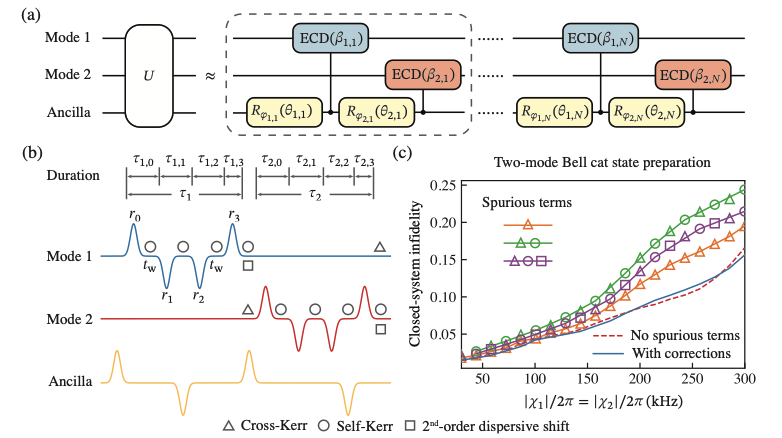

(Fig extracted from https://arxiv.org/pdf/2403.00275)

In [12]:
def Multimode_ECD_Compile(betas1_real,betas1_imag, betas2_real,betas2_imag, phis1, thetas1, phis2, thetas2,
                          Unitary, N_trunc, tol, Add_block = False, Disp = False, Mode='A'):

    '''Mode 'A'- cavity 1 
       Mode 'B' - cavity 2
       Mode 'AB' - cavities 1 and 2'''

    
       #   Transmon-Cavity1-Cavity2 
    def ECD1(beta_real, beta_imag, N_trunc):         
        return qt.tensor(qt.tensor(sigmap(), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)) + 
                qt.tensor(sigmam(), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2)), qt.qeye(N_trunc))

    def ECD2(beta_real, beta_imag, N_trunc):         
        return qt.tensor(qt.tensor(sigmap(), qt.qeye(N_trunc)), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)
                        ) + qt.tensor(qt.tensor(sigmam(), qt.qeye(N_trunc)), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2))
    
    # def Rot(phi, theta, N_trunc):
    #     return tensor(rz(phi) * rx(theta) * rz(-phi), qeye(N_trunc))
    
    def mRot(phi, theta, N_trunc):
        sx = qt.tensor(qt.tensor(qt.sigmax(), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        sy = qt.tensor(qt.tensor(qt.sigmay(), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        idty = qt.tensor(qt.tensor(qt.qeye(2), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        if theta == 0:
            return idty
        else:          
            return ((np.cos(theta/2.0))*idty - 1j * ((np.cos(phi) * sx) + (np.sin(phi) * sy)) * np.sin(theta/2.0))
       
        # return (-1j*(theta/2.0)*(np.cos(phi)*self.sx + np.sin(phi)*self.sy)).expm()        
        # return np.cos(theta / 2.0) * idty - 1j * (
        #     np.cos(phi) * sx + np.sin(phi) * sy
        # ) * np.sin(theta / 2.0)
    
    
    # One ECD Block
    def U_block_ECD(beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2,  N_trunc):
        return  ECD2(beta2_real, beta2_imag,  N_trunc)*mRot(phi2, theta2, N_trunc)*ECD1(beta1_real, beta1_imag, 
                                                                                   N_trunc) * mRot(phi1, theta1, N_trunc) 

    # Sequence of ECD blocks
    def U_circuit_ECD(betas1_real, betas1_imag, betas2_real, betas2_imag, phis1, thetas1, phis2, thetas2, N_trunc):
        
        U = qt.tensor(qt.tensor(qt.identity(2), qt.identity(N_trunc)), qt.qeye(N_trunc))
        for beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2 in zip(betas1_real[:-1], 
                betas1_imag[:-1], betas2_real[:-1], betas2_imag[:-1], phis1[:-1], thetas1[:-1], phis2[:-1], thetas2[:-1]): # [:-1] removes the last element in the list since they are  Disp. and rotation parameter
            U = U_block_ECD(beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2,  N_trunc) * U
            # U = U_block_ECD2(beta_real, beta_imag, phi, theta, N_trunc) * U
        
        if Add_block == False:
            return U
        else:
            return qt.tensor(qt.tensor(qt.qeye(2), qt.qeye(N_trunc)),displace(N_trunc, (betas2_real[-1]+ 1j*
                    betas2_imag[-1])/2)) * mRot(phis2[-1], thetas2[-1], N_trunc)*qt.tensor(qt.tensor(qt.qeye(2), displace(N_trunc, 
                        (betas1_real[-1]+ 1j*betas1_imag[-1])/2)),qt.qeye(N_trunc)) * mRot(phis1[-1], thetas1[-1], N_trunc) * U
    
    def Unitary_cost(Oper1, Oper2):
              # tracedist(Oper1, Oper1)
            # cost = 1- (abs((Oper1.dag()*Oper2).tr()/Oper1.shape[0]))**2
            U1 = Qobj(Oper1[0:N_trunc**2, 0:N_trunc**2]- Oper2[0:N_trunc**2, 0:N_trunc**2], dims = [N_trunc**2, N_trunc**2])
            # U2 = Qobj(Oper1[N_trunc:2*N_trunc, N_trunc:2*N_trunc]- Oper2[N_trunc:2*N_trunc, N_trunc:2*N_trunc],dims = [N_trunc, N_trunc])      
            cost = np.sqrt((U1.dag()*U1).tr())        
            return cost                      
    
    opt_process = {}  
    def my_callback(result):
        """
        A callback function to monitor optimization progress.
        """
        val = Error_func(result, Unitary, N_trunc)
        opt_process[val]= result
    
    # Trace norm
    
    def Error_func(params, Unitary, N_trunc):
        '''params=[betas1_real, betas1_imag, betas2_real, betas2_imag, phis1, thetas1, phis2, thetas2] - hence 8l sized list '''
        ''''  args = (Unitary)'''
        
        r = int(len(params)/8)
        U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], params[4*r:5*r], 
                          params[5*r:6*r], params[6*r:7*r], params[7*r:8*r],N_trunc)
        return Unitary_cost(Unitary, U)

    def grad(ini_params, Unitary, N_trunc):

        deriv = [] 
        epsilon = 5e-8
        for i in range(len(ini_params)):
            new_params_plus = [ele for ele in ini_params]
            new_params_minus = [ele for ele in ini_params] 
            new_params_plus[i] = ini_params[i] + epsilon
            new_params_minus[i] = ini_params[i] - epsilon
            partial_deriv_i = (Error_func(new_params_plus, Unitary, N_trunc) 
                               - Error_func(new_params_minus, Unitary, N_trunc))/(2*np.sinh(epsilon))
            deriv.append(partial_deriv_i)  
        return deriv

    def grad2(ini_params, Unitary, N_trunc):

        deriv = []
        h = 1e-8
        for i in range(len(ini_params)):            
            params_plus = [ele for ele in ini_params]
            params_plus[i] = params_plus[i] + h
            partial_deriv_i = (Error_func(params_plus, Unitary, N_trunc) 
                               - Error_func(ini_params, Unitary, N_trunc))/h
            deriv.append(partial_deriv_i)  
        return deriv


    if Mode == 'A':
        print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 1 '+ '*'*20 )
        return  ECD_Compile(betas1_real,betas1_imag , phis1, thetas1, Unitary, N_trunc, tol, Add_block = Add_block, Disp = Disp)

    elif Mode == 'B':
         print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 2 '+ '*'*20 )
         return ECD_Compile(betas2_real,betas2_imag , phis2, thetas2, Unitary, N_trunc, tol, Add_block = Add_block, Disp = Disp)

    
    else: 
        print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 1 and 2 '+ '*'*20 )
        if Unitary.isunitary == False:
            raise ValueError("Provided operator is non-unitary.")
        
    
        
        if Add_block == True:
            Extra_block = 1
        else:
            Extra_block = 0        
            
        phis_thetas = np.concatenate((phis1, np.concatenate((thetas1, np.concatenate((phis2, thetas2))))))
        betasreal_betas_imag = np.concatenate((betas1_real, np.concatenate((betas1_imag, np.concatenate((betas2_real, betas2_imag))))))
        ini_params = np.concatenate((betasreal_betas_imag, phis_thetas))
        k = int(len(ini_params)/8)

        print('\n' + '*'* 20 + f' Optimizing Parameters for {k - 1 + Extra_block} blocks ' 
              + f'including {Extra_block} Disp_Rot block ' + '*'* 20 )
        res = minimize(Error_func, ini_params, args = (Unitary, N_trunc), method = 'L-BFGS-B',  jac = grad,
                       tol = tol, callback = my_callback)    # jac = grad,, options={'gtol': 1e-8, 'maxiter':1000}

        opt_arg = res.x
        opt_val = res.fun   
        opt_hist = list(opt_process.keys())
    
        out_dict = {'Infidelity': opt_val, 'Betas1_real': opt_arg[0:k], 'Betas1_imag': opt_arg[k:2*k], 'Betas2_real': opt_arg[2*k:3*k],
                    'Betas2_imag': opt_arg[3*k:4*k], 'Phis1': opt_arg[4*k:5*k], 'Thetas1': opt_arg[5*k:6*k], 'Phis2': opt_arg[6*k:7*k],
                    'Thetas2': opt_arg[7*k:8*k]}    
        


        # Plot optimization History
        if Disp==True:
            plt.plot(range(len(opt_hist)), opt_hist, marker='o', linestyle='dashed')
            plt.axhline(y = opt_val, color = 'r', linestyle='--', label= f'y = {opt_val:.3g}')
            plt.title(f'Optimization History for {k} blocks with {Extra_block} Disp_Rot block.')
            plt.grid(which = 'both', axis='both')
            plt.ylabel('Infidelity')
            plt.xlabel('Number of shots')
            plt.yscale('log')
            plt.legend()
            plt.show()
            Mat = U_circuit_ECD(opt_arg[0:k],opt_arg[k:2*k], opt_arg[2*k:3*k], opt_arg[3*k:4*k],  opt_arg[4*k:5*k], opt_arg[5*k:6*k], opt_arg[6*k:7*k],
                          opt_arg[7*k:8*k],N_trunc)
            
        return out_dict, Mat

In [16]:
np.random.seed(10)
length = 6

# ECD sequence length (+1 since an extra block is used for unconditional displacement + Rotation)
N_blocks = length +1 

N_trunc = 2
betas1_real= np.random.randn(N_blocks) 
betas1_imag= np.random.randn(N_blocks)
betas2_real= np.random.randn(N_blocks) 
betas2_imag= np.random.randn(N_blocks)
phis1 =  np.random.randn(N_blocks)
thetas1 = 2*np.pi*np.random.randn(N_blocks)
phis2 =  np.random.randn(N_blocks)
thetas2 = 2*np.pi*np.random.randn(N_blocks)
tol = 1e-12 

In [17]:
# Define cavity unitary
# mat = np.zeros((N_trunc, N_trunc), dtype = np.complex64)
# mat[0,1]= 1
# mat[1,0] = 1
# for k in range(N_trunc):
#     mat[k,k] = np.exp(1j*np.pi*(k+1)/2)
# cav_unitary = Qobj(mat, dims = [N_trunc, N_trunc])

# generate random cavity unitary
mcav_unitary1 = Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])   
mcav_unitary2 = qt.qeye(N_trunc)       #Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])  

# generate random Transmon unitary
trans_unitary = Qobj(unitary_group.rvs(2), dims = [2, 2])      
# mUnitary = qt.tensor(qt.tensor(trans_unitary, mcav_unitary1), mcav_unitary2)
mUnitary = qt.tensor(qt.tensor(qt.qeye(2), mcav_unitary1), mcav_unitary2)


# generate random full unitary for 2-mode
twoMode_unitary = Qobj(unitary_group.rvs(N_trunc**2), dims = [[N_trunc, N_trunc], [N_trunc, N_trunc]]) 
mUnitary2 = qt.tensor(qt.qeye(2), twoMode_unitary)
   


******************** Compiling for Unitary in Cavity 1 and 2 ********************

******************** Optimizing Parameters for 6 blocks including 0 Disp_Rot block ********************


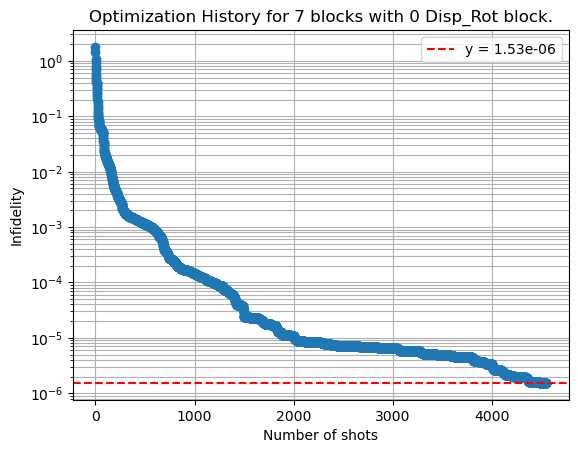

CPU times: user 1h 37min 5s, sys: 876 ms, total: 1h 37min 6s
Wall time: 1h 37min 6s


({'Infidelity': 1.534884863095222e-06,
  'Betas1_real': array([ 0.0488301 ,  0.80867379, -0.89720308, -0.49108853, -0.54508241,
         -1.01705455,  0.26551159]),
  'Betas1_imag': array([ 1.87758837,  1.62168319, -0.87178649,  0.54738381,  0.95002416,
         -1.13057876,  1.02827408]),
  'Betas2_real': array([ 0.61610311,  0.80558273, -0.68454095,  0.42894885,  1.84373604,
         -0.40609987, -1.97772828]),
  'Betas2_imag': array([-2.05096148,  0.31134229,  1.35210868, -0.3866069 ,  1.56847633,
          0.76742327,  1.39799638]),
  'Phis1': array([-1.20199267,  0.28178358,  0.27382683, -1.11131119,  2.10222987,
         -2.2704007 ,  1.30847308]),
  'Thetas1': array([ 2.68021337,  2.45425915, -1.41848597,  7.69749624, -5.11402249,
          4.53144043, -2.20459311]),
  'Phis2': array([ 0.1103019 , -1.40349905, -1.49607354, -0.24322807, -1.4025905 ,
          0.85429797,  0.56515267]),
  'Thetas2': array([-1.3271753 , -0.38548386,  1.68527566, -4.36287781,  4.62676139,
          

In [18]:
%time Multimode_ECD_Compile(betas1_real,betas1_imag, betas2_real,betas2_imag, phis1, thetas1, phis2, thetas2, mUnitary2, N_trunc, tol, Add_block = False, Disp=True, Mode='AB')

In [19]:
mUnitary2

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dia, isherm=False
Qobj data =
[[-0.08422774+0.08480357j  0.28998502-0.49896756j -0.01751261+0.19443708j
   0.78015784-0.07678133j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.58873247-0.02416569j  0.25631957-0.02458436j -0.62346028+0.11589575j
  -0.24922364-0.34965556j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.77482405-0.18817201j  0.25315445-0.15783482j -0.44069184+0.19527835j
  -0.16217787-0.1288231j   0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.02570193+0.04585345j -0.52474614-0.4860848j  -0.45737787-0.34382486j
  -0.00903989+0.39762817j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j         -0.08422774+0.08480357j  0.28998502-